In [ ]:
#| label: setup
#| results: "hold"

rm(list = ls()); gc()

required_packages <- c("dplyr", "readr", "haven", 
                      "ggplot2", "gridExtra", 
                      "fitdistrplus", "MASS", 
                      # Added by me
                      "janitor", "tidyr",
                      # Added posteriorly:
                      "readxl",
                      # MWE
                      "MicSim", 
                      "gtools", #dirichlet
                      #tables
                      "DT", "htmltools", 
                      #session info
                      "quarto",
                      # databases
                      "nanoparquet"
                )

# Install and load required packages
sapply(required_packages, function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) install.packages(pkg)
  library(pkg, character.only = TRUE)
})


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘gridExtra’

The following object is masked from ‘package:dplyr’:

    combine

Loading required package: MASS

Attaching package: ‘MASS’

The following object is masked from ‘package:dplyr’:

    select

Loading required package: survival

Attaching package: ‘janitor’

The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



There were 15 warnings (use warnings() to see them)


$dplyr
[1] "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$readr
[1] "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$haven
 [1] "haven"     "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$ggplot2
 [1] "ggplot2"   "haven"     "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$gridExtra
 [1] "gridExtra" "ggplot2"   "haven"     "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$fitdistrplus
 [1] "fitdistrplus" "survival"     "MASS"         "gridExtra"    "ggplot2"      "haven"        "readr"        "dplyr"        "stats"        "graphics"     "grDevices"    "utils"       
[13] "datasets"     "methods"      "base"        

$MASS
 [1] "fitdistrplus" "survival"     "MASS"         "gridExtra"    "ggplot2" 

### ENPG

#### ENPG's Daily use by age group and sexo + categorization


National Household Survey on Drug Use: 2008-2022, three-stage sampling, non-institutionalized population at national and regional levels. Alcohol consumption was estimated by weighting for each subpopulation of interest: sex and age groups. For alcohol use, AUDIT-C included three questions: frequency and quantity of alcohol, and use and frequency of HED. These were then triangulated with per capita alcohol consumption estimates. The per capita benchmark was external to the survey and served as a correction factor. Capping was set at 150 g.

- `volajohdia`: average daily grams or volume of alcohol.  
- `sexo`: Male/Female.  
- `edad_tramo`: age group, coded 1 to 4.  
- `hed`: whether the person engages in HED/binge drinking. 1 = HED, 0 = non-HED.  
- `exp`: survey weight, i.e., how much that person represents in the population.  
- `cvolaj`: consumption category, e.g., `ltabs` (lifetime abstainer) or `fd` (former drinker, if no alcohol in the last 30 days or more than 1 year).  
- `years_vec`: analyzed years, 2008 to 2022.  

Alcohol-consumption status was operationalized using the variable `cvolaj`, which classified respondents into lifetime abstainers (`ltabs`), former drinkers (`fd`), and current drinkers categorized by sex-specific average daily alcohol volume. Lifetime abstainers reported no alcohol use, while former drinkers had previous alcohol use but no recent/current drinking. Current drinkers were classified into four volume categories:  
- `cat1`: >=19.99 g/day in women, >=39.99 g/day in men.  
- `cat2`: 20>=39.99 g/day in women, 40>=59.99 g/day in men.  
- `cat3`: 40>=60 g/day in women, >=60-100 g/day in men.  
- `cat4`: >60 g/day in women, >100 g/day in men.  

These categories describe average daily pure alcohol consumption and were distinct from the heavy episodic drinking indicator, which captured binge-pattern drinking among current drinkers [@ruiztagle2025potentially]

Build lists of positive daily consumption, separated by year, age group, sex, and HED/NHED. Then, for `volajohdia > 0` (excluding abstainers), take the consumption list and fit a gamma distribution for each combination of year-age group-sex-HED/NHED, to smooth the distribution ([@gmel2011estimating]).

### Alcohol sensitivity binge

In [2]:
#| label: enpg-consolidate
#| results: "hold"

enpg_binge <- readRDS(file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "ENPG_BINGE.RDS"
))

data <- enpg_binge %>%
  dplyr::filter(edad >= 15) %>%
  dplyr::mutate(
    # db, episodios en el ultimo mes (si una persona tuvo mÃ¡s de un episodio en el dÃ­a, >30). Puede tener mÃ¡s de un episodio en el Ãºltimo mes.
    db = ifelse(db >= 88, NA, db),
    oh3 = as.numeric(haven::zap_labels(oh3)),          # 1) quita post-it -> nÃºmero (dÃ­as)
    oh3 = if_else(oh3 %in% c(88, 99), NA_real_, oh3),  # 2) "No sabe"/"No contesta" -> NA
    # 2026-07-03: Former drinker (fd): last drink NOT in the past 30 days.
    # Force days-since-last-drink to 0 for abstainers AND both former-drinker
    # recency codes, so ">1 year" ex-drinkers survive filter(oh3 <= 30) below.
    # If ">1 year" is dropped here, those rows fall out, and p_form collapses
    # All the confusion was due to Mojibake error. Did not recognized 
    # ENCODING: the survey stores this level as ">1 año" with "ñ" (U+00F1). Write it
    # as ">1 a\u00f1o" (ASCII escape).
    oh3 = dplyr::case_when(
      oh1 == "No" | oh2 == ">30" | oh2 == ">1 a\u00f1o" ~ 0,
      TRUE ~ oh3
    ),
    prom_tragos = dplyr::case_when(
      oh1 == "No" | oh2 == ">30" | oh2 == ">1 a\u00f1o" ~ 0,
      audit2 == "0-2" ~ 1,
      audit2 == "3-4" ~ 3.5,
      audit2 == "5-6" ~ 5.5,
      audit2 == "7-8" ~ 7.5,
      audit2 == "9 o mas" ~ 9
    ),
    diasalchab = oh3 - db, # WARNING:
    # Discount days to episodes and at what point this is compatible
    diasalchab = ifelse(diasalchab < 0, 0, diasalchab),
    volalchab = diasalchab * prom_tragos,
    # binge  move PAFs from distribution (not through the mean)
    volbinge = ifelse(sexo == "Hombre", db * 5, db * 4),
    voltotal = (volbinge + volalchab) * 12, # grams per drink (1)
    voltotMS = (volbinge + volalchab) * 15.7,# grams per drink (2)
    voltotdia = voltotal / 30,
    voltotMINSAL = voltotMS / 30,
    volCH = (voltotdia * 365), # mean = media_tragos day/gr
    volCHMS = (voltotMINSAL * 365)
  ) %>%
  dplyr::filter(oh3 <= 30)

# db= # 88 -> 1673 times     99 -> 1044       <- documented
# 888 ->  379           999 -> 172       <- same convention (3 digits)
# 500, 550, 1000, 2000, 5000, 6000, 10000  -> 1 each   <- error codes

# APC WHO
# I guess to calculate APCs vs WHO
total_volCH <- data %>% 
  group_by(year) %>% 
  filter(!is.na(volCH)) %>% 
  summarise(pop = sum(exp),
            pc_totalvolCH = sum(volCH*exp)/pop) 

total_volCHMS <- data %>% 
  group_by(year) %>% 
  filter(!is.na(volCHMS)) %>% 
  summarise(pop = sum(exp),
            pc_totalvolCHMS = sum(volCHMS*exp)/pop) 

# conversion factor sent by ACC
# g aparece numerator (individuo) y en el denominator
# (average used in the convertion), so they cancel. Drink
# volume dont go to calibrated volaj.
conversion <- function(x,vol){
  # 0.8 (registered fraction by Rehm, according to ACC) 
  vol_oms = x*0.8
  # to adjust alcohol density, from grams to litres
  oms=round((vol_oms*0.789)*1000,2)
  pull(round(oms/vol,2))
}

data <- data %>% 
  mutate(volaj = case_when(year == 2012 ~ volCH*conversion(8,total_volCH[1,3]),
                        year == 2014 ~ volCH*conversion(8.2,total_volCH[2,3]),
                        year == 2016 ~ volCH*conversion(7.1,total_volCH[3,3]),
                        year == 2018 ~ volCH*conversion(6.8,total_volCH[4,3]),
                        year == 2020 ~ volCH*conversion(7.9,total_volCH[5,3]),
                        year == 2022 ~ volCH*conversion(7.9,total_volCH[6,3]),
                        year == 2024 ~ volCH*conversion(7.9,total_volCH[7,3])),
         volajms = case_when(     
                        year == 2012 ~ volCHMS*conversion(8,total_volCHMS[1,3]),
                        year == 2014 ~ volCHMS*conversion(8.2,total_volCHMS[2,3]),
                        year == 2016 ~ volCHMS*conversion(7.1,total_volCHMS[3,3]),
                        year == 2018 ~ volCHMS*conversion(6.8,total_volCHMS[4,3]),
                        year == 2020 ~ volCHMS*conversion(7.9,total_volCHMS[5,3]),
                        year == 2022 ~ volCHMS*conversion(7.9,total_volCHMS[6,3]),
                     # 2026-06-09) changed to sensitivity values, from CH to CHMS
                        year == 2024 ~ volCHMS*conversion(7.9,total_volCHMS[7,3])), 
          # 2026-07-03= 
          # Former drinker (fd): last drink NOT in the past 30 days.
          # Includes BOTH recency codes -- oh2 == ">30" (last drink >30 days ago) and
          # oh2 == ">1 year" (last drink >1 year ago) -- matching JRT / Sherk-InterMAHP,
          # which apply the single former-drinker RR to every ex-drinker regardless of
          # time since quitting.
          # CAVEAT: for flat-RR cancers (colorectal, liver, stomach, pancreas) this term
          # is ~90-100% of the AAF and is sensitive to sick-quitter / reverse causation
          # (worst for liver, RR_fd=2.68). Report a sensitivity bracket at RR_fd = 1.
         volajohdia = volaj/365,
         volajohdiams = volajms/365,
         cvolaj = case_when(oh1 == "No" ~ "ltabs",
                            oh2 == ">30" | oh2 == ">1 a\u00f1o" ~ "fd",
           sexo == "Mujer" & volajohdia > 0 & volajohdia <= 19.99 ~ "cat1",
           sexo == "Mujer" & volajohdia >= 20 & volajohdia <= 39.99 ~ "cat2",
           sexo == "Mujer" & volajohdia >= 40 & volajohdia <= 100 ~ "cat3",
           sexo == "Mujer" & volajohdia > 100 ~ "cat4",
           sexo == "Hombre" & volajohdia > 0 & volajohdia <= 39.99 ~ "cat1",
           sexo == "Hombre" & volajohdia >= 40 & volajohdia <= 59.99 ~ "cat2",
           sexo == "Hombre" & volajohdia >= 60 & volajohdia <= 100 ~ "cat3",
           sexo == "Hombre" & volajohdia > 100 ~ "cat4",
           TRUE ~ NA),
         cvolajms = case_when(oh1 == "No" ~ "ltabs",
                        oh2 == ">30" | oh2 == ">1 a\u00f1o" ~ "fd",
                        sexo == "Mujer" & volajohdiams > 0 & volajohdiams <= 19.99 ~ "cat1",
                        sexo == "Mujer" & volajohdiams >= 20 & volajohdiams <= 39.99 ~ "cat2",
                        sexo == "Mujer" & volajohdiams >= 40 & volajohdiams <= 100 ~ "cat3",
                        sexo == "Mujer" & volajohdiams > 100 ~ "cat4",
                        sexo == "Hombre" & volajohdiams > 0 & volajohdiams <= 39.99 ~ "cat1",
                        sexo == "Hombre" & volajohdiams >= 40 & volajohdiams <= 59.99 ~ "cat2",
                        sexo == "Hombre" & volajohdiams >= 60 & volajohdiams <= 100 ~ "cat3",
                        sexo == "Hombre" & volajohdiams > 100 ~ "cat4",
                        TRUE ~ NA),
         hed = ifelse(db > 0,1,0),
         edad_tramo = case_when(between(edad, 15, 29)~1,
                                between(edad, 30,44)~2,
                                between(edad,45,59)~3,
                                between(edad,60,65)~4),
         aux = ifelse(oh1 == "No" & !is.na(oh2) ,1,0)) %>% 
  filter(aux == 0) %>% 
  dplyr::select(year, sexo, exp, edad_tramo, oh1, oh2, oh3, volajohdia, volajohdiams,cvolaj,cvolajms, hed,db, -aux)

out_dir <- file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "PIF addiction"
)
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}
write_rds(data, paste0(out_dir,"/data_binge_sensitivity.rds"))

In [3]:
#| label: enpg-consolidate-first-obs
#| results: "hold"
head(data) |>  knitr::kable("markdown")



| year|sexo   |      exp| edad_tramo|oh1 |oh2     | oh3| volajohdia| volajohdiams|cvolaj |cvolajms | hed| db|
|----:|:------|--------:|----------:|:---|:-------|---:|----------:|------------:|:------|:--------|---:|--:|
| 2012|Mujer  | 664.6565|          2|No  |NA      |   0|         NA|           NA|ltabs  |ltabs    |  NA| NA|
| 2012|Hombre | 982.9830|          1|Si  |>1 año  |   0|         NA|           NA|fd     |fd       |  NA| NA|
| 2012|Hombre | 982.9830|          3|No  |NA      |   0|         NA|           NA|ltabs  |ltabs    |  NA| NA|
| 2012|Mujer  | 332.3283|          2|Si  |30 dias |   4|       3.84|      3.83080|cat1   |cat1     |   0|  0|
| 2012|Mujer  | 664.6565|          1|No  |NA      |   0|         NA|           NA|ltabs  |ltabs    |  NA| NA|
| 2012|Hombre | 718.2290|          1|Si  |30 dias |   2|       8.16|      8.14045|cat1   |cat1     |   1|  1|

### Correct variability

- `__andres_control\build_enpg_design_waves_2012_2024_list.R`: This script builds the lightweight ENPG design cache `enpg_design_waves_2012_2024_list.RDS` in the Raw data folder. It excludes 2008 and 2010, keeps only survey-design and alcohol-related variables, harmonizes IDs, weights, region/commune, PSU when available, sex/age raw variables, and the alcohol items needed later for abstention, former drinking, HED, and consumption. The goal is to keep raw-data parsing separate from the design-analysis code.
- `__andres_control\revision_diseno_enpg_extension.R`: This advanced extension now reads the lightweight ENPG cache and joins it to `ENPG_BINGE.RDS`. Instead of applying one residual clustering factor estimated only from 2022/2024, it estimates the extra design effect separately by `year x tramo x sex x variable`, comparing the survey-design SE using `PSU + REGION` with the SE from Kish’s effective sample size. This is possible for 2012, 2014, 2016, 2018, 2022, and 2024 because those waves have a usable/validated PSU in the current files. For 2020, PSU is not validated/available, so the strict cell-specific factor is left non-estimable and an explicit fallback from the next wave is provided only for engine use.
- `__andres_control\enpg_design_table_cells_extension.csv`: This is the main output table for downstream use. It contains Kish `neff`, the strict cell-specific clustering factor, the engine-ready factor, corrected effective sample sizes, and a transparent source flag showing whether the factor is own-cell-specific or a fallback. It expands the design correction to the relevant simulation questions: `abs`, `form`, `hed`, and `consumption`, across sex and age tramos.
- `__andres_control\enpg_cluster_factors_by_year_variable_tramo.csv`: This is the audit-facing clustering-factor output. It keeps the estimated factors by year, variable, tramo, and sex, making clear where the correction is directly measured and where it is not.
- `__andres_control\enpg_design_join_audit.csv`: This checks that the lightweight design cache joins correctly back to the alcohol-analysis data. The verified join rate was 100% for all included waves, with validated PSU rows for all waves except 2020.

In [4]:
#| label: enpg-kish-PSU-corr
#| results: "hold"

source(file.path(gsub("","",getwd()),"revision_diseno_enpg_extension.R"))

Reading lightweight ENPG design cache.
Reading ENPG_BINGE.RDS and joining design variables.
Deriving alcohol variables and age/sex tramos.
Estimating cell-specific PSU + REGION factors where possible.

Join audit:
  year  rows matched_design unmatched_design match_rate validated_psu_rows
1 2012 17154          17154                0          1              17154
2 2014 20113          20113                0          1              20113
3 2016 19147          19147                0          1              19147
4 2018 19427          19427                0          1              19427
5 2020 16662          16662                0          1                  0
6 2022 17454          17454                0          1              17454
7 2024 18668          18668                0          1              18668

Factor source counts:

 cell_specific_psu_region no_validated_psu_for_year 
                      192                        32 

fallback_next_valid_year_same_cell                  own

In [5]:
#| label: enpg-kish-PSU-corr-for-audit
#| results: "hold"

design_table_cells_tbl <- paste0(
  '<div style="max-height:350px; overflow-y:auto; overflow-x:auto; border:1px solid #ddd;">',
  paste(knitr::kable(dplyr::select(design_table_cells, variable, variable_source_from_chunk, everything()) |> 
                    dplyr::rename("additional_factor" = "factor_additional") |> 
                    dplyr::arrange(variable, year, age_group, sex),
                    format = "html",
                    caption = "Cell (year-age group-sex)-specific clustering factors and PSU correction"),
        collapse = "\n"),
  '</div>'
)
htmltools::browsable(htmltools::HTML(design_table_cells_tbl))

variable,variable_source_from_chunk,year,age_group,age_group_label,sex,n,weighted_n,n_psu,n_strata,lonely_strata,estimate,neff_kish,se_design,se_kish,additional_factor,factor_source,fallback_factor_median_validated_cells,fallback_next_valid_year,fallback_factor_next_valid_year,factor_for_engine,factor_for_engine_source,neff_corr_strict,neff_corr_engine
abs,"cvolajms == ""ltabs""",2012,1,15-29,female,2579,1509714.2,1340,15,0,0.315857,646.80148,0.018043,0.018278,0.974437,cell_specific_psu_region,0.900628,NA,NA,0.974437,own_cell_specific,663.76934,663.76934
abs,"cvolajms == ""ltabs""",2012,1,15-29,male,2264,1703120.7,1268,15,0,0.283163,657.01291,0.018900,0.017577,1.156248,cell_specific_psu_region,0.900628,NA,NA,1.156248,own_cell_specific,568.22846,568.22846
abs,"cvolajms == ""ltabs""",2012,2,30-44,female,2768,1362594.4,1372,15,0,0.294461,772.48553,0.019733,0.016399,1.447857,cell_specific_psu_region,0.900628,NA,NA,1.447857,own_cell_specific,533.53710,533.53710
abs,"cvolajms == ""ltabs""",2012,2,30-44,male,2144,1122151.5,1202,15,0,0.173851,807.32643,0.015860,0.013338,1.413817,cell_specific_psu_region,0.900628,NA,NA,1.413817,own_cell_specific,571.02604,571.02604
abs,"cvolajms == ""ltabs""",2012,3,45-59,female,2603,1292814.4,1342,15,0,0.346949,679.62551,0.022850,0.018259,1.566168,cell_specific_psu_region,0.900628,NA,NA,1.566168,own_cell_specific,433.94163,433.94163
abs,"cvolajms == ""ltabs""",2012,3,45-59,male,1904,1224183.3,1177,15,0,0.204166,627.57359,0.018506,0.016091,1.322792,cell_specific_psu_region,0.900628,NA,NA,1.322792,own_cell_specific,474.43110,474.43110
abs,"cvolajms == ""ltabs""",2012,4,60-65,female,1081,489122.7,767,15,0,0.432207,373.36964,0.027341,0.025637,1.137313,cell_specific_psu_region,0.900628,NA,NA,1.137313,own_cell_specific,328.29111,328.29111
abs,"cvolajms == ""ltabs""",2012,4,60-65,male,635,339353.6,513,15,0,0.238735,210.72287,0.035682,0.029368,1.476240,cell_specific_psu_region,0.900628,NA,NA,1.476240,own_cell_specific,142.74293,142.74293
abs,"cvolajms == ""ltabs""",2014,1,15-29,female,2793,1341068.1,1465,15,0,0.233547,607.94550,0.015628,0.017159,0.829486,cell_specific_psu_region,0.900628,NA,NA,0.829486,own_cell_specific,732.91839,732.91839
abs,"cvolajms == ""ltabs""",2014,1,15-29,male,2418,1554117.4,1344,15,0,0.223149,668.02879,0.017349,0.016109,1.159904,cell_specific_psu_region,0.900628,NA,NA,1.159904,own_cell_specific,575.93452,575.93452


### Mortality

We read two official death records (one from 1990-2023 and anohter from 2025-2026, available from https://deis.minsal.cl/#datosabiertos), cleaned and standardized their columns  (`gender`, `age_group`. `region`, `comuna`), filtered individuals aged 15 and older from 2008 onward, and saved them as a single file ready for analysis. 

As an update, we included records updated one week later (2026-06-09), and we did not restrict to external causes (`DIAG2`).

In [6]:
  mort21 <- rio::import(file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "udpate jun 26",
  "DEFUNCIONES_DEIS_12_23_15plus.parquet"
  )) 

In [7]:
#| label: mortality-consolidate-and-update
#| results: "hold"
#| warnings: false

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# DEIS records were cleaned and filtered to include only records for 
# individuals over or equal 15 years old. 
# The data was then transformed to include relevant variables such as year
# so it can be uploaded to GitHub
# mort21|> 
#   janitor::clean_names() |> 
#   transmute(year = a_o, 
#     gender = sexo_nombre, 
#     age = edad_cant, 
#     age_group = case_when(between(age, 15, 29) ~ 1,
#         between(age, 30, 44) ~ 2,
#         between(age, 45, 59) ~ 3,
#         age >= 60 ~ 4),
#         # 2026-06-16= added diag1
#             comuna = iconv(comuna, "latin1", "UTF-8"), region = iconv(nombre_region, "latin1", "UTF-8"), diag1, diag2) |> 
#   dplyr::filter(year >= 2012, age >= 15) |> #, diag2 != ""
#   rio::export(file.path(
#     gsub("__andres_control","",getwd()),
#     "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
#     "udpate jun 26",
#     "DEFUNCIONES_DEIS_12_23_15plus.parquet"
#   ))
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:

path_deis_defunciones_90_23 <- 
file.path(
    gsub("__andres_control","",getwd()),
    "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
    "udpate jun 26",
    "DEFUNCIONES_DEIS_12_23_15plus.parquet"
  )

# Code made by JRT, updated to expand for all causes
# 2026-06-30= Restricted to <65 years old
# 2026-07-10= Restricted to <=65 years old
if(file.exists(path_deis_defunciones_90_23)) {
    mort21 <- rio::import(path_deis_defunciones_90_23) |> 
      janitor::clean_names() |> 
      # 2026-07-02= Restricted to 15-65 years old, just like SENDA ENPG
      dplyr::filter(age <=65) |> 
      dplyr::filter(year >= 2012, age >= 15)#, diag2 != ""
  } else {
    stop("Not found: ", path_deis_defunciones_90_23)
  }

# JRT took it from DEFUNCIONES_FUENTE_DEIS_2024_2026_02062026, I took from 09062026
# 2026-06-30= Restricted to <65 years old
# 2026-07-10= Restricted to <=65 years old
mort24 <- rio::import(file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "udpate jun 26",
  "DEFUNCIONES_FUENTE_DEIS_2024_2026_09062026.parquet"
  )) |> 
  janitor::clean_names() |> 
  dplyr::filter(edad_cant <=65) |> 
  transmute(year = a_o, 
    gender = sexo_nombre, 
    age = edad_cant, 
    age_group = case_when(between(age, 15, 29) ~ 1,
        between(age, 30, 44) ~ 2,
        between(age, 45, 59) ~ 3,
        age >= 60 ~ 4),
        # 2026-06-16= added diag1
            comuna = iconv(comuna, "latin1", "UTF-8"), region = iconv(nombre_region, "latin1", "UTF-8"), diag1, diag2) |> 
  dplyr::filter(year == 2024, age >= 15)#, diag2 != ""


mort <- rbind.data.frame(mort21, mort24)

Warning messages:
1: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
2: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
3: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
4: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
5: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
6: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
7: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
8: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
9: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
10: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  inp

### Group by diseases

As an update by 2026-06-16, we normalized ICD codes to no-dot 4-char format, and decided explicitly whether to close the parent unintentional category by adding W47-W48 and X30-X39. Also removed old "Y87.1" style if it appears anywhere; it should be Y871 (no dot). We followed the classification available in Table S6 of the Shield et al. 2025 paper (Shield2025AlcoholBurden).

The same procedure is applied to other specific diseases:
- `deg_nerv = 1` if DIAG1 is G312 (nervous degeneration)  
- `polineu = 1` if DIAG1 is G621 (polyneuropathy)  
- `cardiomio = 1` if DIAG1 is I426 (cardiomyopathy)  
- `pancreati_oh = 1` if DIAG1 is K860 (pancreatitis)  
- `gastrit = 1` if DIAG1 is K292 (gastritis)  

Then the second diagnosis (DIAG2) is reviewed for intoxications:
- `enven_acc = 1` if X450-X459 (accidental poisoning)  
- `enven_int = 1` if X650-X659 (intentional poisoning)  
- `enven_indet = 1` if Y150-Y159 (poisoning of undetermined intent) 

**Key changes**:
- Added helpers `icd_codes_s6()`, `icd_stems_s6()`, and `clean_icd10()` to generate 4-character codes (digits + "X") and strip dots / uppercase before matching.
- Kept X65 as fully alcohol-attributable (intentional self-poisoning by alcohol) in `aaf1` and excluded it from the self-harm partials.
- Injury code lists set to Shield Table S6 definitions: road injuries (V01-V04, V06, V09-V80, V87, V89, V99), poisonings (X40, X43, X46-X48, X49; X45 excluded as 100%), falls (W00-W19), fire/heat (X00-X19), drowning (W65-W74), mechanical forces (W20-W38, W40-W43, W45, W46, W49-W52, W75, W76), self-harm (X60-X84 minus X65, plus Y870), and interpersonal violence (X85-Y09, Y871; Y35 removed).
- **Other unintentional injuries**: Shield subrow 1590 (rest of V, W39, W44, W53-W64, W77-W99, X20-X29, X50-X59, Y40-Y86, Y88, Y89) **plus W47-W48 and X30-X39**, added to close the parent unintentional envelope (V01-X40, â€¦). NOTE: this **diverges from Shield's literal subrow**, which excludes W47-W48 and X30-X39; remove those two ranges for strict Shield reproduction.
- Non-injury (chronic) causes set to Shield Table S6: TB (A15-A19, B90), HIV/AIDS (B20-B24), lower respiratory infections (J09-J22, P23, U04), epilepsy (G40-G41), hypertensive disease (I10-I15), IHD (I20-I25), ischaemic stroke (G45-G46.8, I63, I65-I66, I67.2-I67.8, I69.3-I69.4), haemorrhagic stroke (I60-I62, I67.0-I67.1, I69.0-I69.2), cancers (lip/oral C00-C08, other pharyngeal C09-C10/C12-C14, oesophagus C15, colon/rectum C18-C21, liver C22, breast C50, cervix C53, larynx C32), diabetes (E10-E14 minus the `.2` renal codes), cirrhosis (K70, K74), and pancreatitis (K85-K86 minus K86.0).
- **Still not matching Shield (open items)**:
  - *Extra causes*: stomach cancer (C16) and pancreatic cancer (C25) are retained but are NOT alcohol-causal in Shield Table S6 â†’ discard them (or set RR = 1) to match Shield's structure.
- **Alcoholic cardiomyopathy (I42.6)**: Shield Table S6 (row 1150) treats it as part of a *partial* cause (I30-I33, I38, I40, I42), not at 100%. We kept I426 at 100% in `aaf1` (`cardiomio_codes`). This departs from Shield on two counts: (1) I42.6 is counted from regression(Manthey method, regression-based estimate), and (2) the rest of row 1150 (I30-I33, I38, I40, I42 excluding I426: myocarditis, endocarditis, other cardiomyopathies) is **not modeled at all** as no usable RR exists in the WHO 2024.

As of 2026-06-30, we also restricted mortality to <65 years old for comparability with SENDAs use estimates.

In [8]:
#| label: mort-trends-age-sex-chile11-mortalidad-etiqueta
#| results: "hold"

# X45 = 2.050 muertes por **intoxicacion accidental por alcohol 
# X65 = 7 muertes por "Envenenamiento autoinfligido intencionalmente por, y exposicion al alcohol"
# Y15 = 0 muertes por "Envenenamiento por, y exposicion al alcohol, de intencion no determinada"

#Helper: take ICD-10 in rangess
icd_codes <- function(letter, numbers, suffix = 0:9) {
  as.vector(outer(
    sprintf("%s%02d", letter, numbers),
    suffix,
    paste0
  ))
}
# 2026-06-16: Shield Table S6 helper; keeps old helper above intact, but adds "X" suffix support.
icd_codes_s6 <- function(letter, numbers, suffix = c(0:9, "X")) {
  as.vector(outer(
    sprintf("%s%02d", letter, numbers),
    suffix,
    paste0
  ))
}
# 2026-06-16: Helper for already formatted 3-character ICD stems, e.g. "X65", "Y87".
icd_stems_s6 <- function(stems, suffix = c(0:9, "X")) {
  as.vector(outer(stems, suffix, paste0))
}
# 2026-06-16: Normalize ICD-10 format before matching: remove dots/spaces, uppercase.
clean_icd10 <- function(x) {
  toupper(gsub("[^A-Za-z0-9]", "", x))
}
# 2026-06-16: Use cleaned no-dot ICD columns for all matches below.
def <- mort %>%
  dplyr::mutate(
    DIAG1_s6 = clean_icd10(diag1),
    DIAG2_s6 = clean_icd10(diag2)
  )
###########
# AFF = 1 #
###########
# polineu      # polineuropatia alcoholica
# cardiomio    # cardiomiopatia alcoholica
# pancreati_oh # pancreatitis inducida por alcohol
# gastrit      # gastritis alcoholica
# enven_acc    # intoxicacion accidental por alcohol
# enven_int    # intoxicacion intencional por alcohol
# enven_indet  # intoxicacion por alcohol de intenciÃ³n indeterminada

# 2026-06-16: F10 is alcohol use disorder; Shield Table S6 alcohol-use row includes F10.
des_men_codes <- icd_stems_s6("F10")
# 2026-06-16: Kept from previous fully attributable block.
deg_nerv_codes <- "G312"
# 2026-06-16: Kept from previous fully attributable block.
polineu_codes <- "G621"
# 2026-06-16: Shield Table S6 alcohol-use row also includes G72.1.
myopathy_oh_codes <- "G721"
# 2026-06-16: Shield Table S6 alcohol-use row also includes Q86.0.
fetal_oh_codes <- "Q860"
# 2026-06-16: Kept from previous fully attributable block.
cardiomio_codes <- "I426"
# 2026-06-16: Kept here as fully attributable; excluded from partial pancreatitis below.
pancreati_oh_codes <- "K860"
# 2026-06-16: Kept from previous fully attributable block.
gastrit_codes <- "K292"
# 2026-06-16: X45 remains fully attributable accidental alcohol poisoning.
x45_alcohol_accidental_poisoning_codes_aff1 <- icd_stems_s6("X45")
# 2026-06-16: X65 remains fully attributable intentional alcohol self-poisoning.
# 2026-06-16: The same X65 codes are removed from partial self-harm below.
x65_alcohol_self_poisoning_codes_aff1 <- icd_stems_s6("X65")
# 2026-06-16: Kept from previous fully attributable block.
y15_alcohol_undetermined_poisoning_codes_aff1 <- icd_stems_s6("Y15")
def <- def %>%
  dplyr::mutate(
    des_men = as.integer(DIAG1_s6 %in% des_men_codes), #Mental and behavioral disorders due to alcohol
    deg_nerv = dplyr::if_else(DIAG1_s6 %in% deg_nerv_codes, 1, 0),
    polineu = dplyr::if_else(DIAG1_s6 %in% polineu_codes, 1, 0),
    myopathy_oh = dplyr::if_else(DIAG1_s6 %in% myopathy_oh_codes, 1, 0), # 2026-06-16: Shield G72.1.
    fetal_oh = dplyr::if_else(DIAG1_s6 %in% fetal_oh_codes, 1, 0),       # 2026-06-16: Shield Q86.0.
    cardiomio = dplyr::if_else(DIAG1_s6 %in% cardiomio_codes, 1, 0),
    pancreati_oh = dplyr::if_else(DIAG1_s6 %in% pancreati_oh_codes, 1, 0),
    gastrit = dplyr::if_else(DIAG1_s6 %in% gastrit_codes, 1, 0),
    enven_acc = as.integer(DIAG2_s6 %in% x45_alcohol_accidental_poisoning_codes_aff1),
    enven_int = as.integer(DIAG2_s6 %in% x65_alcohol_self_poisoning_codes_aff1),
    enven_indet = as.integer(DIAG2_s6 %in% y15_alcohol_undetermined_poisoning_codes_aff1)
  )
# Avoid hard-coding by position in sum
# 2026-06-25: dont stop execution if  double-counting deaths by cause
def <- def %>%
  dplyr::mutate(
    aaf1 = as.integer(rowSums(
          dplyr::across(c(
            des_men, deg_nerv, polineu, myopathy_oh, fetal_oh,
            cardiomio, pancreati_oh, gastrit,
            enven_acc, enven_int, enven_indet
          )),
          na.rm = TRUE
        ) >= 1)
  )
################################
# PARTIALLY ATTRIBUTABLE TO OH #
################################
# NEUROPSYCHIATRIC
# Epilepsy
# 2026-05-27: Epilepsy codes are G40-41 instead of C40-41 (Malignant neoplasm of bone and articular cartilage of limbs)
# 2026-06-16: Shield Table S6 epilepsy row: G40-G41.
epilepsy_codes <- icd_codes_s6("G", 40:41)
# CARDIOVASCULAR
# Hypertensive disease
# 2026-06-16: Shield Table S6 hypertensive disease row: I10-I15.
hhd_codes <- icd_codes_s6("I", 10:15)
# Ischemic heart disease
# 2026-06-16: Shield Table S6 ischaemic heart disease row: I20-I25.
ihd_codes <- icd_codes_s6("I", 20:25)
# Hemorrhagic stroke
# 2026-06-16: Shield Table S6 haemorrhagic stroke row approximation:
# I60-I62, I67.0-I67.1, I69.0-I69.2.
ich_codes <- unique(c(
  icd_codes_s6("I", 60:62),
  c("I670", "I671"),
  c("I690", "I691", "I692")
))
# Ischemic stroke
# 2026-06-16: Shield Table S6 ischaemic stroke row approximation:
# G45-G46.8, I63, I65-I66, I67.2-I67.8, I69.3-I69.4.
is_codes <- unique(c(
  icd_codes_s6("G", 45),
  paste0("G46", 0:8),
  icd_codes_s6("I", 63),
  icd_codes_s6("I", 65:66),
  paste0("I67", 2:8),
  c("I693", "I694")
))
# CANCER
# Mouth, oropharynx and laryngeal cancer
# 2026-05-27: opcan_codes fixed. Split into locan (C000-C099) and opcan (C100-C149)
# locan = Lip and Oral Cavity (C00-C09); opcan = Other Pharyngeal (C10-C14)
# Both use same RR (oralcancer_male/female); kept separate to preserve mortality counts by anatomical site
# Reference label: "Oral Cavity and Pharynx Cancer" (matches AAF CALCULATION CANCER-ACC.R Table 2)
# 2026-06-16: Shield Table S6 split is stricter:
# lip/oral cavity = C00-C08; other pharyngeal = C09-C10 and C12-C14; C11 excluded.
locan_codes <- icd_codes_s6("C", 0:8)                         # C000-C089: lip and oral cavity.
opcan_codes <- unique(c(icd_codes_s6("C", 9:10), icd_codes_s6("C", 12:14))) # Other pharyngeal.
#opcan_codes <- paste0("C0", sprintf("%02d", 0:140))  # original bug: only captured C000-C099
# Esophageal cancer
# 2026-06-16: Shield Table S6 oesophagus cancer row: C15.
oescan_codes <- icd_codes_s6("C", 15)
# Colon and rectum cancer
# 2026-05-14= Had an error with the selection of causes:
# crcan_codes <- c(paste0("C18, 0:9"), "C19X", "C20X")
# 2026-06-16: Shield Table S6 colon and rectum cancer row: C18-C21.
crcan_codes <- icd_codes_s6("C", 18:21)
# Liver cancer
# 2026-06-16: Shield Table S6 liver cancer row: C22.
lican_codes <- icd_codes_s6("C", 22)
# Laryngeal cancer
# 2026-06-16: Shield Table S6 larynx cancer row: C32.
lxcan_codes <- icd_codes_s6("C", 32)
# Breast cancer
# 2026-06-16: Shield Table S6 breast cancer row: C50.
brcan_codes <- icd_codes_s6("C", 50)
# Cervix uteri cancer
# 2026-06-16: Shield Table S6 cervix uteri cancer row: C53.
# 2026-06-30: Not in Shield 2025, placeholder only in code
# cervcan_codes <- icd_codes_s6("C", 53)
# Other causes attributable to alcohol
# Diabetes
# 2026-06-16: Shield Table S6 diabetes mellitus row: E10-E14 minus renal .2 codes.
diabetes_codes <- setdiff(
  icd_codes_s6("E", 10:14),
  c("E102", "E112", "E122", "E132", "E142")
)
# 2026-06-16: Keep old object name for downstream code, but this is now all diabetes, not only DM2.
dm2_codes <- diabetes_codes
# Tuberculosis
# 2026-06-16: Shield Table S6 tuberculosis row: A15-A19, B90.
tb_codes <- unique(c(icd_codes_s6("A", 15:19), icd_codes_s6("B", 90)))
# HIV/Aids
# 2026-06-16: Shield Table S6 HIV/AIDS row: B20-B24.
hiv_codes <- icd_codes_s6("B", 20:24)
# Lower respiratory infection
# 2026-06-16: Shield Table S6 lower respiratory infections row: J09-J22, P23, U04.
lri_codes <- unique(c(icd_codes_s6("J", 9:22), icd_codes_s6("P", 23), icd_codes_s6("U", 4)))
# Liver cirrhosis
# 2026-06-16: Shield Table S6 cirrhosis row: K70 and K74.
lc_codes <- unique(c(icd_codes_s6("K", 70), icd_codes_s6("K", 74)))
#Acute pancreatitis
# 2026-06-16: Shield Table S6 pancreatitis row: K85-K86.
# 2026-06-16: Exclude K860 here because K860 remains fully attributable as pancreati_oh above.
panc_codes <- setdiff(icd_codes_s6("K", 85:86), pancreati_oh_codes)
# Stomach cancer
# 2026-06-16: Not in the pasted Shield Table S6 alcohol-causal rows; retained for downstream compatibility.
stom_codes <- icd_codes_s6("C", 16)         # C160-C169/C16X
# Pancreatic cancer (note: panc_codes above = K85 Acute Pancreatitis, different disease)
# 2026-06-16: Not in the pasted Shield Table S6 alcohol-causal rows; retained for downstream compatibility.
panccan_codes <- icd_codes_s6("C", 25)      # C250-C259/C25X
# MOTOR VEHICLE
# 2026-06-16: Old v_codes()/ri_codes used selected motor-vehicle 4th digits.
# 2026-06-16: Replaced by Shield Table S6 road injury row: V01-V04, V06, V09-V80, V87, V89, V99.
ri_codes <- unique(c(
  icd_stems_s6(sprintf("V0%d", 1:4)),       # Shield: V01-V04.
  icd_stems_s6("V06"),                      # Shield: V06.
  icd_stems_s6(sprintf("V%02d", 9:80)),     # Shield: V09-V80.
  icd_stems_s6("V87"),                      # Shield: V87.
  icd_stems_s6("V89"),                      # Shield: V89.
  icd_stems_s6("V99")                       # Shield: V99.
))
# 2026-06-16: Shield Table S6 poisonings row: X40, X43, X46-X48, X49.
# 2026-06-16: X45 is excluded because accidental alcohol poisoning remains AFF=1.
poisonings_codes <- unique(c(
  icd_stems_s6("X40"),
  icd_stems_s6("X43"),
  icd_stems_s6(sprintf("X%02d", 46:48)),
  icd_stems_s6("X49")
))
# 2026-06-16: Shield Table S6 falls row: W00-W19.
falls_codes <- icd_codes_s6("W", 0:19)
# 2026-06-16: Shield Table S6 fire, heat and hot substances row: X00-X19.
fire_heat_codes <- icd_codes_s6("X", 0:19)
# 2026-06-16: Shield Table S6 drowning row: W65-W74.
drowning_codes <- icd_codes_s6("W", 65:74)
# 2026-06-16: Shield Table S6 mechanical forces row:
# W20-W38, W40-W43, W45, W46, W49-W52, W75, W76.
mechanical_forces_codes <- unique(c(
  icd_codes_s6("W", 20:38),
  icd_codes_s6("W", 40:43),
  icd_stems_s6("W45"),
  icd_stems_s6("W46"),
  icd_codes_s6("W", 49:52),
  icd_stems_s6("W75"),
  icd_stems_s6("W76")
))
# 2026-06-16: All V codes are needed for Shield "Rest of V".
all_v_codes <- icd_codes_s6("V", 1:99)
# 2026-06-16: Shield Table S6 other unintentional injuries row:
# Rest of V, W39, W44, W53-W64, W77-W99, X20-X29, X50-X59, Y40-Y86, Y88, Y89.
# 2026-06-16: Added W47-W48 and X30-X39 to close the parent row:
# "Unintentional injuries: V01-X40, X43, X46-X59, Y40-Y86, Y88, Y89".
# 2026-06-16: Remove W47-W48 and X30-X39 only if you want strict subrow reproduction.
other_unintentional_codes <- unique(c(
  setdiff(all_v_codes, ri_codes),
  icd_stems_s6("W39"),
  icd_stems_s6("W44"),
  # icd_codes_s6("W", 47:48), # 2026-06-25: to replicate Shield's analysis
  icd_codes_s6("W", 53:64),
  icd_codes_s6("W", 77:99),
  icd_codes_s6("X", 20:29),
  # icd_codes_s6("X", 30:39),
  icd_codes_s6("X", 50:59),
  icd_codes_s6("Y", 40:86),
  icd_stems_s6("Y88"),
  icd_stems_s6("Y89")
))
# 2026-06-16: Shield Table S6 unintentional injuries parent category.
unint_inj_codes <- unique(c(
  ri_codes,
  poisonings_codes,
  falls_codes,
  fire_heat_codes,
  drowning_codes,
  mechanical_forces_codes,
  other_unintentional_codes
))
# 2026-06-16: Shield Table S6 self-harm row: X60-X84, Y870.
self_harm_codes_shield <- unique(c(
  icd_codes_s6("X", 60:84),
  "Y870"
))
# 2026-06-16: Exclude X65 from partial self-harm because X65 remains AFF=1 above.
self_harm_codes <- setdiff(
  self_harm_codes_shield,
  x65_alcohol_self_poisoning_codes_aff1
)
# 2026-06-16: Shield Table S6 interpersonal violence row: X85-Y09, Y871.
# 2026-06-16: Old Y35 and dotted "Y87.1" removed; Shield uses Y871 without dot.
interpersonal_violence_codes <- unique(c(
  icd_codes_s6("X", 85:99),
  icd_codes_s6("Y", 0:9),
  "Y871"
))
# 2026-06-16: Shield Table S6 intentional injuries parent category.
int_inj_codes <- unique(c(
  self_harm_codes,
  interpersonal_violence_codes
))
def <- def |>
  dplyr::mutate(
    epi = dplyr::if_else(DIAG1_s6 %in% epilepsy_codes, 1, 0),
    ich = dplyr::if_else(DIAG1_s6 %in% ich_codes, 1, 0),
    is = dplyr::if_else(DIAG1_s6 %in% is_codes, 1, 0),
    hhd = dplyr::if_else(DIAG1_s6 %in% hhd_codes, 1, 0),
    bcan = dplyr::if_else(DIAG1_s6 %in% brcan_codes, 1, 0),
    crcan = dplyr::if_else(DIAG1_s6 %in% crcan_codes, 1, 0),
    lxcan = dplyr::if_else(DIAG1_s6 %in% lxcan_codes, 1, 0),
    lican = dplyr::if_else(DIAG1_s6 %in% lican_codes, 1, 0),
    oescan = dplyr::if_else(DIAG1_s6 %in% oescan_codes, 1, 0),
    locan = dplyr::if_else(DIAG1_s6 %in% locan_codes, 1, 0),  # Lip and Oral Cavity C000-C089
    opcan = dplyr::if_else(DIAG1_s6 %in% opcan_codes, 1, 0),  # Other Pharyngeal C090-C109, C120-C149
    # Cervix cancer, dead code, is not in the `disease_filters` 
    # cervcan = dplyr::if_else(DIAG1_s6 %in% cervcan_codes, 1, 0),  # C53 no alcohol-causal, has a placeholder (Shield 2025); no RR; out of AAF
    stomcan = dplyr::if_else(DIAG1_s6 %in% stom_codes, 1, 0),
    panccan = dplyr::if_else(DIAG1_s6 %in% panccan_codes, 1, 0),  # C25; distinct from panc (K85-K86 = pancreatitis)
    dm2 = dplyr::if_else(DIAG1_s6 %in% dm2_codes, 1, 0),
    ihd = dplyr::if_else(DIAG1_s6 %in% ihd_codes, 1, 0),
    lri = dplyr::if_else(DIAG1_s6 %in% lri_codes, 1, 0),
    tb = dplyr::if_else(DIAG1_s6 %in% tb_codes, 1, 0),
    panc = dplyr::if_else(DIAG1_s6 %in% panc_codes, 1, 0),
    lc = dplyr::if_else(DIAG1_s6 %in% lc_codes, 1, 0),
    unint_inj = dplyr::if_else(DIAG2_s6 %in% unint_inj_codes | DIAG1_s6 %in% unint_inj_codes, 1, 0),
    ri_inj = dplyr::if_else(DIAG1_s6 %in% ri_codes | DIAG2_s6 %in% ri_codes, 1, 0),
    int_inj = dplyr::if_else(DIAG1_s6 %in% int_inj_codes | DIAG2_s6 %in% int_inj_codes, 1, 0),
    # 2026-06-30= Separate clearly what are road from no-road unintentional injuries, 
    # so road injury deaths dont enter as road (son) and the broader classification of unintentional
    # injuries
    unint_inj_noroad = dplyr::if_else(
      (DIAG1_s6 %in% unint_inj_codes | DIAG2_s6 %in% unint_inj_codes) &
      !(DIAG1_s6 %in% ri_codes | DIAG2_s6 %in% ri_codes), 1, 0),
    hiv = dplyr::if_else(DIAG1_s6 %in% hiv_codes, 1, 0)
  )
def <- def |>
  dplyr::mutate(
    age_group = dplyr::case_when(
      dplyr::between(age, 15, 29) ~ 1,
      dplyr::between(age, 30, 44) ~ 2,
      dplyr::between(age, 45, 59) ~ 3,
      age >= 60 ~ 4
    )
  ) %>%
  dplyr::filter(age >= 15)
dplyr::glimpse(def)

# 100% attributable causes (including I42.6, F10, X45...)
fully_attr <- def |>
  dplyr::filter(aaf1 >= 1)|> #, year %in% unique(aaf_long$year)) |>
  dplyr::group_by(year, age_group, gender) |>
  dplyr::summarise(n = dplyr::n(), .groups = "drop") |>
  dplyr::mutate(disease = "Fully attributable to alcohol",
                mort = n, ll_mort = n, up_mort = n) |>
  dplyr::select(year, age_group, gender, disease, mort, ll_mort, up_mort)

Rows: 401,769
Columns: 46
$ year             <int> 2016, 2012, 2019, 2015, 2012, 2012, 2013, 2012, 2015, 2015, 2019, 2016, 2019, 2015, 2019, 2016, 2015, 2016, 2019, 2019, 2019, 2019, 2019, 2012, 2017, 2016, 2017, 2018, 20…
$ gender           <chr> "Hombre", "Mujer", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "H…
$ age              <int> 20, 19, 18, 19, 35, 43, 59, 19, 18, 19, 27, 19, 16, 18, 21, 18, 28, 20, 19, 21, 17, 17, 24, 17, 24, 18, 21, 15, 16, 19, 20, 17, 21, 35, 28, 21, 19, 15, 20, 16, 24, 22, 24…
$ age_group        <dbl> 1, 1, 1, 1, 2, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ comuna           <chr> "Cañete", "Concepción", "Tiltil", "Maipú", "Arica", "Copiapó", "San Felipe", "Rancagua", "Lo Barnechea", "Rancagua", "Puerto Montt", "Padre Hurtado", "San Joaquí

## AAFs

This block estimates **alcohol-attributable fractions (AAFs)** for the **partially alcohol-attributable** causes — those whose AAF is derived by integrating an Adam/WHO relative-risk (RR) function over the sex- and age-specific consumption distribution. It does **not** assign the wholly (100%) alcohol-attributable causes, whose AAF is 1 by definition and is not obtained from an RR curve.
 
The code implements the final Adam/WHO relative-risk override used to estimate the partially-attributable AAFs. It loads and validates Adam's RR registry for six cause groups: cancer, hypertensive heart disease, general chronic conditions, ischaemic heart disease, ischaemic stroke, and injuries. For each scope, the code recalculates the AAF tables using the corresponding Adam/WHO relative-risk objects, the sex-specific alcohol consumption distributions, abstainer and former-drinker proportions, and the relevant age-group mappings.
 
**Reproducible input contract.** Earlier versions of this chunk silently depended on objects built in `revision_datos.ipynb` (`g_fem_list`, `g_male_list`, `g_fem_hed_list`, `g_male_hed_list`, `p_abs_list_*`, `p_form_list_*`, `p_hed_list_*`, `x_vals`, `x_vals_nhed`, `x_vals_hed`). Those
objects are not constructed here, so the override was not reproducible on its own (flagged by Codex, P1/P2; see the handoff). The chunk now opens with an explicit input contract: **Section 0** rebuilds the consumption/prevalence lists in-notebook from the survey microdata using the corrected builders (single source of truth: `functions.R`), and only does so when the objects are not already present, keeping any upstream `revision_datos.ipynb` outputs authoritative. **Section 1** runs a deep preflight audit of every input before a single AAF is computed.
 
**Corrected HED/binge semantics.** Current drinkers are partitioned **once** into non-heavy (NHED) and heavy episodic drinkers (HED) and both are integrated over a **single shared consumption grid**; `p_hed` is the weighted fraction of HED **among current drinkers** (survey-weighted), not over the whole population. `x_vals_nhed` and `x_vals_hed` are forced identical to `x_vals`. This matches the reference implementation in `functions.R` and avoids the double-integration defect described in the change-log (2026-05-27).
 
The resulting Adam-based AAF tables overwrite the previous pipeline disease-specific tables before the final `bind_rows()` step. This means that the final female and male AAF datasets use Adam's updated RR assumptions while preserving the original output object names expected by the rest of the pipeline.
 
The code also stores audit metadata and error records for each RR scope. These audit tables document which source objects, disease endpoints, sex groups, age mappings, and uncertainty assumptions were used. Former-drinker variance is recorded but not used in the current version, whereas injury HED/binge uncertainty is recorded and used for the current-drinker injury confidence intervals.
 
Finally, the code validates the overwritten AAF tables by checking for unexpected missing values, ensuring that all AAF estimates and confidence intervals remain within the `[-Inf, 1]` range, and confirming that lower, point, and upper estimates are correctly ordered. It also creates diagnostic tables identifying any upper confidence limits equal to 1, which may occur after  bounded AAF confidence intervals are clipped.

### WHO 2024 & Shield 2025 RR source to pipeline disease map

- Left side = Adam RR source object / endpoint.
- Right side = disease label kept in our AAF/final tables.
- Names do not always match.
- This is normal.

The punchline: `Oral_Cavity_and_Pharynx_Cancer` is an RR source name, not a final table row. The final table keeps the paper/mortality labels. `GENERAL_chronic_RR_2024_08_23.R` also includes two versions of esophagus (`Oesophagus_Cancer` and `Oesophagus_SCC_Cancer`) — the notebook uses only the first one, which corresponds both to the Paper and to the AAF CALCULATION CANCER-ACC script. Adam Sherk gave us the code to study this, so we labeled this section as "Adam RR".

| Adam RR source object | Sex / age note | Pipeline output disease |
|---|---|---|
| `oralcancer_male`, `oralcancer_female` | male/female — locan, ICD C000–C099 | `Oral Cavity and Pharynx Cancer` |
| `oralcancer_male`, `oralcancer_female` | male/female — opcan, ICD C100–C149 | `Other Pharyngeal Cancer` |
| `oesophaguscancer_male`, `oesophaguscancer_female` | male/female | `Oesophagus Cancer` |
| `colorectalcancer_male`, `colorectalcancer_female` | male/female | `Colon and rectum Cancer` |
| `Livercancer_male`, `Livercancer_female` | male/female | `Liver Cancer` |
| `Larynxcancer_male`, `Larynxcancer_female` | male/female | `Larynx Cancer` |
| `Breastcancer_female` | female only | `Breast Cancer` |
| `Stomachcancer_male`, `Stomachcancer_female` | male/female — ICD C160–C169 — **not in Shield S6** | `Stomach Cancer` |
| `Pancreascancer_male`, `Pancreascancer_female` | male/female — ICD C250–C259 — **not in Shield S6** | `Pancreatic Cancer` |
| `hypertension_male`, `hypertension_female` | male/female — ICD I10–I15 | `Hypertensive Heart Disease` |
| `IHDmaleMORT_1/2/3`, `IHDfemaleMORT_1/2/3` | age bands 15–34, 35–64, 65+ mapped to pipeline age groups | `Ischaemic Heart Disease` |
| `ischemicstrokemale_1/2/3`, `ischemicstrokefemale_1/2/3` | age bands 15–34, 35–64, 65+ mapped to pipeline age groups | `Ischaemic Stroke` |
| `epilepsymale`, `epilepsyfemale` | male/female | `Epilepsy` |
| `diabetesmale`, `diabetesfemale` | male/female — ICD E10–E14 (all diabetes; label `DM2` kept for back-compat) | `DM2`(*) |
| `tuberculosismale`, `tuberculosisfemale` | male/female | `Tuberculosis` |
| `HIVmale`, `HIVfemale` | male/female | `HIV` |
| `lowerrespmale`, `lowerrespfemale` | male/female | `Lower Respiratory Infection` |
| `livercirrhosismale`, `livercirrhosisfemale` | male/female | `Liver Cirrhosis` |
| `pancreatitismale`, `pancreatitisfemale` | male/female — ICD K85 (Acute Pancreatitis) | `Acute Pancreatitis` |
| `hemorrhagicstrokemale`, `hemorrhagicstrokefemale` | male/female | `Intracerebral Haemorrhage` |
| `injuries_MVA` | NHED + HED/binge; male/female shared RR | `Road Injuries` |
| `injuries_other_unit` | NHED + HED/binge; male/female shared RR | `Unintentional Injuries` † |
| `injuries_other_int` | NHED + HED/binge; male/female shared RR | `Intentional Injuries` |

ICD-10 classifies esophageal cancer by anatomical location (C15.0–C15.9), not by histologic subtype. Both squamous cell carcinoma (SCC) and adenocarcinoma map to the same C15x. Without pathology data linked to the mortality registry, it is impossible to isolate deaths due to SCC. Therefore, the combined RR **Oesophagus_Cancer** for all C15 is used, which is the standard practice in AAF estimates based on mortality records.

† `Unintentional Injuries` death counts use `unint_inj_noroad` (the Shield unintentional envelope **minus road**, i.e. excluding `ri_codes`), to match the Adam RR `injuries_other_unit` (other unintentional injuries). Road is handled separately by `injuries_MVA` → `Road Injuries`, so road deaths are not double-counted. The parent `unint_inj` (includes road) is kept for audit/counting only.

> Note on the partially- vs wholly-attributable split: every disease in the table above is **partially** attributable — its AAF is computed from an RR curve in this chunk. Causes that are **wholly** alcohol-attributable (AAF = 1 by definition) are not RR sources and do not appear here.
>
> Note on scope vs Shield S6: **Cervix uteri (C53)** is listed in Shield S6 (alcohol-attributable) but has **no row above** — the only RR in `GENERAL_chronic_RR_2024_08_23.R` is a placeholder (`DO NOT USE`) with no registry output, so it is excluded for lack of a usable RR (not because it is non-causal). Conversely, **Stomach (C16)** and **Pancreatic (C25)** cancer appear above but are **not** in Shield S6's alcohol-causal rows.
>
> (*) `DM2` covers E10–E14 ICD-codes, not only Type 2 diabetes mellitus.

#### Change log
 
2026-05-27= During validation of the Adam/WHO injury RR override, we found that the HED/binge component was not implemented as a mutually exclusive partition of current drinkers. The calculation currently includes NHED plus two HED terms. With the current defaults (*x_vals_nhed = x_vals_hed = 0.1-150 g/day*), the HED distribution is integrated twice and both terms are multiplied by the full HED prevalence. This violates the intended structure: current drinkers should be split into NHED and HED only once. We also found that `p_hed` is recalculated in the mortality-trends path over all individuals with non-missing HED status, including abstainers, instead of among current drinkers and using survey weights, even when the model expected the fraction of HED in actual drinkers.
 
2026-06-16= The functions needed to calculate PAF/AAFs are available in `__andres_control/aaf_unified.R`
 
2026-06-30= Reproducibility pass on the Adam/WHO RR override (addresses Codex P1/P2). The chunk no longer assumes `g_*_list` / `p_*_list` / `x_vals*` pre-exist: Section 0 rebuilds them in-notebook from `enpg_data` using the corrected builders (single source of truth: `functions.R`), only when they are missing, and Section 1 runs a deep preflight audit (structure, year-name alignment, `[0,1]` bounds, `p_abs + p_form <= 1`, strictly-increasing positive grids) that stops *before* any AAF is computed. Confirmed that `udpate jun 26/functions.R` is the current/corrected source: it integrates current drinkers on a SINGLE grid and partitions them once into NHED `(1 - p_hed)` and HED `p_hed`, with `p_hed` measured among current drinkers using survey weights — i.e. the fix for the 2026-05-27 defect, which still lives in `PIF-BINGE.R` (the `identical(x_vals_nhed, x_vals_hed)` branch, lines ~389/481). `x_vals_nhed` and `x_vals_hed` are now forced identical to `x_vals`. OPEN: confirm the assumed structure of the non-HED `g_fem_list` / `g_male_list` against `__andres_control/aaf_unified.R::compute_*_aaf_from_registry` (see the ASSUMED CONTRACT note in Section 0).

### AAF/PIF architecture

The AAF/PIF workflow separates three roles. The `GENERAL_*.R` files store the raw Adam/WHO relative-risk records: RR functions, beta vectors, covariance matrices, former-drinker RRs, and, for injuries, HED/binge-specific RR terms. The file `rr_registry_adam.R` does not compute exposure or mortality; it loads those RR records in a controlled way, maps each source object to the pipeline disease table names, validates the required fields, and produces auditable RR registries for cancer, HHD, general chronic causes, IHD, ischaemic stroke, and injuries.

The file `aaf_unified.R` is the generic calculation engine. It receives already-prepared inputs such as gamma consumption fits, abstainer/former-drinker/HED prevalences, RR functions, beta covariance matrices, former-drinker RRs, and the alcohol-consumption grid. It then computes AAF/PAF and PIF using one shared population-risk formulation. It does not decide which disease uses which RR; that mapping belongs to the registry.

In `expand_pif.ipynb`, the notebook acts as the orchestrator. It builds or checks the ENPG-derived exposure objects (`g_*_list`, `g_*_hed_list`, `p_abs_list_*`, `p_form_list_*`, `p_hed_list_*`, and `x_vals`), loads the Adam RR registries, computes the AAF tables by scope, and overwrites the pipeline disease-specific AAF tables before the final mortality `bind_rows()` step. `pif_scenarios.R` sits one layer above this: it changes inputs for counterfactual scenarios, such as reducing mean consumption or reducing HED prevalence, reruns the AAF machinery, and derives PIFs by comparing baseline and counterfactual AAFs.

#### AAF- rebuild lists and using corrected builders when missing + preflight audit 

Rebuilds `g_*_list`, `g_*_hed_list`, `p_abs/form/hed` lists and the grid in-notebook from `enpg_data`. After this, we validated every input (structure, integer  year-nams, gamma fits per grid, probability bounds, $P_{abs}+P_{form}\leq1$, positive grids, year-name alignement).

**2026-07-09**
* **Update:** Replaced MLE with a weighted Method of Moments (MoM) drop-in helper:
  $$\text{shape} = \frac{\mu^2}{\sigma^2} \quad \text{and} \quad \text{rate} = \frac{\mu}{\sigma^2}$$
* **Impact:** Both point estimates (first-order) and CI bands (second-order) now consistently respect the survey design.

In [9]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step0-pre
#| results: "hold"

# 2026-07-09 = HED/ abstainers considered expansion weights (exp), but consumption did not
# considered these expansion weights. Now we calcualte the weighted mean and variances; then, we
# calcualted the most representative Gamma parameters.
# =============================================================================
# fit_gamma_weighted() -- survey-weighted method-of-moments Gamma fit.
#
# WHY: fit_gamma_by_tramo()/fit_gamma_by_tramo_nohed() call fitdistrplus::fitdist(x,
# "gamma"), an UNWEIGHTED MLE fit over raw dplyr::pull(volajohdia) values -- it never
# looks at the survey weight column, so the gamma's shape/rate (and its implied mean
# and CV) do not reflect the population the weights represent. Passing
# neff_consumption/design_factor_consumption into compute_*_aaf_from_registry() does
# NOT fix this: those knobs only rescale n_pca_eff, the pseudo-sample size
# aaf_unified.R's .aaf_gamma_resample() uses to jitter shape/rate AROUND the fixed
# point estimate for the MonteCarlo CI (see aaf_unified.R lines 687-689 and 733-734).
# They never touch the point estimate itself (line 708, 714-728).
#
# This helper swaps the unweighted MLE point for a weighted method-of-moments point:
# weighted mean + weighted variance (same formula as wtd_var() in
# revision_diseno_enpg_extension.R) -> shape/rate solved the usual Gamma way. It
# returns $estimate = c(shape=, rate=), the exact same shape fitdistrplus::fitdist()
# returns and the only fields .aaf_gamma_pars() reads -- a drop-in replacement, no
# engine changes needed.
#
# NOTE: this weights the POINT estimate only (first-order design). It does NOT add a
# PSU/cluster correction to the point -- that stays the job of
# neff_consumption/design_factor_consumption on the *uncertainty* band.
fit_gamma_weighted <- function(x, w) {
  ok <- is.finite(x) & is.finite(w) & w > 0
  x <- x[ok]; w <- w[ok]
  if (length(x) < 2 || sum(w) <= 0) return(NULL)

  mu <- sum(w * x) / sum(w)
  var_w <- sum(w * (x - mu)^2) / sum(w)
  if (!is.finite(mu) || !is.finite(var_w) || var_w <= 0 || mu <= 0) return(NULL)

  list(estimate = c(shape = mu^2 / var_w, rate = mu / var_w))
}
# =============================================================================

# enpg_data = consolidated survey microdata built as `data` in the
# `enpg-consolidate` cell (volajohdia, sexo, edad_tramo, hed, year, cvolaj, exp).
if (!exists("enpg_data") && exists("data")) enpg_data <- data
# Survey years for the AAF panel (integer waves).
adam_years_vec <- if (exists("adam_years_vec")) adam_years_vec else
  if (exists("years_vec")) as.integer(years_vec) else
  if (exists("enpg_data")) sort(unique(as.integer(enpg_data$year))) else
    stop("Run the `enpg-consolidate` cell first (it builds `data`), or define `adam_years_vec`.")
# ---- Consumption / prevalence builders (extracted from functions.R) ----
# enpg_data columns used: volajohdia, sexo, edad_tramo, hed, year, exp, cvolaj.
# consumption vectors by year x age-tramo x HED/NHED
build_cd_hed_list <- function(df, sexo_value, years_vec) {
  out <- vector("list", length(years_vec)); names(out) <- as.character(years_vec)
  for (yy in years_vec) {
    out[[as.character(yy)]] <- list()
    for (tr in 1:4) for (hv in c(0L, 1L)) {
      key <- paste0("edad", tr, ifelse(hv == 0L, "_nhed", "_hed"))
      out[[as.character(yy)]][[key]] <- df %>%
        dplyr::filter(volajohdia > 0, sexo == sexo_value, edad_tramo == tr, hed == hv, year == yy) %>%
        dplyr::pull(volajohdia)
    }
  }
  out
}
# 2026-07-09= Weighted analogue of build_cd_list() (step0-1): same filter, no hed split,
# but keeps the survey weight column alongside volajohdia so
# fit_gamma_by_tramo_nohed_weighted() below can call fit_gamma_weighted(x, w).
build_cd_list_weighted <- function(df, sexo_value, years_vec, wcol = "exp") {
  out <- vector("list", length(years_vec)); names(out) <- as.character(years_vec)
  for (yy in years_vec) {
    out[[as.character(yy)]] <- lapply(1:4, function(tr) {
      sub <- df %>%
        dplyr::filter(volajohdia > 0, sexo == sexo_value, edad_tramo == tr, year == yy)
      list(x = sub$volajohdia, w = sub[[wcol]])
    })
  }
  out
}
# 2026-07-09= Same cell layout as build_cd_hed_list(), but keeps the weight column alongside
# volajohdia so fit_gamma_by_tramo_weighted() has (x, w) pairs instead of just x.
build_cd_hed_list_weighted <- function(df, sexo_value, years_vec, wcol = "exp") {
  out <- vector("list", length(years_vec)); names(out) <- as.character(years_vec)
  for (yy in years_vec) {
    out[[as.character(yy)]] <- list()
    for (tr in 1:4) for (hv in c(0L, 1L)) {
      key <- paste0("edad", tr, ifelse(hv == 0L, "_nhed", "_hed"))
      sub <- df %>%
        dplyr::filter(volajohdia > 0, sexo == sexo_value, edad_tramo == tr,
                      hed == hv, year == yy)
      # added w to the out list (no longer a vector)
      out[[as.character(yy)]][[key]] <- list(x = sub$volajohdia, w = sub[[wcol]])
    }
  }
  out
}
# gamma fit by year x tramo -> [[year]][[tramo]]$nhed / $hed
fit_gamma_by_tramo <- function(cd_hed_list) {
  out <- vector("list", length(cd_hed_list)); names(out) <- names(cd_hed_list)
  for (yy in names(cd_hed_list)) {
    out[[yy]] <- vector("list", 4)
    for (tr in 1:4) {
      data_nh <- cd_hed_list[[yy]][[paste0("edad", tr, "_nhed")]]
      data_h  <- cd_hed_list[[yy]][[paste0("edad", tr, "_hed")]]
      out[[yy]][[tr]] <- list(
        nhed = if (length(data_nh) > 1) fitdistrplus::fitdist(data_nh, "gamma") else NULL,
        hed  = if (length(data_h)  > 1) fitdistrplus::fitdist(data_h,  "gamma") else NULL
      )
    }
  }
  out
}
# 2026-07-09= Weighted version of the gamma
fit_gamma_by_tramo_weighted <- function(cd_hed_list) {
  out <- vector("list", length(cd_hed_list)); names(out) <- names(cd_hed_list)
  for (yy in names(cd_hed_list)) {
    out[[yy]] <- vector("list", 4)
    for (tr in 1:4) {
      d_nh <- cd_hed_list[[yy]][[paste0("edad", tr, "_nhed")]]
      d_h  <- cd_hed_list[[yy]][[paste0("edad", tr, "_hed")]]
      out[[yy]][[tr]] <- list(
        nhed = if (length(d_nh$x) > 1) fit_gamma_weighted(d_nh$x, d_nh$w) else NULL,
        hed  = if (length(d_h$x)  > 1) fit_gamma_weighted(d_h$x,  d_h$w)  else NULL
      )
    }
  }
  out
}
# 2026-07-09= Drop-in, weighted replacement for fit_gamma_by_tramo_nohed(). Uses the same
# fit_gamma_weighted() defined earlier -- no new fitting logic here.
fit_gamma_by_tramo_nohed_weighted <- function(cd_list) {
  out <- vector("list", length(cd_list)); names(out) <- names(cd_list)
  for (yy in names(cd_list)) {
    out[[yy]] <- lapply(1:4, function(tr) {
      d <- cd_list[[yy]][[tr]]
      if (length(d$x) > 1) fit_gamma_weighted(d$x, d$w) else NULL
    })
  }
  out
}
# weighted HED fraction among current drinkers -> [[tramo]][year-index]
build_s_hed_list_weighted <- function(df, sexo_value, years_vec) {
  tmp <- df %>%
    dplyr::filter(volajohdia > 0, sexo == sexo_value, year %in% years_vec,
                  edad_tramo %in% 1:4, hed %in% c(0L, 1L)) %>%
    dplyr::group_by(year, edad_tramo, hed) %>%
    dplyr::summarise(w = sum(exp, na.rm = TRUE), .groups = "drop") %>%
    tidyr::complete(year = years_vec, edad_tramo = 1:4, hed = 0:1, fill = list(w = 0)) %>%
    dplyr::group_by(year, edad_tramo) %>%
    dplyr::mutate(w_tot = sum(w), s_hed = ifelse(w_tot > 0, w[hed == 1] / w_tot, NA_real_)) %>%
    dplyr::ungroup() %>%
    dplyr::filter(hed == 1) %>%
    dplyr::arrange(edad_tramo, match(year, years_vec))
  split(tmp$s_hed, tmp$edad_tramo)
}
# weighted proportion of a cvolaj category (ltabs / fd) -> [[tramo]][year-index]
build_prop_list_weighted <- function(df, sexo_value, years_vec, cvolaj_value) {
  stopifnot(cvolaj_value %in% c("ltabs", "fd"))
  df_f <- df %>%
    dplyr::mutate(year = as.integer(year), edad_tramo = as.integer(edad_tramo), sexo = as.character(sexo)) %>%
    dplyr::filter(!is.na(cvolaj), !is.na(exp), sexo == sexo_value, year %in% years_vec, edad_tramo %in% 1:4)
  props <- df_f %>%
    dplyr::group_by(year, edad_tramo) %>%
    dplyr::summarise(wt_all = sum(exp, na.rm = TRUE),
                     wt_cat = sum(exp[cvolaj == cvolaj_value], na.rm = TRUE), .groups = "drop") %>%
    dplyr::mutate(prop = dplyr::if_else(wt_all > 0, wt_cat / wt_all, NA_real_))
  lapply(1:4, function(tr) as.numeric(sapply(years_vec, function(y) {
    row <- dplyr::filter(props, year == y, edad_tramo == tr)
    if (nrow(row) == 1) row$prop else NA_real_
  })))
}
build_abs_list_weighted  <- function(df, sexo_value, years_vec) build_prop_list_weighted(df, sexo_value, years_vec, "ltabs")
build_form_list_weighted <- function(df, sexo_value, years_vec) build_prop_list_weighted(df, sexo_value, years_vec, "fd")

# 2026-07-09= CONSISTENCY CHECK
# For a handful of (year, tramo, sexo) cells, compare pooled n vs nhed+hed n.
# If they differ, some current-drinker rows have NA `hed` and are being
# handled inconsistently between build_cd_list() and build_cd_hed_list().
chk <- enpg_data %>%
  dplyr::filter(volajohdia > 0, sexo == "Mujer") %>%
  dplyr::group_by(year, edad_tramo) %>%
  dplyr::summarise(
    n_pooled = dplyr::n(),
    n_split  = sum(hed %in% c(0L, 1L)),
    n_na_hed = sum(is.na(hed)),
    .groups = "drop"
  )
print(chk[chk$n_pooled != chk$n_split, ])
chk2 <- enpg_data %>%
  dplyr::filter(volajohdia > 0, sexo == "Hombre") %>%
  dplyr::group_by(year, edad_tramo) %>%
  dplyr::summarise(
    n_pooled = dplyr::n(),
    n_split  = sum(hed %in% c(0L, 1L)),
    n_na_hed = sum(is.na(hed)),
    .groups = "drop"
  )
print(chk2[chk2$n_pooled != chk2$n_split, ])

# A tibble: 0 × 5
# ℹ 5 variables: year <dbl>, edad_tramo <dbl>, n_pooled <int>, n_split <int>, n_na_hed <int>
# A tibble: 0 × 5
# ℹ 5 variables: year <dbl>, edad_tramo <dbl>, n_pooled <int>, n_split <int>, n_na_hed <int>


In [10]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step0-1
#| results: "hold"

# ============================================================
# Adam/WHO RR Full Override — all 6 scopes
# Overwrites pipeline AAF disease tables before final bind_rows()
#
# SCOPE: PARTIALLY alcohol-attributable causes only. AAF here is derived
# from an Adam/WHO RR function integrated over the consumption distribution.
# Wholly (100%) alcohol-attributable causes (AAF = 1 by definition) are NOT
# computed in this chunk.
#
# REPRODUCIBILITY (resolves Codex P1/P2): this chunk no longer assumes that
# g_*_list, p_*_list, x_vals* already exist in the session. Section 0 BUILDS
# them with the corrected builders (source of partial truth: functions.R) when
# they are missing, and Section 1 AUDITS them (preflight) before any AAF runs.
# ============================================================
 
# ------------------------------------------------------------
# SECTION 0 — INPUT CONTRACT + REPRODUCIBLE BUILD
# ------------------------------------------------------------
# Required inputs and their expected structure:
#
#   Non-HED scopes (cancer, hhd, general, ihd, is)
#     g_fem_list, g_male_list   : [[<year>]][[tramo 1:4]] -> fitdist gamma | NULL
#     p_abs_list_fem / _male     : list length 4 (tramo) -> numeric length n_years, in [0,1]
#     p_form_list_fem / _male    : idem
#     x_vals                     : strictly increasing positive numeric grid (g/day)
#
#   Injury scope (HED/binge-aware)
#     g_fem_hed_list, g_male_hed_list : [[<year>]][[tramo]]$nhed / $hed -> fitdist gamma | NULL
#     p_hed_list_fem / _male     : list length 4 -> numeric length n_years, in [0,1]
#                                  (= weighted fraction of HED AMONG CURRENT DRINKERS)
#     x_vals_nhed, x_vals_hed    : MUST be one shared grid, identical to x_vals
#
# ASSUMED CONTRACT (verify against __andres_control/aaf_unified.R):
#   g_fem_list / g_male_list are built here as [[year]][[tramo]] = a single
#   gamma fit of current drinkers (no HED split). If compute_*_aaf_from_registry
#   instead reads g_fem_list[[year]][[tramo]]$nhed or a per-year-only fit, adjust
#   fit_gamma_by_tramo_nohed() below — this is the single point to change.
#
# Where these come from: historically built in revision_datos.ipynb. To make
# the notebook self-contained, Section 0 (re)builds them from the survey
# microdata object `enpg_data` (filtered to volajohdia <= max(x_vals)) using the
# corrected builders sourced from functions.R. If the objects AND `enpg_data`
# are both missing, the build stops with an explicit message.
 
adam_required_inputs <- c(
  "g_fem_list", "g_male_list", "g_fem_hed_list", "g_male_hed_list",
  "p_abs_list_fem", "p_abs_list_male", "p_form_list_fem", "p_form_list_male",
  "p_hed_list_fem", "p_hed_list_male"
)
 # Survey years for the AAF panel (integer waves). Adjust to your survey.
adam_years_vec <- if (exists("adam_years_vec")) adam_years_vec else
  if (exists("years_vec")) as.integer(years_vec) else
    stop("Define `adam_years_vec` (integer survey years) before building AAF inputs.")

adam_have_all_inputs <- all(vapply(adam_required_inputs, exists, logical(1)))
if (!adam_have_all_inputs) { 
  .adam_builders <- c("build_cd_hed_list", "fit_gamma_by_tramo",
                      "build_s_hed_list_weighted", "build_abs_list_weighted",
                      "build_form_list_weighted")
  .adam_missing_b <- .adam_builders[!vapply(.adam_builders, exists, logical(1))]
  if (length(.adam_missing_b)) {
    stop("Cannot build AAF inputs; builder(s) not found: ",
         paste(.adam_missing_b, collapse = ", "),
         ". Source the corrected functions.R first.")
  }
  if (!exists("enpg_data")) {
    stop("AAF inputs are missing and `enpg_data` is not available to build them.\n",
         "Provide either (a) the prebuilt objects from revision_datos.ipynb: ",
         paste(adam_required_inputs, collapse = ", "), "\n",
         "or (b) the survey microdata `enpg_data` with columns: volajohdia, ",
         "sexo ('Mujer'/'Hombre'), edad_tramo (1:4), hed (0/1), year, ",
         "cvolaj ('ltabs'/'fd'), exp (survey weight).")
  } 
  # Non-HED analogues of the HED builders: current drinkers, no HED split.
  if (!exists("build_cd_list")) {
    build_cd_list <- function(df, sexo_value, years_vec) {
      out <- vector("list", length(years_vec)); names(out) <- as.character(years_vec)
      for (yy in years_vec) {
        out[[as.character(yy)]] <- lapply(1:4, function(tr) {
          df %>% dplyr::filter(volajohdia > 0, sexo == sexo_value,
                               edad_tramo == tr, year == yy) %>% dplyr::pull(volajohdia)
        })
      }
      out
    }
  }
  if (!exists("fit_gamma_by_tramo_nohed")) {
    fit_gamma_by_tramo_nohed <- function(cd_list) {
      out <- vector("list", length(cd_list)); names(out) <- names(cd_list)
      for (yy in names(cd_list)) {
        out[[yy]] <- lapply(1:4, function(tr) {
          d <- cd_list[[yy]][[tr]]
          if (length(d) > 1) fitdistrplus::fitdist(d, "gamma") else NULL
        })
      }
      out
    }
  }
  # Consumer shape
  # build_*_list_weighted returns tramo-keyed [[tr]][year]; .adam_pick_prop needs
  # year-keyed [[ "<year>" ]]$edad_tramo_<tr>. Convert.
  to_year_keyed_prop <- function(tramo_list, years_vec) {
    out <- lapply(as.character(years_vec), function(y) {
      i <- match(as.integer(y), as.integer(years_vec))
      setNames(lapply(1:4, function(tr) tramo_list[[tr]][[i]]),
               paste0("edad_tramo_", 1:4))
    })
    names(out) <- as.character(years_vec)
    out
  }
  message("Building AAF inputs from `enpg_data` via the corrected builders (functions.R).")
  .adam_inputs <- list(
    # 2026-07-09= replaced unweighted for survey-weighted lists without and splitting by HED (*_hed_list)
    # g_fem_list       = fit_gamma_by_tramo_nohed(build_cd_list(enpg_data, "Mujer",  adam_years_vec)),
    # g_male_list      = fit_gamma_by_tramo_nohed(build_cd_list(enpg_data, "Hombre", adam_years_vec)),
    g_fem_list       = fit_gamma_by_tramo_nohed_weighted(build_cd_list_weighted(enpg_data, "Mujer",  adam_years_vec)),
    g_male_list      = fit_gamma_by_tramo_nohed_weighted(build_cd_list_weighted(enpg_data, "Hombre", adam_years_vec)),
    # g_fem_hed_list   = fit_gamma_by_tramo(build_cd_hed_list(enpg_data, "Mujer",  adam_years_vec)),
    # g_male_hed_list  = fit_gamma_by_tramo(build_cd_hed_list(enpg_data, "Hombre", adam_years_vec)),
    g_fem_hed_list   = fit_gamma_by_tramo_weighted(build_cd_hed_list_weighted(enpg_data, "Mujer",  adam_years_vec)),
    g_male_hed_list  = fit_gamma_by_tramo_weighted(build_cd_hed_list_weighted(enpg_data, "Hombre", adam_years_vec)),
    p_abs_list_fem   = to_year_keyed_prop(build_abs_list_weighted(enpg_data,  "Mujer",  adam_years_vec), adam_years_vec),
    p_abs_list_male  = to_year_keyed_prop(build_abs_list_weighted(enpg_data,  "Hombre", adam_years_vec), adam_years_vec),
    p_form_list_fem  = to_year_keyed_prop(build_form_list_weighted(enpg_data, "Mujer",  adam_years_vec), adam_years_vec),
    p_form_list_male = to_year_keyed_prop(build_form_list_weighted(enpg_data, "Hombre", adam_years_vec), adam_years_vec),
    p_hed_list_fem   = build_s_hed_list_weighted(enpg_data, "Mujer",  adam_years_vec),   # tramo-keyed, OK
    p_hed_list_male  = build_s_hed_list_weighted(enpg_data, "Hombre", adam_years_vec)
  )
  list2env(.adam_inputs, envir = .GlobalEnv)
}
# Single shared consumption grid (g/day). ONE grid only: current drinkers are
# partitioned ONCE into NHED and HED and both are integrated over the SAME
# support. Two distinct grids was never intended; under the legacy path it
# double-integrated the HED density (change-log 2026-05-27).
if (!exists("x_vals")) x_vals <- seq(0.1, 150, length.out = 1500)
x_vals_nhed <- x_vals
x_vals_hed  <- x_vals
 
# ------------------------------------------------------------
# SECTION 1 — PREFLIGHT AUDIT of AAF inputs (deep)
# ------------------------------------------------------------
# Fails fast with a precise (object + property) message before any AAF is
# computed. On success prints a compact audit summary. This is the audit of
# the upstream lists requested during review.
 
adam_preflight_audit <- function(years_vec = adam_years_vec,
                                 required = adam_required_inputs) {
  errs <- character(0)
  add  <- function(...) errs[[length(errs) + 1L]] <<- paste0(...)
  n_years <- length(years_vec)
 
  is_gamma_fit <- function(f) {
    is.list(f) && !is.null(f$estimate) &&
      "shape" %in% names(f$estimate) &&
      any(c("rate", "scale") %in% names(f$estimate))
  }
  check_exists <- function(nm) {
    if (!exists(nm)) { add("MISSING object: ", nm); return(FALSE) }
    TRUE
  }
  # year-keyed gamma lists
  check_year_list <- function(nm, hed) {
    if (!check_exists(nm)) return(invisible())
    obj <- get(nm)
    if (!is.list(obj)) { add(nm, ": expected a list keyed by year"); return(invisible()) }
    yrs <- suppressWarnings(as.integer(names(obj)))
    if (is.null(names(obj)) || anyNA(yrs))
      add(nm, ": names() must be valid integer years; got '",
          paste(names(obj), collapse = ","), "'")
    if (length(obj) != n_years)
      add(nm, ": has ", length(obj), " year(s), expected ", n_years)
    for (y in names(obj)) {
      yr <- obj[[y]]
      if (!is.list(yr) || length(yr) != 4) {
        add(nm, "[['", y, "']]: expected list of 4 age tramos, got ", length(yr)); next
      }
      for (tr in 1:4) {
        cell <- yr[[tr]]
        if (hed) {
          if (!is.list(cell) || !all(c("nhed", "hed") %in% names(cell))) {
            add(nm, "[['", y, "']][[", tr, "]]: expected $nhed / $hed"); next
          }
          for (k in c("nhed", "hed"))
            if (!is.null(cell[[k]]) && !is_gamma_fit(cell[[k]]))
              add(nm, "[['", y, "']][[", tr, "]]$", k,
                  ": not a gamma fit (need $estimate shape + rate/scale)")
        } else {
          if (!is.null(cell) && !is_gamma_fit(cell))
            add(nm, "[['", y, "']][[", tr, "]]: not a gamma fit (need $estimate shape + rate/scale)")
        }
      }
    }
  }
  # proportion lists (tramo -> vector over years, in [0,1])
  # proportion lists — validated against the shape the AAF consumers read.
  #   abs/form  -> year-keyed  : [[ "<year>" ]][[ "edad_tramo_<g>" ]]  (.adam_pick_prop)
  #   hed       -> tramo-keyed : [[ <g> ]][ year-index ]              (.adam_prop_from_group_list)
  check_prop_list <- function(nm, layout = c("year", "tramo")) {
    if (!check_exists(nm)) return(invisible())
    layout <- match.arg(layout)
    obj <- get(nm)
    in01 <- function(v) { ok <- v[!is.na(v)]; !length(ok) || (all(ok >= 0) & all(ok <= 1)) }
    if (layout == "year") {
      yrs <- suppressWarnings(as.integer(names(obj)))
      if (!is.list(obj) || is.null(names(obj)) || anyNA(yrs)) {
        add(nm, ": expected a list keyed by integer year; got names '",
            paste(names(obj), collapse = ","), "'"); return(invisible())
      }
      if (length(obj) != n_years)
        add(nm, ": has ", length(obj), " year(s), expected ", n_years)
      for (y in names(obj)) for (tr in 1:4) {
        key <- paste0("edad_tramo_", tr)
        v <- obj[[y]][[key]]
        if (is.null(v)) { add(nm, "[['", y, "']]$", key, ": missing"); next }
        if (!in01(as.numeric(v)))
          add(nm, "[['", y, "']]$", key, ": value outside [0,1]")
      }
    } else {  # tramo
      if (!is.list(obj) || length(obj) != 4) {
        add(nm, ": expected list of 4 age tramos, got length ", length(obj)); return(invisible())
      }
      for (tr in 1:4) {
        v <- as.numeric(obj[[tr]])
        if (length(v) != n_years)
          add(nm, "[[", tr, "]]: expected length ", n_years, ", got ", length(v))
        if (!in01(v)) add(nm, "[[", tr, "]]: value(s) outside [0,1]")
      }
    }
  }
  # grids
  check_grid <- function(nm) {
    if (!check_exists(nm)) return(invisible())
    g <- get(nm)
    if (!is.numeric(g) || length(g) < 3) { add(nm, ": expected numeric grid length >= 3"); return(invisible()) }
    if (any(!is.finite(g))) add(nm, ": contains non-finite values")
    if (is.unsorted(g, strictly = TRUE)) add(nm, ": must be strictly increasing")
    if (any(g <= 0)) add(nm, ": gamma support requires strictly positive x")
  }
  lapply(c("g_fem_list", "g_male_list"), check_year_list, hed = FALSE)
  lapply(c("g_fem_hed_list", "g_male_hed_list"), check_year_list, hed = TRUE)
  lapply(c("p_abs_list_fem", "p_abs_list_male", "p_form_list_fem", "p_form_list_male"),
         check_prop_list, layout = "year")
  lapply(c("p_hed_list_fem", "p_hed_list_male"),
         check_prop_list, layout = "tramo")
  lapply(c("x_vals", "x_vals_nhed", "x_vals_hed"), check_grid)

  # cross-object consistency: one shared grid
  if (exists("x_vals_nhed") && exists("x_vals_hed") && !identical(x_vals_nhed, x_vals_hed))
    add("x_vals_nhed / x_vals_hed: must be IDENTICAL (single shared grid). ",
        "Distinct grids double-integrate the HED density (see 2026-05-27).")
  if (exists("x_vals") && exists("x_vals_nhed") && !identical(x_vals, x_vals_nhed))
    add("x_vals vs x_vals_nhed: injury and chronic scopes must share one grid.")
  # current-drinker mass must be non-negative: 1 - (p_abs + p_form) >= 0
  # Extended to work not only for tramo shape but for year-keyed version
  chk_cd_mass <- function(abs_nm, frm_nm, sx) {
    if (!exists(abs_nm) || !exists(frm_nm)) return(invisible())
    a <- get(abs_nm); f <- get(frm_nm)
    for (y in intersect(names(a), names(f))) for (tr in 1:4) {
      key <- paste0("edad_tramo_", tr)
      s <- as.numeric(a[[y]][[key]]) + as.numeric(f[[y]][[key]])
      if (length(s) && !is.na(s) && s > 1 + 1e-8)
        add(sx, " ", y, " tramo ", tr, ": p_abs + p_form = ", round(s, 3),
            " > 1 -> negative current-drinker mass")
    }
  }
  chk_cd_mass("p_abs_list_fem", "p_form_list_fem", "Female")
  chk_cd_mass("p_abs_list_male", "p_form_list_male", "Male")
  # year-name alignment across all year-keyed lists
  ynames <- lapply(c("g_fem_list", "g_male_list", "g_fem_hed_list", "g_male_hed_list"),
                   function(nm) if (exists(nm)) names(get(nm)) else NULL)
  ynames <- ynames[!vapply(ynames, is.null, logical(1))]
  if (length(ynames) > 1 && !all(vapply(ynames[-1], identical, logical(1), ynames[[1]])))
    add("Year names differ across g_* / g_*_hed lists; they must align.")
 
  if (length(errs)) {
    stop("AAF preflight audit FAILED (", length(errs), " issue(s)):\n  - ",
         paste(errs, collapse = "\n  - "), call. = FALSE)
  }
  # success summary (the audit table)
  summarise_obj <- function(nm) {
    obj <- get(nm)
    if (is.numeric(obj)) {
      data.frame(object = nm, kind = "grid", n_years = NA_integer_,
                 detail = paste0("len ", length(obj), " [",
                                 round(min(obj), 2), ", ", round(max(obj), 2), "]"),
                 stringsAsFactors = FALSE)
    } else if (grepl("hed_list$", nm) || nm %in% c("g_fem_list", "g_male_list")) {
      data.frame(object = nm, kind = "gamma-list", n_years = length(obj),
                 detail = paste0(min(names(obj)), "-", max(names(obj)), ", 4 tramos"),
                 stringsAsFactors = FALSE)
    } else {
      n_na <- sum(vapply(obj, function(v) sum(is.na(v)), integer(1)))
      data.frame(object = nm, kind = "prop-list",
                 n_years = length(obj[[1]]),
                 detail = paste0(n_na, " NA cell(s)"), stringsAsFactors = FALSE)
    }
  }
  audit <- do.call(rbind, lapply(c(required, "x_vals"), summarise_obj))
  message("AAF preflight audit PASSED for ", n_years, " survey years.")
  print(audit, row.names = FALSE)
  invisible(audit)
}
adam_aaf_input_audit <- adam_preflight_audit()

Building AAF inputs from `enpg_data` via the corrected builders (functions.R).
AAF preflight audit PASSED for 7 survey years.
           object       kind n_years              detail
       g_fem_list gamma-list       7 2012-2024, 4 tramos
      g_male_list gamma-list       7 2012-2024, 4 tramos
   g_fem_hed_list gamma-list       7 2012-2024, 4 tramos
  g_male_hed_list gamma-list       7 2012-2024, 4 tramos
   p_abs_list_fem  prop-list       4        0 NA cell(s)
  p_abs_list_male  prop-list       4        0 NA cell(s)
  p_form_list_fem  prop-list       4        0 NA cell(s)
 p_form_list_male  prop-list       4        0 NA cell(s)
   p_hed_list_fem  prop-list       7        0 NA cell(s)
  p_hed_list_male  prop-list       7        0 NA cell(s)
           x_vals       grid      NA len 1500 [0.1, 150]


In [11]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step0-1-save
#| results: "hold"

.t0 <- Sys.time()

# ---- Source engine + loader (FIRST) ----
adam_control_dir <- file.path(gsub("__andres_control", "", getwd()), "__andres_control")
source(file.path(adam_control_dir, "rr_registry_adam.R"))   # data/loader
source(file.path(adam_control_dir, "aaf_unified.R"))        # motor + compute_*

# Save all AAF engine inputs in one auditable RDS bundle.
# This object stores the exposure/prevalence inputs used by aaf_unified.R,
# plus metadata that explains what each object means and where it came from.
aaf_input_bundle <- list(
  metadata = list(
    created_at = format(Sys.time(), "%Y-%m-%d %H:%M:%S %Z"),
    engine_file = file.path(adam_control_dir, "aaf_unified.R"),
    registry_file = file.path(adam_control_dir, "rr_registry_adam.R"),
    survey_years = adam_years_vec,
    source_microdata = file.path(
      gsub("__andres_control", "", getwd()),
      "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
      "ENPG_BINGE.RDS"
    ),
    derived_exposure_cache = file.path(
      gsub("__andres_control", "", getwd()),
      "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
      "PIF addiction",
      "data_binge_sensitivity.rds"
    )
  ),
  object_map = tibble::tibble(
    object = c(
      "g_fem_list", "g_male_list",
      "g_fem_hed_list", "g_male_hed_list",
      "p_abs_list_fem", "p_abs_list_male",
      "p_form_list_fem", "p_form_list_male",
      "p_hed_list_fem", "p_hed_list_male",
      "x_vals", "x_vals_nhed", "x_vals_hed",
      "aaf_uncertainty", "aaf_mc",
      "adam_rr_registry_*_metadata"
    ),
    role = c(
      "Female current-drinker gamma fits, no HED split",
      "Male current-drinker gamma fits, no HED split",
      "Female current-drinker gamma fits split into NHED/HED",
      "Male current-drinker gamma fits split into NHED/HED",
      "Female abstainer prevalence by year and age group",
      "Male abstainer prevalence by year and age group",
      "Female former-drinker prevalence by year and age group",
      "Male former-drinker prevalence by year and age group",
      "Female HED prevalence among current drinkers",
      "Male HED prevalence among current drinkers",
      "Main alcohol-consumption integration grid, g/day",
      "NHED alcohol-consumption integration grid, g/day",
      "HED alcohol-consumption integration grid, g/day",
      "Uncertainty settings passed to the AAF engine",
      "Monte Carlo settings passed to the AAF engine",
      "RR source-object to pipeline-disease mapping"
    ),
    source = c(
      rep("Derived from enpg_data", 10),
      rep("Defined in AAF input-preflight chunk", 3),
      "Defined before compute_*_aaf_from_registry calls",
      "Defined before compute_*_aaf_from_registry calls",
      "Derived from load_adam_rr_registry()"
    )
  ),
  exposure_inputs = list(
    g_fem_list = g_fem_list,
    g_male_list = g_male_list,
    g_fem_hed_list = g_fem_hed_list,
    g_male_hed_list = g_male_hed_list,
    p_abs_list_fem = p_abs_list_fem,
    p_abs_list_male = p_abs_list_male,
    p_form_list_fem = p_form_list_fem,
    p_form_list_male = p_form_list_male,
    p_hed_list_fem = p_hed_list_fem,
    p_hed_list_male = p_hed_list_male,
    x_vals = x_vals,
    x_vals_nhed = if (exists("x_vals_nhed")) x_vals_nhed else x_vals,
    x_vals_hed = if (exists("x_vals_hed")) x_vals_hed else x_vals
  ),
  engine_settings = list(
    aaf_mc = if (exists("aaf_mc")) aaf_mc else NULL,
    aaf_uncertainty = if (exists("aaf_uncertainty")) aaf_uncertainty else NULL,
    kish = if (exists("kish")) kish else NULL
  )
)
out_path <- file.path(
  adam_control_dir,
  paste0("aaf_engine_inputs_bundle_", format(Sys.Date(), "%Y%m%d"), ".rds")
)
base::saveRDS(aaf_input_bundle, out_path, compress = "xz")

.elapsed_min <- as.numeric(difftime(Sys.time(), .t0, units = "mins"))
message(sprintf("Saved AAF engine input bundle: %s", out_path))
message(sprintf("Time taken: %.2f minutes", .elapsed_min))

Saved AAF engine input bundle: c:/Users/nDP/Desktop/ACC1240138_private//__andres_control/aaf_engine_inputs_bundle_20260710.rds
Time taken: 0.00 minutes


#### AAF - Loader

In [12]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-load

# ---- Load all 6 scope registries ----
# `scope` chooses which RR; `control_dir` is the file which is located
#- **control_dir** = the folder `(__andres_control)`.
#- **source_path** = path to a specific `.R` file that replaces the one scope 
# would normally choose (to load RR from a non‑standard file).

adam_rr_registry_cancer   <- load_adam_rr_registry(scope = "cancer",   control_dir = adam_control_dir)#source_path=
validate_adam_rr_registry(adam_rr_registry_cancer)
adam_rr_registry_cancer_metadata <- adam_rr_registry_metadata(adam_rr_registry_cancer)

adam_rr_registry_hhd      <- load_adam_rr_registry(scope = "hhd",      control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_hhd)
adam_rr_registry_hhd_metadata <- adam_rr_registry_metadata(adam_rr_registry_hhd)

adam_rr_registry_general  <- load_adam_rr_registry(scope = "general",  control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_general)
adam_rr_registry_general_metadata <- adam_rr_registry_metadata(adam_rr_registry_general)

adam_rr_registry_ihd      <- load_adam_rr_registry(scope = "ihd",      control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_ihd)
adam_rr_registry_ihd_metadata <- adam_rr_registry_metadata(adam_rr_registry_ihd)

adam_rr_registry_is       <- load_adam_rr_registry(scope = "is",       control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_is)
adam_rr_registry_is_metadata <- adam_rr_registry_metadata(adam_rr_registry_is)

adam_rr_registry_injuries <- load_adam_rr_registry(scope = "injuries", control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_injuries)
adam_rr_registry_injuries_metadata <- adam_rr_registry_metadata(adam_rr_registry_injuries)


[load_adam_rr_registry] scope = 'cancer'
  control_dir resolved to: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control
  sourcing RR definitions from: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/GENERAL_chronic_RR_2024_08_23.R
  loading 15 record(s):
    [ok] oralcancer_male            male    Oral Cavity and Pharynx Cancer   betas=4
    [ok] oralcancer_female          female  Oral Cavity and Pharynx Cancer   betas=4
    [ok] oesophaguscancer_male      male    Oesophagus Cancer                betas=4
    [ok] oesophaguscancer_female    female  Oesophagus Cancer                betas=4
    [ok] colorectalcancer_male      male    Colon and rectum Cancer          betas=4
    [ok] colorectalcancer_female    female  Colon and rectum Cancer          betas=4
    [ok] Livercancer_male           male    Liver Cancer                     betas=4
    [ok] Livercancer_female         female  Liver Cancer                     betas=4
    [ok] Larynxcancer_male          male    Larynx

#### AAF- rebuild lists and using corrected builders only when missing

This cell computes ~1,260 year × age × cause × sex cells. `run_aaf_cells_parallel()` (in `aaf_unified.R`) now deduplicates RR closures before shipping them to parallel workers — each closure carries its whole sourced registry environment, and a naive per-cell driver was serializing that ~1,260 times, hanging for hours. The fix exports the ~30–45 distinct closures once and gives each task a tiny integer index instead. Execution plumbing only — no RR source, age mapping, or table structure above changes, and results are bit-identical to running serially.

In [ ]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step2
#| results: "hold"
start_time <- Sys.time()
# ============================================================================
# SECTION 2 — Alcohol-attributable fractions (AAF) for all disease families
# ----------------------------------------------------------------------------
# Each family integrates an Adam/WHO relative-risk (RR) curve over the drinking
# distribution to get the AAF per year x age-group x sex, plus a Monte-Carlo
# 95% CI. ONE engine (aaf_unified.R); families differ only in their inputs and
# in how heavy episodic drinking (HED / "binge") is handled:
#
#   FAMILY                     FUNCTION                          BINGE (HED)
#   cancer / HHD / general     compute_<x>_aaf_from_registry     none
#   IHD / ischaemic stroke     compute_cv_aaf_from_registry      cap  -> binge
#                              drinkers lose the protective J-curve dip (RR>=1)
#   injuries                   compute_injury_aaf_from_registry  explicit -> binge
#                              has its own, higher RR (beta2)
#
# ARGUMENT LEGEND (identical meaning in every call below):
#   registry            RR curves for this family (from load_adam_rr_registry)
#   g_*_list            fitted consumption gamma per year x age (no HED split)
#   g_*_hed_list        same, split into $nhed / $hed          (binge families)
#   p_abs / p_form / p_hed_list_*   prevalence of abstainers / former / binge
#   x_vals              consumption grid (g/day) the RR is integrated over
#   years               survey waves to compute (must match your input lists)
#   age_scope="15_65"   group 4 = 60-65 (folds into the Adam 35-65 RR band)
#   target_output_names which output tables to produce
# ============================================================================

# ---- 1) SETTINGS — everything you can tune lives here (no hidden defaults) --
aaf_mc <- list(
  n_sim   = 10000,   # Monte-Carlo draws per confidence interval
  n_pca   = 1000,    # resample size for each consumption gamma
  seed    = 2125,    # reproducible RNG
  #n_cores = max(1L, parallel::detectCores(logical = TRUE) - 1L)  # parallel MC
  # more defensive
  n_cores = min(12L, max(1L, parallel::detectCores(logical = TRUE) - 1L))
)
message(sprintf("Using %d AAF workers.", aaf_mc$n_cores))

aaf_uncertainty <- list(
  prev_method    = "dirichlet",  # how abstainer/former/current prevalences are drawn
  neff           = 1000,         # effective sample size (Kish). A scalar here; can
                                 #   be a per-cell function/list (see note below).
  design_factor  = 1.35,         # survey cluster (PSU) variance inflation (fallback if no design_factor is present)
  fd_uncertainty = TRUE          # propagate former-drinker RR variance
)
# To use the survey-design-corrected precision per cell x variable instead of the
# flat values above, run revision_diseno_enpg_extension.R and do:
kish <- design_table_to_engine_lists()
# --- survey-design-corrected precision (replaces the flat neff/design above) ---
aaf_uncertainty$neff                      <- kish$neff                       # neff_kish per (year, age, sex)
aaf_uncertainty$design_factor             <- kish$design_factor              # PSU factor per question (abs/form/hed)
aaf_uncertainty$neff_consumption          <- kish$neff_consumption           # neff_kish for the consumption gamma
aaf_uncertainty$design_factor_consumption <- kish$design_factor_consumption  # PSU factor for consumption

message(sprintf("AAF settings | n_sim=%d n_pca=%d seed=%d cores=%d | prev=%s design=%s fd=%s",
  aaf_mc$n_sim, aaf_mc$n_pca, aaf_mc$seed, aaf_mc$n_cores,
  aaf_uncertainty$prev_method, format(aaf_uncertainty$design_factor), aaf_uncertainty$fd_uncertainty))

# ---- 2) SHARED ARGUMENT BUNDLES — so each call shows only what DIFFERS ------
# Common to every family: MC settings, uncertainty knobs, the survey years,
# and the run controls. (x_vals is added per call: cv uses x_vals, injuries
# use x_vals_nhed.)
common_args <- c(aaf_mc, aaf_uncertainty,
                 list(years = adam_years_vec, use_parallel = TRUE, stop_on_error = FALSE))
# consumption + prevalence inputs for the NON-binge families
nohed_inputs <- list(
  g_fem_list = g_fem_list, g_male_list = g_male_list,
  p_abs_list_fem  = p_abs_list_fem,  p_abs_list_male  = p_abs_list_male,
  p_form_list_fem = p_form_list_fem, p_form_list_male = p_form_list_male)
# HED-split consumption + binge prevalence inputs for IHD/IS and injuries
hed_inputs <- list(
  g_fem_hed_list = g_fem_hed_list, g_male_hed_list = g_male_hed_list,
  p_abs_list_fem  = p_abs_list_fem,  p_abs_list_male  = p_abs_list_male,
  p_form_list_fem = p_form_list_fem, p_form_list_male = p_form_list_male,
  p_hed_list_fem  = p_hed_list_fem,  p_hed_list_male  = p_hed_list_male)
# which output tables each family produces
adam_updated_cancer_tables <- c(
  "locan_female","locan_male","opcan_female","opcan_male","oescan_female","oescan_male",
  "crcan_female","crcan_male","lican_female","lican_male","lxcan_female","lxcan_male",
  "bcan_female","stomcan_female","stomcan_male","panccan_female","panccan_male")
adam_updated_hhd_tables     <- c("hhd_female","hhd_male")
adam_updated_general_tables <- adam_general_rr_targets()$output_name
adam_updated_ihd_tables     <- c("ihd_female","ihd_male")
adam_updated_is_tables      <- c("is_female","is_male")
adam_updated_injury_tables  <- adam_injury_rr_targets()$output_name
adam_updated_rr_tables <- c(adam_updated_cancer_tables, adam_updated_hhd_tables,
  adam_updated_general_tables, adam_updated_ihd_tables, adam_updated_is_tables,
  adam_updated_injury_tables)

# ---- 3) COMPUTE — one call per family; only registry + specifics differ -----
run_families <- function() {
  # no binge:
  adam_cancer_aaf  <<- do.call(compute_cancer_aaf_from_registry,  c(common_args, nohed_inputs, list(registry = adam_rr_registry_cancer, x_vals = x_vals, target_output_names = adam_updated_cancer_tables)))
  adam_hhd_aaf     <<- do.call(compute_hhd_aaf_from_registry,     c(common_args, nohed_inputs, list(registry = adam_rr_registry_hhd, x_vals = x_vals, target_output_names = adam_updated_hhd_tables)))
  adam_general_aaf <<- do.call(compute_general_aaf_from_registry, c(common_args, nohed_inputs, list(registry = adam_rr_registry_general, x_vals = x_vals, target_output_names = adam_updated_general_tables)))
  # J-curve + binge CAP (binge drinkers get RR >= 1):
  adam_ihd_aaf     <<- do.call(compute_cv_aaf_from_registry,      c(common_args, hed_inputs, list(registry = adam_rr_registry_ihd, x_vals = x_vals, age_scope = "15_65")))
  adam_is_aaf      <<- do.call(compute_cv_aaf_from_registry,      c(common_args, hed_inputs, list(registry = adam_rr_registry_is,  x_vals = x_vals, age_scope = "15_65")))
  # explicit binge RR; former-drinker excess NOT modeled for injuries -> fd off:
  adam_injury_aaf  <<- do.call(compute_injury_aaf_from_registry,  c(modifyList(common_args, list(fd_uncertainty = FALSE)), hed_inputs, list(registry = adam_rr_registry_injuries, x_vals_nhed = x_vals, target_output_names = adam_updated_injury_tables)))
  invisible(NULL)
}
run_aaf_cells_parallel(run_families, n_cores = aaf_mc$n_cores)
# # n_pca is only the Monte Carlo pseudo-sample size for gamma uncertainty. 
# # Inside each simulation, the code draws n_pca_eff alcohol values from the fitted gamma,
# # re-estimates shape/rate by method of moments, and then evaluates that new gamma 
# # density back on the same x grid.
# run_families <- function() { adam_cancer_aaf <<- do.call(compute_cancer_aaf_from_registry,
#   c(common_args, nohed_inputs, list(registry = adam_rr_registry_cancer, x_vals = x_vals,
#     target_output_names = adam_updated_cancer_tables))); invisible(NULL) }
# run_aaf_cells_parallel(run_families, n_cores = aaf_mc$n_cores, pilot = list(n_sim = 500, n_pca = 200))

# ---- 4) OVERWRITE pipeline tables + collect audit / errors -----------------
list2env(adam_cancer_aaf$tables,  envir = .GlobalEnv)
list2env(adam_hhd_aaf$tables,     envir = .GlobalEnv)
list2env(adam_general_aaf$tables, envir = .GlobalEnv)
list2env(adam_ihd_aaf$tables,     envir = .GlobalEnv)
list2env(adam_is_aaf$tables,      envir = .GlobalEnv)
list2env(adam_injury_aaf$tables,  envir = .GlobalEnv)
aaf_adam_rr_audit <- dplyr::bind_rows(
  adam_cancer_aaf$audit, adam_hhd_aaf$audit, adam_general_aaf$audit,
  adam_ihd_aaf$audit,    adam_is_aaf$audit,  adam_injury_aaf$audit)
aaf_adam_rr_errors <- dplyr::bind_rows(
  adam_cancer_aaf$errors, adam_hhd_aaf$errors, adam_general_aaf$errors,
  adam_ihd_aaf$errors,    adam_is_aaf$errors,  adam_injury_aaf$errors)

# ---- 5) VALIDATE output tables (finite, ordered, <= 1) ---------------------
adam_validate_aaf_table <- function(df, label) {
  value_cols <- setdiff(names(df), c("Year", "disease"))
  if (anyNA(df[value_cols])) stop("Unexpected NA in Adam RR AAF table: ", label)
  for (point_col in grep("_point$", value_cols, value = TRUE)) {
    stem <- sub("_point$", "", point_col)
    lo <- df[[paste0(stem, "_lower")]]; pt <- df[[point_col]]; up <- df[[paste0(stem, "_upper")]]
    if (any(c(lo, pt, up) > 1, na.rm = TRUE)) stop("AAF > 1 in Adam RR AAF table: ", label)
    if (any(lo > pt | pt > up, na.rm = TRUE)) stop("CI ordering failure in: ", label)
  }
  invisible(TRUE)
}
invisible(lapply(adam_updated_rr_tables, function(nm) adam_validate_aaf_table(get(nm), nm)))
message("All ", length(adam_updated_rr_tables), " Adam RR AAF tables validated (finite, ordered, <= 1).")

elapsed_sec <- as.numeric(difftime(Sys.time(), start_time, units = "secs"))
message(sprintf("Time taken: %02d:%02d (mm:ss)",
  floor(elapsed_sec / 60), round(elapsed_sec %% 60)))

Using 12 AAF workers.
AAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=12 | prev=dirichlet design=function (year, group, sex)  fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=12 | prev=dirichlet design={ fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=12 | prev=dirichlet design=    list(abs = get_value(factor_map, year, group, sex, "abs",  fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=12 | prev=dirichlet design=        factor_default), form = get_value(factor_map, year, group,  fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=12 | prev=dirichlet design=        sex, "form", factor_default), hed = get_value(factor_map,  fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=12 | prev=dirichlet design=        year, group, sex, "hed", factor_default)) fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=12 | prev=dirichlet design=} fd=TRUE
[run_aaf_cells_parallel] collected 1260 cells in 0.01 min.
[run_aaf_cells_parall

In [14]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step2-save
#| results: "hold"
.t0 <- Sys.time()
# -------------------------------------------------------------------------
# Save AAF outputs as ONE nested RDS:
#   family -> disease -> sex/output table -> table + metadata
# -------------------------------------------------------------------------
aaf_rds_path <- file.path(
  "__andres_control",
  paste0("aaf_nested_by_disease_", format(Sys.Date(), "%Y%m%d"), ".rds")
)
get_table_if_exists <- function(nm) {
  if (!exists(nm, envir = .GlobalEnv, inherits = FALSE)) {
    return(NULL)
  }
  get(nm, envir = .GlobalEnv)
}
make_table_record <- function(table_name, family_name, registry_metadata = NULL) {
  table_obj <- get_table_if_exists(table_name)
  # Match registry rows using the output table name when available.
  registry_rows <- NULL
  if (!is.null(registry_metadata) && "output_name" %in% names(registry_metadata)) {
    registry_rows <- registry_metadata[registry_metadata$output_name == table_name, , drop = FALSE]
  }
  disease_name <- NA_character_
  sex_name <- NA_character_
  if (!is.null(registry_rows) && nrow(registry_rows) > 0) {
    if ("pipeline_disease" %in% names(registry_rows)) {
      disease_name <- unique(registry_rows$pipeline_disease)[1]
    }
    if ("sex" %in% names(registry_rows)) {
      sex_name <- unique(registry_rows$sex)[1]
    }
  }
  # Fallback: infer disease from the table itself.
  if (is.na(disease_name) && !is.null(table_obj) && "disease" %in% names(table_obj)) {
    disease_name <- unique(table_obj$disease)[1]
  }
  # Fallback: infer sex from output-table suffix.
  if (is.na(sex_name)) {
    sex_name <- dplyr::case_when(
      grepl("_female$", table_name) ~ "female",
      grepl("_male$", table_name) ~ "male",
      TRUE ~ NA_character_
    )
  }
  list(
    table_name = table_name,
    family = family_name,
    disease = disease_name,
    sex = sex_name,
    table = table_obj,
    rr_mapping = registry_rows
  )
}
family_table_map <- list(
  cancer = list(
    tables = adam_updated_cancer_tables,
    family_object = adam_cancer_aaf,
    registry_metadata = adam_rr_registry_cancer_metadata
  ),
  hhd = list(
    tables = adam_updated_hhd_tables,
    family_object = adam_hhd_aaf,
    registry_metadata = adam_rr_registry_hhd_metadata
  ),
  general = list(
    tables = adam_updated_general_tables,
    family_object = adam_general_aaf,
    registry_metadata = adam_rr_registry_general_metadata
  ),
  ihd = list(
    tables = adam_updated_ihd_tables,
    family_object = adam_ihd_aaf,
    registry_metadata = adam_rr_registry_ihd_metadata
  ),
  ischaemic_stroke = list(
    tables = adam_updated_is_tables,
    family_object = adam_is_aaf,
    registry_metadata = adam_rr_registry_is_metadata
  ),
  injuries = list(
    tables = adam_updated_injury_tables,
    family_object = adam_injury_aaf,
    registry_metadata = adam_rr_registry_injuries_metadata
  )
)
table_records <- purrr::imap(family_table_map, function(family_info, family_name) {
  purrr::map(
    family_info$tables,
    make_table_record,
    family_name = family_name,
    registry_metadata = family_info$registry_metadata
  )
}) |>
  purrr::flatten()
# Split first by disease, then by sex/output table.
aaf_by_disease <- table_records |>
  purrr::set_names(vapply(table_records, function(x) x$table_name, character(1))) |>
  split(vapply(table_records, function(x) x$disease, character(1))) |>
  purrr::map(function(records_for_disease) {
    disease_family <- unique(vapply(records_for_disease, function(x) x$family, character(1)))
    disease_name <- unique(vapply(records_for_disease, function(x) x$disease, character(1)))
    outputs <- records_for_disease |>
      purrr::set_names(vapply(records_for_disease, function(x) x$table_name, character(1))) |>
      purrr::map(function(x) {
        list(
          sex = x$sex,
          table_name = x$table_name,
          table = x$table,
          rr_mapping = x$rr_mapping
        )
      })
    list(
      disease = disease_name[1],
      family = disease_family,
      outputs = outputs
    )
  })
aaf_nested_bundle <- list(
  metadata = list(
    created_at = format(Sys.time(), "%Y-%m-%d %H:%M:%S %Z"),
    source_chunk = "mort-trends-age-sex-chile6a-estimating-AAFs-step2",
    structure = "metadata + inputs + by_disease + audits",
    engine_file = file.path(adam_control_dir, "aaf_unified.R"),
    registry_file = file.path(adam_control_dir, "rr_registry_adam.R"),
    survey_years = adam_years_vec
  ),
  inputs = list(
    aaf_mc = if (exists("aaf_mc")) aaf_mc else NULL,
    aaf_uncertainty = if (exists("aaf_uncertainty")) aaf_uncertainty else NULL,
    adam_aaf_input_audit = if (exists("adam_aaf_input_audit")) adam_aaf_input_audit else NULL
  ),
  by_disease = aaf_by_disease,
  family_bundles = purrr::imap(family_table_map, function(family_info, family_name) {
    list(
      family = family_name,
      raw_result = family_info$family_object,
      registry_metadata = family_info$registry_metadata,
      output_tables = family_info$tables
    )
  }),
  audits = list(
    aaf_adam_rr_audit = if (exists("aaf_adam_rr_audit")) aaf_adam_rr_audit else NULL,
    aaf_adam_rr_errors = if (exists("aaf_adam_rr_errors")) aaf_adam_rr_errors else NULL
  )
)
aaf_rds_dir <- if (exists("adam_control_dir")) {
  adam_control_dir
} else if (basename(normalizePath(getwd(), winslash = "/", mustWork = TRUE)) == "__andres_control") {
  getwd()
} else {
  file.path(getwd(), "__andres_control")
}
if (!dir.exists(aaf_rds_dir)) {
  dir.create(aaf_rds_dir, recursive = TRUE)
}
aaf_rds_path <- file.path(
  aaf_rds_dir,
  paste0("aaf_nested_by_disease_", format(Sys.Date(), "%Y%m%d"), ".rds")
)
base::saveRDS(aaf_nested_bundle, aaf_rds_path, compress = "xz")
message("Saved nested AAF bundle: ", normalizePath(aaf_rds_path, winslash = "/", mustWork = TRUE))
message("Diseases saved: ", length(aaf_nested_bundle$by_disease))
.elapsed_min <- as.numeric(difftime(Sys.time(), .t0, units = "mins"))
message(sprintf("Time taken: %.2f minutes", .elapsed_min))
# Quick inspection.
print(names(aaf_nested_bundle$by_disease))

Saved nested AAF bundle: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/aaf_nested_by_disease_20260710.rds
Diseases saved: 23
Time taken: 0.00 minutes
 [1] "Acute Pancreatitis"             "Breast Cancer"                  "Colon and rectum Cancer"        "DM2"                            "Epilepsy"                      
 [6] "HIV"                            "Hypertensive Heart Disease"     "Intentional Injuries"           "Intracerebral Haemorrhage"      "Ischaemic Heart Disease"       
[11] "Ischaemic Stroke"               "Larynx Cancer"                  "Liver Cancer"                   "Liver Cirrhosis"                "Lower Respiratory Infection"   
[16] "Oesophagus Cancer"              "Oral Cavity and Pharynx Cancer" "Other Pharyngeal Cancer"        "Pancreatic Cancer"              "Road Injuries"                 
[21] "Stomach Cancer"                 "Tuberculosis"                   "Unintentional Injuries"        


~ 18-23 minutes

In [15]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step2-log-errors
#| results: "hold"

print(warnings())
log_tbl <- aaf_error_log()
print(dplyr::count(log_tbl, type))                      # how many of each kind
htmltools::browsable(
  htmltools::div(
    style = "max-height: 350px; overflow-y: auto;",
    DT::datatable(
      subset(log_tbl, type == "partial_sims_dropped"),
      options = list(
        pageLength = nrow(subset(log_tbl, type == "partial_sims_dropped")),
        dom = "t",
        scrollY = "350px",
        scrollCollapse = TRUE,
        paging = FALSE
      ),
      rownames = FALSE,
      class = "compact cell-border stripe"
    )
  )
)
# degraded CIs, with frac_used

Warning messages:
1: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
2: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
3: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
4: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
5: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
6: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
7: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
8: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
9: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
10: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  inp

<R HTML widget>

#### Correction provided by Adam

All final AAF disease tables listed in `adam_updated_rr_tables` are overwritten with Adam/WHO RR records before the final `bind_rows()` step. This is a final-table override only; PIF injury scenario outputs are not changed.

AAFs are computed by the unified engine (`aaf_unified.R`): each RR curve is integrated over the drinking distribution, with abstainer/former/current prevalences drawn from a Dirichlet and an optional survey-design correction using Kish effective *n* per cell, deflated by a PSU factor per question from `revision_diseno_enpg_extension.R`.

Former-drinker uncertainty (`lnRRFormer`, `varLnRRFormer`) is now **propagated** in the AAF confidence intervals (`fd_uncertainty = TRUE`) for the chronic/HHD and cardiovascular families. It has an effect where the former-drinker RR != 1 (e.g., IHD `rr_fd` = 1.25 / 1.54, several cancers, general chronic). It remains **off for injuries** (`fd_uncertainty = FALSE`, `rr_fd` = 1). Injury HED/binge uncertainty is recorded in the binge fields and its current-drinker binge beta uncertainty is used in the injury CI.

Age mapping for IHD and Ischaemic Stroke (`age_scope = "15_65"`): `15-29 -> 15-34`, `30-44 -> 35-64`, `45-59 -> 35-64`, and `60-65 -> 35-64`. The pipeline is restricted to 15-65, so group 4 is 60-65 and folds into the Adam `35-64` band; it is no longer `60+ -> 66+`. Atrial fibrillation and conduction disorders were not added because they do not exist in the current records.

| Cause group | Output objects | Adam source | Change type | Age mapping | Former variance | HED/binge | Nuance |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Cancer | `locan_*`, `opcan_*`, `oescan_*`, `crcan_*`, `lican_*`, `lxcan_*`, `bcan_female`, `stomcan_*`, `panccan_*` | `GENERAL_chronic_RR_2024_08_23.R` | Full RR override | Pipeline 4 groups | Recorded and used | Not applicable | `locan` and `opcan` stay separate but share Adam oral/pharynx RR. |
| HHD | `hhd_female`, `hhd_male` | `GENERAL_chronic_RR_2024_08_23.R` (`hypertension_female`, `hypertension_male`) | Full RR override | Pipeline 4 groups | Recorded and used | Not applicable | Hypertension RR endpoint applied to HHD (`I10-I15`). |
| General chronic | `epi_*`, `dm_*`, `tb_*`, `hiv_*`, `lri_*`, `lc_*`, `panc_*`, `ich_*` | `GENERAL_chronic_RR_2024_08_23.R` | Full RR override | Pipeline 4 groups | Recorded and used | Not applicable | `panc_*` is acute pancreatitis, not pancreatic cancer. |
| IHD mortality (*) | `ihd_female`, `ihd_male` | `GENERAL_ihd_RR_2018_03_16.R` | Full age-banded RR override + binge cap | Adam 3 bands -> pipeline 4 groups (15-65) | Recorded and used | Cap (J-curve floored at RR >= 1 for binge; no separate binge beta) | `30-44`, `45-59`, and `60-65` all use Adam `35-64`. |
| Ischaemic Stroke mortality (*) | `is_female`, `is_male` | `GENERAL_IS_RR_2018_03_16.R` | Full age-banded RR override + binge cap | Adam 3 bands -> pipeline 4 groups (15-65) | Recorded (`rr_fd` = 1 -> no effect) | Cap (J-curve floored at RR >= 1 for binge; no separate binge beta) | `30-44`, `45-59`, and `60-65` all use Adam `35-64`. |
| Injuries | `ri_*`, `injuries_*`, `violence_*` | `GENERAL_injuries_RR_2018_03_16.R` | Full NHED/HED RR override | Pipeline 4 groups | Recorded, not used | Explicit binge RR; current binge beta uncertainty used | Uses Adam `RRCurrent` and `RRCurrent_binge` (shared beta1); no PIF scenario changes. |
| Excluded | None | Atrial/conduction records | Not added | Not applicable | Not applicable | Not applicable | These do not exist in current records. |


*(*) The cardioprotective J-curve is applied with a binge cap: for the heavy-episodic (HED) fraction of current drinkers the protective dip is removed by flooring the RR at `exp(0) = 1` (`hed_mode = "cap"`), weighted by `p_hed` (2026-05-29 / 2026-06-30).*

`GENERAL_chronic_RR_2024_08_23.R` also includes two versions of esophagus (`Oesophagus_Cancer` and `Oesophagus_SCC_Cancer`): the notebook uses only the first (`oesophaguscancer_*`), which corresponds both to the Paper and to the ACC.

Stomach cancer (`stomcan_*`) and pancreatic cancer (`panccan_*`) are present in the current Adam RR override tables. If the main mortality figures use a stricter WHO/IARC or Shield S6 alcohol-causal scope, that filtering should be done downstream in the figure/table step, not by removing them from the Adam RR override.

In [16]:
#| label: mort-trends-age-sex-chile6b-build-AAF-wide
#| results: "hold"

.t0 <- Sys.time()
# Guard against accidental overwrite of the assembled AAF objects.
if (exists("aaf_male_adam", envir = .GlobalEnv, inherits = FALSE) ||
    exists("aaf_fem_adam", envir = .GlobalEnv, inherits = FALSE)) {
  message("aaf_male_adam or aaf_fem_adam already exists. Remove/rename first if you want to rebuild.")
}
# This chunk depends on the table list created in the updated step2 chunk.
if (!exists("adam_updated_rr_tables", envir = .GlobalEnv, inherits = FALSE)) {
  message("Missing adam_updated_rr_tables. Run mort-trends-age-sex-chile6a-estimating-AAFs-step2 first.")
}
local({
  # 2026-07-09= check if they did not run
  # list2env(adam_cancer_aaf$tables,  envir = .GlobalEnv)
  # list2env(adam_hhd_aaf$tables,     envir = .GlobalEnv)
  # list2env(adam_general_aaf$tables, envir = .GlobalEnv)
  # list2env(adam_ihd_aaf$tables,     envir = .GlobalEnv)
  # list2env(adam_is_aaf$tables,      envir = .GlobalEnv)
  # list2env(adam_injury_aaf$tables,  envir = .GlobalEnv)
  # exists("lican_male")|>print(); exists("ihd_male") |>print()   # should both be TRUE now
  # invisible(lapply(adam_updated_rr_tables, function(nm) adam_validate_aaf_table(get(nm), nm)))

  # Use the step2 table vector as the source of truth for which Adam AAF tables exist.
  step2_tables <- get("adam_updated_rr_tables", envir = .GlobalEnv, inherits = FALSE)
  # Convert one WHO25 AAF table from long-ish format to wide format with AAF/LL/UL per age group.
  wide_one <- function(table_name, prefix) {
    if (!exists(table_name, envir = .GlobalEnv, inherits = FALSE)) {
      stop("Missing WHO25 AAF table: ", table_name)
    }
    df <- get(table_name, envir = .GlobalEnv, inherits = FALSE)
    # Check that the expected point estimate and confidence-limit columns exist.
    value_cols <- unlist(lapply(1:4, function(ag) {
      paste0(prefix, ag, c("_point", "_lower", "_upper"))
    }))
    missing_cols <- setdiff(c("Year", "disease", value_cols), names(df))
    # missing columns
    if (length(missing_cols) > 0) {
      stop("Table ", table_name, " is missing columns: ", paste(missing_cols, collapse = ", "))
    }
    out <- data.frame(Year = df[["Year"]], check.names = FALSE)
    # Loop over the four age groups and pull point estimate plus confidence limits.
    for (ag in 1:4) {
      out[[paste0("AAF_ag", ag)]] <- df[[paste0(prefix, ag, "_point")]]
      out[[paste0("LL_ag", ag)]]  <- df[[paste0(prefix, ag, "_lower")]]
      out[[paste0("UL_ag", ag)]]  <- df[[paste0(prefix, ag, "_upper")]]
    }
    out$disease <- df[["disease"]]
    out
  }
  # Bind all listed male or female tables into a single wide data frame.
  bind_wide <- function(table_names, prefix) {
    dplyr::bind_rows(lapply(table_names, wide_one, prefix = prefix))
  }
  # Cause ordering for males, matching the expected disease sequence.
  male_order <- c(
    "lican_male", "locan_male", "lxcan_male",
    "oescan_male", "opcan_male", "crcan_male",
    "stomcan_male", "panccan_male",
    "is_male", "ich_male", "hhd_male", "ihd_male",
    "violence_male", "ri_male", "injuries_male",
    "panc_male", "lc_male", "lri_male", "hiv_male",
    "dm_male", "tb_male", "epi_male"
  )
  # Cause ordering for females, matching the expected disease sequence.
  # Note: the updated step2 uses tb_female and epi_female, not tb_fem/epi_fem.
  fem_order <- c(
    "lican_female", "locan_female", "bcan_female", "lxcan_female",
    "oescan_female", "opcan_female", "crcan_female",
    "stomcan_female", "panccan_female",
    "is_female", "ich_female", "hhd_female", "ihd_female",
    "violence_fem", "ri_fem", "injuries_fem",
    "panc_fem", "lc_fem", "lri_female", "hiv_female",
    "dm_fem", "tb_female", "epi_female"
  )
  # Validate that the sex-specific order covers exactly the tables produced by step2.
  ordered_tables <- c(male_order, fem_order)
  missing_from_step2 <- setdiff(ordered_tables, step2_tables)
  not_ordered <- setdiff(step2_tables, ordered_tables)
  if (length(missing_from_step2) > 0) {
    stop("Tables in 6b order but not in step2 adam_updated_rr_tables: ",
         paste(missing_from_step2, collapse = ", "))
  }
  if (length(not_ordered) > 0) {
    stop("Tables from step2 not included in 6b male/female order: ",
         paste(not_ordered, collapse = ", "))
  }
  # Build the combined wide AAF objects.
  aaf_male_adam_new <- bind_wide(male_order, "Male")
  aaf_fem_adam_new  <- bind_wide(fem_order, "Fem")
  # Export the combined wide AAF objects to the global environment.
  assign("aaf_male_adam", aaf_male_adam_new, envir = .GlobalEnv)
  assign("aaf_fem_adam",  aaf_fem_adam_new,  envir = .GlobalEnv)
  message(sprintf(
    "Built aaf_male_adam (%d rows) and aaf_fem_adam (%d rows).",
    nrow(aaf_male_adam_new), nrow(aaf_fem_adam_new)
  ))
})
.elapsed_min <- as.numeric(difftime(Sys.time(), .t0, units = "mins"))
message(sprintf("Time taken: %.2f minutes", .elapsed_min))

Built aaf_male_adam (154 rows) and aaf_fem_adam (161 rows).
Time taken: 0.00 minutes


In [17]:
aaf_male_tbl <- paste0(
  '<div style="max-height:350px; overflow-y:auto; overflow-x:auto; border:1px solid #ddd;">',
  paste(knitr::kable(aaf_male_adam, format = "html", digits=5, caption = "Adam AAF for males, cause and year"), collapse = "\n"),
  '</div>'
)
htmltools::browsable(htmltools::HTML(aaf_male_tbl))

Year,AAF_ag1,LL_ag1,UL_ag1,AAF_ag2,LL_ag2,UL_ag2,AAF_ag3,LL_ag3,UL_ag3,AAF_ag4,LL_ag4,UL_ag4,disease
2012,0.23202,0.09545,0.38354,0.26168,0.10949,0.42454,0.29020,0.11795,0.46178,0.30776,0.12874,0.48975,Liver Cancer
2014,0.26809,0.11614,0.42918,0.27144,0.11970,0.43331,0.31640,0.13714,0.49433,0.31707,0.13212,0.49225,Liver Cancer
2016,0.27649,0.11634,0.44358,0.29565,0.12851,0.46433,0.32092,0.13896,0.49850,0.35075,0.14103,0.53991,Liver Cancer
2018,0.27800,0.11108,0.45050,0.28572,0.12296,0.45805,0.31124,0.13471,0.48523,0.34490,0.13575,0.53431,Liver Cancer
2020,0.29521,0.12246,0.47186,0.29878,0.13060,0.47192,0.32128,0.13677,0.50321,0.35379,0.14881,0.53600,Liver Cancer
2022,0.30516,0.12357,0.48218,0.30768,0.12882,0.48272,0.33480,0.13798,0.51889,0.37073,0.15869,0.55954,Liver Cancer
2024,0.31179,0.12570,0.49579,0.31494,0.12936,0.48910,0.32640,0.13942,0.51060,0.38010,0.15444,0.56957,Liver Cancer
2012,0.27459,0.18730,0.38593,0.28197,0.18175,0.40514,0.32697,0.21328,0.45592,0.24226,0.09647,0.41240,Oral Cavity and Pharynx Cancer
2014,0.34349,0.23833,0.45426,0.36874,0.26751,0.47585,0.34463,0.22191,0.47764,0.30233,0.15923,0.44958,Oral Cavity and Pharynx Cancer
2016,0.29317,0.18277,0.42155,0.30500,0.18735,0.44022,0.31923,0.18520,0.46275,0.22751,0.03664,0.43279,Oral Cavity and Pharynx Cancer


In [18]:
aaf_female_tbl <- paste0(
  '<div style="max-height:350px; overflow-y:auto; overflow-x:auto; border:1px solid #ddd;">',
  paste(knitr::kable(aaf_fem_adam, format = "html", digits=5, caption = "Adam AAF for females, cause and year"), collapse = "\n"),
  '</div>'
)
htmltools::browsable(htmltools::HTML(aaf_female_tbl))

Year,AAF_ag1,LL_ag1,UL_ag1,AAF_ag2,LL_ag2,UL_ag2,AAF_ag3,LL_ag3,UL_ag3,AAF_ag4,LL_ag4,UL_ag4,disease
2012,0.36567,0.17165,0.55069,0.38063,0.17630,0.56648,0.36362,0.16735,0.54760,0.35972,0.16183,0.54586,Liver Cancer
2014,0.38587,0.18362,0.56684,0.38989,0.18507,0.57337,0.39447,0.18860,0.57991,0.37674,0.17031,0.56775,Liver Cancer
2016,0.37299,0.18172,0.56056,0.41149,0.19790,0.59243,0.41907,0.19953,0.60385,0.42023,0.19937,0.60623,Liver Cancer
2018,0.38952,0.18549,0.57293,0.40192,0.19045,0.58684,0.43160,0.19989,0.61672,0.43249,0.20517,0.61823,Liver Cancer
2020,0.41572,0.19962,0.59898,0.40922,0.19846,0.59226,0.43034,0.20934,0.61744,0.45045,0.22747,0.63336,Liver Cancer
2022,0.41260,0.20019,0.59744,0.41939,0.20482,0.60251,0.43946,0.21833,0.62577,0.43800,0.21985,0.62032,Liver Cancer
2024,0.38620,0.17690,0.57201,0.42254,0.20343,0.60634,0.42017,0.20294,0.60468,0.43662,0.20844,0.62370,Liver Cancer
2012,0.18855,0.02644,0.38051,0.13317,-0.05589,0.35510,0.17631,0.00560,0.36583,0.11030,-0.07275,0.32936,Oral Cavity and Pharynx Cancer
2014,0.18504,0.00972,0.38080,0.20017,0.02430,0.39722,0.15625,-0.03629,0.37622,0.13999,-0.04478,0.35980,Oral Cavity and Pharynx Cancer
2016,0.17017,0.00835,0.37387,0.18602,-0.01454,0.39804,0.12907,-0.10730,0.37987,0.12243,-0.12056,0.37564,Oral Cavity and Pharynx Cancer


In [19]:
#| label: mort-trends-age-sex-chile6b-build-AAF-wide-diffs
#| results: "hold"
## ---- 1) OLD: pull the real table straight out of the HTML, by caption -> ancestor table
# parse_html_adam_table <- function(html_path, caption_regex) {
#   doc <- xml2::read_html(html_path, encoding = "UTF-8")
#   xp <- sprintf("//table[caption[contains(text(), '%s')]]", caption_regex)
#   nodes <- rvest::html_elements(doc, xpath = xp)
#   if (!length(nodes)) stop("No <table> found with caption matching: ", caption_regex)
#   rvest::html_table(nodes[[1]], header = TRUE, convert = TRUE)
# }
# html_path<-
# file.path(gsub("__andres_control", "", getwd()), "expand_pif.html")
# old_male <- parse_html_adam_table(html_path, "Adam AAF for males, cause and year")
# old_fem  <- parse_html_adam_table(html_path, "Adam AAF for females, cause and year")

old_male <- structure(list(
  Year = rep(seq(2012L, 2024L, by = 2L), times = 24)[seq_len(154L)],
  AAF_ag1 = c(0.2313, 0.2658, 0.2761, 0.2774, 0.2956, 0.3051, 0.3130, 0.2675, 0.2947, 0.2727,
    0.2490, 0.2725, 0.2386, 0.2248, 0.1647, 0.1815, 0.1727, 0.1588, 0.1725, 0.1533, 0.1471,
    0.1545, 0.1712, 0.1615, 0.1480, 0.1616, 0.1429, 0.1365, 0.2675, 0.2947, 0.2727, 0.2490,
    0.2725, 0.2386, 0.2248, 0.2440, 0.2781, 0.2860, 0.2851, 0.3038, 0.3099, 0.3163, 0.0477,
    0.0584, 0.0595, 0.0598, 0.0661, 0.0690, 0.0710, 0.0604, 0.0704, 0.0724, 0.0714, 0.0774,
    0.0782, 0.0799, -0.0136, -0.0160, -0.0208, -0.0223, -0.0195, -0.0166, -0.0254, 0.1277, 0.1451,
    0.1453, 0.1403, 0.1516, 0.1475, 0.1481, 0.0951, 0.0997, 0.0998, 0.0912, 0.0951, 0.0815,
    0.0784, 0.0353, 0.0432, 0.0481, 0.0508, 0.0522, 0.0614, 0.0609, 0.2323, 0.2202, 0.2356,
    0.2169, 0.2080, 0.1736, 0.1445, 0.3917, 0.3756, 0.3960, 0.3707, 0.3583, 0.3088, 0.2638,
    0.2856, 0.2713, 0.2895, 0.2682, 0.2573, 0.2171, 0.1821, 0.3207, 0.3580, 0.3542, 0.3447,
    0.3683, 0.3611, 0.3615, 0.4844, 0.5323, 0.5184, 0.5056, 0.5362, 0.5252, 0.5228, 0.0441,
    0.0477, 0.0442, 0.0388, 0.0422, 0.0339, 0.0311, 0.0069, 0.0107, 0.0061, 0.0047, 0.0076,
    0.0056, 0.0041, 0.0466, 0.0550, 0.0572, 0.0570, 0.0619, 0.0636, 0.0655, 0.1842, 0.2043,
    0.1827, 0.1613, 0.1797, 0.1474, 0.1337, 0.1233, 0.1350, 0.1232, 0.1087, 0.1194, 0.0971, 0.0887),
  LL_ag1 = c(0.0971, 0.1174, 0.1181, 0.1144, 0.1273, 0.1246, 0.1300, 0.1782, 0.1934, 0.1647,
    0.1316, 0.1489, 0.1011, 0.0749, 0.0691, 0.0728, 0.0541, 0.0339, 0.0411, 0.0075, -0.0098,
    0.0773, 0.0812, 0.0630, 0.0426, 0.0505, 0.0183, 0.0041, 0.1782, 0.1934, 0.1647, 0.1316,
    0.1489, 0.1011, 0.0749, 0.2110, 0.2441, 0.2516, 0.2504, 0.2649, 0.2744, 0.2774, 0.0212,
    0.0297, 0.0297, 0.0290, 0.0337, 0.0357, 0.0365, 0.0377, 0.0448, 0.0454, 0.0431, 0.0481,
    0.0468, 0.0473, -0.0344, -0.0408, -0.0486, -0.0509, -0.0487, -0.0385, -0.0573, 0.0450, 0.0513,
    0.0437, 0.0332, 0.0395, 0.0255, 0.0196, 0.0485, 0.0477, 0.0444, 0.0339, 0.0346, 0.0173,
    0.0101, 0.0069, 0.0101, 0.0154, 0.0177, 0.0128, 0.0262, 0.0207, 0.0480, 0.0500, 0.0465,
    0.0434, 0.0421, 0.0374, 0.0287, 0.2208, 0.2134, 0.2228, 0.2053, 0.1955, 0.1678, 0.1375,
    0.1353, 0.1306, 0.1361, 0.1251, 0.1188, 0.1009, 0.0809, 0.2099, 0.2429, 0.2369, 0.2228,
    0.2419, 0.2296, 0.2259, 0.3361, 0.3801, 0.3485, 0.3187, 0.3544, 0.3196, 0.3024, 0.0084,
    0.0104, 0.0098, 0.0074, 0.0083, 0.0071, 0.0056, 0.0031, 0.0048, 0.0029, 0.0019, 0.0029,
    0.0026, 0.0015, -0.0121, -0.0135, -0.0166, -0.0196, -0.0201, -0.0244, -0.0266, 0.0328, 0.0410,
    0.0383, 0.0291, 0.0327, 0.0278, 0.0220, 0.0912, 0.0988, 0.0923, 0.0801, 0.0857, 0.0715, 0.0634),
  UL_ag1 = c(0.3822, 0.4346, 0.4424, 0.4502, 0.4670, 0.4833, 0.4932, 0.3785, 0.4214, 0.4080,
    0.3983, 0.4191, 0.4074, 0.4019, 0.2828, 0.3199, 0.3172, 0.3145, 0.3275, 0.3274, 0.3257,
    0.2507, 0.2859, 0.2807, 0.2765, 0.2919, 0.2879, 0.2875, 0.3785, 0.4214, 0.4080, 0.3983,
    0.4191, 0.4074, 0.4019, 0.2765, 0.3132, 0.3217, 0.3216, 0.3417, 0.3456, 0.3548, 0.0739,
    0.0887, 0.0908, 0.0921, 0.0997, 0.1035, 0.1066, 0.0836, 0.0980, 0.1010, 0.1015, 0.1087,
    0.1110, 0.1141, 0.0126, 0.0128, 0.0128, 0.0119, 0.0122, 0.0081, 0.0087, 0.2243, 0.2591,
    0.2608, 0.2635, 0.2763, 0.2817, 0.2852, 0.1426, 0.1559, 0.1577, 0.1518, 0.1578, 0.1494,
    0.1482, 0.0718, 0.0826, 0.0893, 0.0899, 0.0977, 0.1017, 0.1045, 0.4206, 0.3989, 0.4204,
    0.3938, 0.3829, 0.3314, 0.2826, 0.5498, 0.5305, 0.5510, 0.5243, 0.5125, 0.4561, 0.4006,
    0.4340, 0.4149, 0.4358, 0.4098, 0.3979, 0.3451, 0.2955, 0.4319, 0.4780, 0.4736, 0.4710,
    0.4937, 0.4926, 0.4938, 0.6549, 0.7040, 0.6992, 0.7007, 0.7179, 0.7227, 0.7247, 0.0821,
    0.0896, 0.0822, 0.0723, 0.0795, 0.0635, 0.0582, 0.0123, 0.0187, 0.0109, 0.0090, 0.0146,
    0.0098, 0.0084, 0.1130, 0.1360, 0.1395, 0.1441, 0.1510, 0.1595, 0.1632, 0.3722, 0.4261,
    0.3671, 0.3280, 0.3741, 0.3150, 0.2831, 0.1580, 0.1759, 0.1573, 0.1404, 0.1573, 0.1255, 0.1174),
  AAF_ag2 = c(0.2611, 0.2685, 0.2937, 0.2843, 0.2978, 0.3085, 0.3147, 0.2647, 0.3181, 0.2657,
    0.2807, 0.3236, 0.3059, 0.2807, 0.1670, 0.1975, 0.1712, 0.1779, 0.2033, 0.1936, 0.1793,
    0.1560, 0.1865, 0.1596, 0.1666, 0.1919, 0.1821, 0.1680, 0.2647, 0.3181, 0.2657, 0.2807,
    0.3236, 0.3059, 0.2807, 0.2715, 0.2830, 0.3019, 0.2943, 0.3104, 0.3186, 0.3223, 0.0550,
    0.0588, 0.0642, 0.0621, 0.0676, 0.0705, 0.0720, 0.0681, 0.0728, 0.0771, 0.0751, 0.0811,
    0.0831, 0.0834, -0.0274, -0.0212, -0.0276, -0.0177, -0.0155, -0.0189, -0.0229, 0.1382, 0.1527,
    0.1508, 0.1501, 0.1647, 0.1644, 0.1610, 0.0982, 0.1121, 0.1002, 0.1024, 0.1134, 0.1067,
    0.0979, 0.0384, 0.0390, 0.0508, 0.0535, 0.0505, 0.0545, 0.0571, 0.2196, 0.2458, 0.2298,
    0.2518, 0.2503, 0.2187, 0.1870, 0.3741, 0.4097, 0.3880, 0.4173, 0.4153, 0.3731, 0.3281,
    0.2709, 0.3004, 0.2829, 0.3082, 0.3055, 0.2695, 0.2324, 0.3400, 0.3708, 0.3636, 0.3636,
    0.3928, 0.3918, 0.3853, 0.5019, 0.5463, 0.5256, 0.5297, 0.5683, 0.5639, 0.5536, 0.0433,
    0.0541, 0.0426, 0.0456, 0.0542, 0.0495, 0.0433, 0.0054, 0.0116, 0.0048, 0.0069, 0.0119,
    0.0101, 0.0078, 0.0535, 0.0563, 0.0616, 0.0594, 0.0637, 0.0660, 0.0671, 0.1778, 0.2254,
    0.1738, 0.1888, 0.2266, 0.2083, 0.1840, 0.1203, 0.1510, 0.1181, 0.1272, 0.1515, 0.1388, 0.1223),
  LL_ag2 = c(0.1087, 0.1164, 0.1249, 0.1188, 0.1336, 0.1318, 0.1322, 0.1643, 0.2171, 0.1452,
    0.1671, 0.2119, 0.1882, 0.1476, 0.0579, 0.0862, 0.0403, 0.0529, 0.0790, 0.0580, 0.0324,
    0.0640, 0.0963, 0.0496, 0.0650, 0.0895, 0.0699, 0.0454, 0.1643, 0.2171, 0.1452, 0.1671,
    0.2119, 0.1882, 0.1476, 0.2374, 0.2459, 0.2656, 0.2571, 0.2717, 0.2829, 0.2850, 0.0260,
    0.0271, 0.0312, 0.0299, 0.0339, 0.0355, 0.0363, 0.0423, 0.0458, 0.0473, 0.0461, 0.0515,
    0.0511, 0.0504, -0.0517, -0.0459, -0.0514, -0.0354, -0.0371, -0.0405, -0.0455, 0.0416, 0.0560,
    0.0380, 0.0420, 0.0567, 0.0453, 0.0353, 0.0462, 0.0576, 0.0393, 0.0432, 0.0537, 0.0433,
    0.0310, 0.0083, 0.0085, 0.0173, 0.0236, 0.0175, 0.0201, 0.0211, 0.0435, 0.0540, 0.0461,
    0.0475, 0.0599, 0.0475, 0.0377, 0.2074, 0.2356, 0.2170, 0.2354, 0.2426, 0.2100, 0.1781,
    0.1260, 0.1454, 0.1330, 0.1437, 0.1510, 0.1285, 0.1064, 0.2240, 0.2477, 0.2375, 0.2401,
    0.2672, 0.2639, 0.2508, 0.3373, 0.3995, 0.3424, 0.3590, 0.4138, 0.3957, 0.3618, 0.0082,
    0.0115, 0.0088, 0.0093, 0.0111, 0.0097, 0.0088, 0.0027, 0.0052, 0.0020, 0.0031, 0.0053,
    0.0052, 0.0035, -0.0168, -0.0154, -0.0209, -0.0197, -0.0174, -0.0220, -0.0251, 0.0322, 0.0450,
    0.0342, 0.0363, 0.0434, 0.0381, 0.0345, 0.0900, 0.1104, 0.0878, 0.0942, 0.1105, 0.1034, 0.0897),
  UL_ag2 = c(0.4271, 0.4337, 0.4681, 0.4599, 0.4711, 0.4777, 0.4951, 0.3957, 0.4387, 0.4139,
    0.4229, 0.4550, 0.4428, 0.4382, 0.3068, 0.3312, 0.3285, 0.3317, 0.3505, 0.3461, 0.3497,
    0.2706, 0.2968, 0.2907, 0.2937, 0.3139, 0.3081, 0.3122, 0.3957, 0.4387, 0.4139, 0.4229,
    0.4550, 0.4428, 0.4382, 0.3061, 0.3211, 0.3388, 0.3325, 0.3495, 0.3527, 0.3586, 0.0859,
    0.0914, 0.0982, 0.0960, 0.1026, 0.1046, 0.1076, 0.0959, 0.1016, 0.1083, 0.1060, 0.1129,
    0.1144, 0.1172, -0.0068, 0.0006, -0.0071, -0.0018, 0.0056, 0.0001, -0.0038, 0.2508, 0.2645,
    0.2759, 0.2736, 0.2881, 0.2882, 0.2973, 0.1539, 0.1682, 0.1636, 0.1641, 0.1760, 0.1694,
    0.1657, 0.0702, 0.0719, 0.0851, 0.0860, 0.0863, 0.0906, 0.0946, 0.3975, 0.4307, 0.4141,
    0.4435, 0.4368, 0.4000, 0.3511, 0.5279, 0.5637, 0.5443, 0.5739, 0.5691, 0.5298, 0.4784,
    0.4133, 0.4470, 0.4297, 0.4591, 0.4531, 0.4141, 0.3655, 0.4596, 0.4928, 0.4879, 0.4885,
    0.5154, 0.5119, 0.5128, 0.6876, 0.7092, 0.7142, 0.7138, 0.7325, 0.7301, 0.7394, 0.0805,
    0.1018, 0.0783, 0.0836, 0.1017, 0.0923, 0.0804, 0.0096, 0.0206, 0.0091, 0.0124, 0.0212,
    0.0168, 0.0141, 0.1324, 0.1360, 0.1513, 0.1478, 0.1541, 0.1569, 0.1668, 0.3571, 0.4589,
    0.3420, 0.3743, 0.4584, 0.4251, 0.3781, 0.1535, 0.1962, 0.1508, 0.1622, 0.1969, 0.1775, 0.1575),
  AAF_ag3 = c(0.2887, 0.3172, 0.3198, 0.3108, 0.3196, 0.3348, 0.3277, 0.2939, 0.3335, 0.2848,
    0.2831, 0.3066, 0.2877, 0.2916, 0.1815, 0.2068, 0.1805, 0.1791, 0.1925, 0.1829, 0.1821,
    0.1714, 0.1964, 0.1696, 0.1682, 0.1817, 0.1720, 0.1720, 0.2939, 0.3335, 0.2848, 0.2831,
    0.3066, 0.2877, 0.2916, 0.2988, 0.3285, 0.3271, 0.3186, 0.3286, 0.3412, 0.3345, 0.0656,
    0.0757, 0.0743, 0.0713, 0.0751, 0.0796, 0.0784, 0.0762, 0.0865, 0.0849, 0.0822, 0.0859,
    0.0894, 0.0870, -0.0139, -0.0194, -0.0245, -0.0173, -0.0176, -0.0177, -0.0146, 0.1524, 0.1722,
    0.1631, 0.1594, 0.1676, 0.1694, 0.1662, 0.0961, 0.1074, 0.0962, 0.0968, 0.1017, 0.0946,
    0.0906, 0.0516, 0.0543, 0.0576, 0.0611, 0.0569, 0.0679, 0.0644, 0.2051, 0.1939, 0.1834,
    0.2184, 0.1963, 0.1790, 0.1519, 0.3546, 0.3385, 0.3231, 0.3730, 0.3418, 0.3168, 0.2755,
    0.2536, 0.2400, 0.2280, 0.2696, 0.2429, 0.2228, 0.1902, 0.3736, 0.4111, 0.3910, 0.3838,
    0.4003, 0.4030, 0.4000, 0.5510, 0.5952, 0.5634, 0.5553, 0.5772, 0.5763, 0.5782, 0.0456,
    0.0530, 0.0430, 0.0434, 0.0476, 0.0424, 0.0422, 0.0117, 0.0161, 0.0096, 0.0092, 0.0121,
    0.0103, 0.0124, 0.0604, 0.0686, 0.0684, 0.0660, 0.0688, 0.0725, 0.0705, 0.2007, 0.2340,
    0.1874, 0.1872, 0.2078, 0.1875, 0.1926, 0.1310, 0.1524, 0.1232, 0.1236, 0.1361, 0.1222, 0.1234),
  LL_ag3 = c(0.1236, 0.1357, 0.1328, 0.1314, 0.1385, 0.1443, 0.1341, 0.1813, 0.2134, 0.1488,
    0.1559, 0.1752, 0.1457, 0.1480, 0.0563, 0.0668, 0.0298, 0.0375, 0.0477, 0.0220, 0.0219,
    0.0674, 0.0822, 0.0403, 0.0488, 0.0611, 0.0370, 0.0380, 0.1813, 0.2134, 0.1488, 0.1559,
    0.1752, 0.1457, 0.1480, 0.2632, 0.2896, 0.2884, 0.2820, 0.2889, 0.3047, 0.2965, 0.0341,
    0.0389, 0.0386, 0.0369, 0.0394, 0.0417, 0.0407, 0.0471, 0.0530, 0.0510, 0.0498, 0.0526,
    0.0542, 0.0517, -0.0314, -0.0429, -0.0494, -0.0359, -0.0405, -0.0370, -0.0329, 0.0433, 0.0492,
    0.0349, 0.0371, 0.0447, 0.0345, 0.0315, 0.0382, 0.0411, 0.0279, 0.0319, 0.0353, 0.0220,
    0.0182, 0.0211, 0.0167, 0.0190, 0.0274, 0.0186, 0.0312, 0.0276, 0.0435, 0.0446, 0.0386,
    0.0438, 0.0428, 0.0338, 0.0325, 0.1967, 0.1877, 0.1747, 0.2070, 0.1878, 0.1680, 0.1460,
    0.1188, 0.1132, 0.1050, 0.1254, 0.1127, 0.0990, 0.0865, 0.2503, 0.2774, 0.2596, 0.2533,
    0.2698, 0.2652, 0.2595, 0.3879, 0.4360, 0.3747, 0.3750, 0.4010, 0.3850, 0.3882, 0.0094,
    0.0105, 0.0077, 0.0087, 0.0100, 0.0086, 0.0082, 0.0060, 0.0084, 0.0047, 0.0045, 0.0050,
    0.0054, 0.0063, -0.0190, -0.0236, -0.0269, -0.0243, -0.0233, -0.0280, -0.0293, 0.0371, 0.0416,
    0.0305, 0.0341, 0.0392, 0.0341, 0.0327, 0.0956, 0.1108, 0.0894, 0.0904, 0.0967, 0.0900, 0.0886),
  UL_ag3 = c(0.4579, 0.4940, 0.5009, 0.4901, 0.4998, 0.5201, 0.5073, 0.4283, 0.4722, 0.4457,
    0.4389, 0.4576, 0.4572, 0.4483, 0.3292, 0.3675, 0.3544, 0.3479, 0.3611, 0.3675, 0.3563,
    0.2953, 0.3286, 0.3157, 0.3084, 0.3228, 0.3264, 0.3190, 0.4283, 0.4722, 0.4457, 0.4389,
    0.4576, 0.4572, 0.4483, 0.3346, 0.3674, 0.3664, 0.3567, 0.3684, 0.3784, 0.3710, 0.0975,
    0.1125, 0.1119, 0.1072, 0.1127, 0.1190, 0.1153, 0.1060, 0.1205, 0.1200, 0.1162, 0.1211,
    0.1266, 0.1222, 0.0036, 0.0018, -0.0043, -0.0010, 0.0030, -0.0007, 0.0015, 0.2727, 0.3042,
    0.3023, 0.2947, 0.3050, 0.3151, 0.3053, 0.1558, 0.1753, 0.1664, 0.1645, 0.1713, 0.1709,
    0.1623, 0.0850, 0.0945, 0.0972, 0.0962, 0.0968, 0.1074, 0.1032, 0.3713, 0.3558, 0.3462,
    0.3957, 0.3650, 0.3394, 0.2940, 0.5020, 0.4853, 0.4737, 0.5266, 0.4954, 0.4649, 0.4156,
    0.3871, 0.3708, 0.3604, 0.4117, 0.3799, 0.3524, 0.3076, 0.4954, 0.5387, 0.5212, 0.5137,
    0.5299, 0.5386, 0.5303, 0.7199, 0.7526, 0.7445, 0.7367, 0.7494, 0.7562, 0.7498, 0.0863,
    0.1006, 0.0803, 0.0812, 0.0911, 0.0801, 0.0809, 0.0191, 0.0259, 0.0161, 0.0155, 0.0224,
    0.0171, 0.0203, 0.1471, 0.1663, 0.1699, 0.1643, 0.1700, 0.1802, 0.1730, 0.4336, 0.4949,
    0.3971, 0.3927, 0.4476, 0.4091, 0.4309, 0.1709, 0.1982, 0.1594, 0.1602, 0.1829, 0.1589, 0.1623),
  AAF_ag4 = c(0.3090, 0.3167, 0.3517, 0.3488, 0.3546, 0.3713, 0.3818, 0.2502, 0.2792, 0.2332,
    0.2696, 0.2878, 0.2812, 0.2676, 0.1585, 0.1768, 0.1564, 0.1748, 0.1845, 0.1803, 0.1738,
    0.1484, 0.1661, 0.1451, 0.1636, 0.1734, 0.1697, 0.1631, 0.2502, 0.2792, 0.2332, 0.2696,
    0.2878, 0.2812, 0.2676, 0.3141, 0.3238, 0.3535, 0.3531, 0.3596, 0.3746, 0.3836, 0.0709,
    0.0733, 0.0835, 0.0836, 0.0865, 0.0931, 0.0968, 0.0796, 0.0836, 0.0923, 0.0930, 0.0955,
    0.1003, 0.1031, -0.0242, -0.0295, -0.0334, -0.0316, -0.0194, -0.0120, -0.0167, 0.1506, 0.1605,
    0.1663, 0.1717, 0.1774, 0.1822, 0.1841, 0.0818, 0.0939, 0.0825, 0.0907, 0.0932, 0.0858,
    0.0807, 0.0557, 0.0498, 0.0681, 0.0684, 0.0704, 0.0851, 0.0876, 0.1359, 0.1488, 0.1239,
    0.1414, 0.1490, 0.1384, 0.0997, 0.2503, 0.2700, 0.2299, 0.2589, 0.2705, 0.2547, 0.1899,
    0.1711, 0.1863, 0.1566, 0.1779, 0.1866, 0.1739, 0.1262, 0.3690, 0.3865, 0.3943, 0.4059,
    0.4173, 0.4274, 0.4303, 0.5385, 0.5582, 0.5565, 0.5751, 0.5907, 0.6026, 0.6033, 0.0352,
    0.0418, 0.0313, 0.0382, 0.0411, 0.0373, 0.0336, 0.0078, 0.0092, 0.0041, 0.0081, 0.0106,
    0.0114, 0.0102, 0.0647, 0.0675, 0.0765, 0.0762, 0.0782, 0.0829, 0.0858, 0.1575, 0.1826,
    0.1338, 0.1681, 0.1842, 0.1751, 0.1600, 0.1023, 0.1199, 0.0891, 0.1101, 0.1192, 0.1109, 0.1006),
  LL_ag4 = c(0.1230, 0.1329, 0.1421, 0.1420, 0.1451, 0.1607, 0.1551, 0.1038, 0.1400, 0.0511,
    0.1043, 0.1130, 0.0995, 0.0691, 0.0063, 0.0280, -0.0343, -0.0059, -0.0014, -0.0161, -0.0425,
    0.0194, 0.0387, -0.0173, 0.0103, 0.0162, 0.0018, -0.0222, 0.1038, 0.1400, 0.0511, 0.1043,
    0.1130, 0.0995, 0.0691, 0.2689, 0.2799, 0.3100, 0.3091, 0.3150, 0.3347, 0.3416, 0.0365,
    0.0380, 0.0426, 0.0429, 0.0450, 0.0508, 0.0510, 0.0468, 0.0502, 0.0531, 0.0544, 0.0562,
    0.0596, 0.0587, -0.0488, -0.0596, -0.0628, -0.0604, -0.0426, -0.0286, -0.0351, 0.0246, 0.0352,
    0.0123, 0.0220, 0.0248, 0.0227, 0.0074, 0.0144, 0.0272, 0.0017, 0.0103, 0.0119, 0.0004,
    -0.0123, 0.0184, 0.0084, 0.0243, 0.0244, 0.0256, 0.0423, 0.0416, 0.0290, 0.0340, 0.0242,
    0.0275, 0.0320, 0.0306, 0.0206, 0.1299, 0.1426, 0.1148, 0.1313, 0.1416, 0.1336, 0.0941,
    0.0759, 0.0848, 0.0673, 0.0767, 0.0834, 0.0786, 0.0538, 0.2350, 0.2531, 0.2423, 0.2600,
    0.2696, 0.2797, 0.2715, 0.3330, 0.3656, 0.3116, 0.3564, 0.3757, 0.3882, 0.3726, 0.0074,
    0.0075, 0.0059, 0.0070, 0.0086, 0.0077, 0.0065, 0.0031, 0.0035, 0.0013, 0.0037, 0.0033,
    0.0049, 0.0050, -0.0270, -0.0256, -0.0346, -0.0347, -0.0350, -0.0347, -0.0444, 0.0295, 0.0294,
    0.0233, 0.0274, 0.0340, 0.0308, 0.0258, 0.0709, 0.0837, 0.0622, 0.0787, 0.0794, 0.0771, 0.0699),
  UL_ag4 = c(0.4919, 0.5007, 0.5421, 0.5321, 0.5428, 0.5625, 0.5723, 0.4188, 0.4394, 0.4352,
    0.4496, 0.4687, 0.4759, 0.4717, 0.3335, 0.3478, 0.3639, 0.3683, 0.3792, 0.3909, 0.3913,
    0.2963, 0.3105, 0.3210, 0.3268, 0.3393, 0.3495, 0.3489, 0.4188, 0.4394, 0.4352, 0.4496,
    0.4687, 0.4759, 0.4717, 0.3589, 0.3677, 0.3977, 0.3958, 0.4031, 0.4145, 0.4240, 0.1075,
    0.1116, 0.1262, 0.1245, 0.1279, 0.1368, 0.1420, 0.1148, 0.1195, 0.1335, 0.1318, 0.1355,
    0.1422, 0.1465, -0.0046, -0.0057, -0.0097, -0.0081, -0.0007, 0.0037, -0.0015, 0.2883, 0.2993,
    0.3241, 0.3220, 0.3335, 0.3451, 0.3510, 0.1512, 0.1646, 0.1654, 0.1709, 0.1752, 0.1751,
    0.1722, 0.0941, 0.0927, 0.1128, 0.1129, 0.1158, 0.1293, 0.1337, 0.2741, 0.2886, 0.2510,
    0.2779, 0.2885, 0.2721, 0.2059, 0.3913, 0.4095, 0.3622, 0.3965, 0.4099, 0.3907, 0.3079,
    0.2872, 0.3030, 0.2636, 0.2919, 0.3034, 0.2856, 0.2170, 0.5030, 0.5201, 0.5370, 0.5408,
    0.5540, 0.5668, 0.5689, 0.7313, 0.7404, 0.7604, 0.7604, 0.7707, 0.7845, 0.7859, 0.0674,
    0.0800, 0.0599, 0.0728, 0.0795, 0.0734, 0.0656, 0.0145, 0.0175, 0.0090, 0.0144, 0.0214,
    0.0202, 0.0170, 0.1634, 0.1688, 0.1922, 0.1869, 0.1942, 0.2060, 0.2123, 0.3516, 0.3967,
    0.2909, 0.3686, 0.4140, 0.4168, 0.3833, 0.1388, 0.1616, 0.1204, 0.1462, 0.1669, 0.1529, 0.1361),
  disease = rep(c("Liver Cancer", "Oral Cavity and Pharynx Cancer", "Larynx Cancer", "Oesophagus Cancer", "Other Pharyngeal Cancer", "Colon and rectum Cancer", "Stomach Cancer",
    "Pancreatic Cancer", "Ischaemic Stroke", "Intracerebral Haemorrhage", "Hypertensive Heart Disease", "Ischaemic Heart Disease", "Intentional Injuries",
    "Road Injuries", "Unintentional Injuries", "Acute Pancreatitis", "Liver Cirrhosis", "Lower Respiratory Infection", "HIV", "DM2", "Tuberculosis", "Epilepsy"
  ), each = 7)
),
row.names = c(NA, -154L),
class = c("tbl_df", "tbl", "data.frame"))

old_fem <- structure(list(
  Year = rep(seq(2012L, 2024L, by = 2L), times = 24)[seq_len(161L)],
  AAF_ag1 = c(0.3637, 0.3854, 0.3724, 0.3895, 0.4154, 0.4122, 0.3851, 0.1463, 0.1701, 0.1581, 0.1489, 0.1715, 0.1631, 0.1357, 0.0284, 0.0340, 0.0338, 0.0282, 0.0320, 0.0294, 0.0231,
    0.1036, 0.1189, 0.1119, 0.1078, 0.1226, 0.1175, 0.0996, 0.0946, 0.1089, 0.1022, 0.0983, 0.1122, 0.1074, 0.0906, 0.1463, 0.1701, 0.1581, 0.1489, 0.1715, 0.1631, 0.1357, 0.0396,
    0.0464, 0.0436, 0.0407, 0.0470, 0.0445, 0.0366, 0.1277, 0.1382, 0.1314, 0.1407, 0.1544, 0.1528, 0.1389, 0.1330, 0.1443, 0.1376, 0.1458, 0.1599, 0.1579, 0.1431, -0.0442, -0.0553,
    -0.0499, -0.0331, -0.0433, -0.0479, -0.0349, 0.1509, 0.1691, 0.1598, 0.1596, 0.1785, 0.1732, 0.1513, 0.0199, 0.0245, 0.0231, 0.0194, 0.0231, 0.0211, 0.0160, 0.1411, 0.1510, 0.1440,
    0.1595, 0.1732, 0.1698, 0.1564, 0.1356, 0.1427, 0.1729, 0.1542, 0.1488, 0.1230, 0.1075, 0.2497, 0.2610, 0.3073, 0.2791, 0.2707, 0.2293, 0.2034, 0.1722, 0.1807, 0.2174, 0.1951,
    0.1882, 0.1567, 0.1378, 0.2598, 0.2774, 0.2591, 0.2837, 0.3092, 0.3080, 0.2858, 0.5795, 0.6138, 0.6019, 0.5925, 0.6233, 0.6127, 0.5705, 0.0167, 0.0206, 0.0193, 0.0163, 0.0194,
    0.0178, 0.0135, 0.0013, 0.0023, 0.0009, 0.0009, 0.0022, 0.0019, 0.0009, -0.0191, -0.0254, -0.0346, -0.0146, -0.0130, -0.0081, -0.0014, 0.0690, 0.0853, 0.0776, 0.0664, 0.0805, 0.0738,
    0.0558, 0.0475, 0.0584, 0.0542, 0.0460, 0.0550, 0.0504, 0.0383),
  LL_ag1 = c(0.1659, 0.1881, 0.1745, 0.1860, 0.2064, 0.1961, 0.1854, -0.0219, -0.0038, -0.0132, -0.0393, -0.0292, -0.0451, -0.0536, 0.0226, 0.0279, 0.0273, 0.0230, 0.0258, 0.0242, 0.0176,
    -0.0587, -0.0531, -0.0550, -0.0736, -0.0743, -0.0854, -0.0791, -0.0444, -0.0370, -0.0389, -0.0583, -0.0549, -0.0663, -0.0629, -0.0219, -0.0038, -0.0132, -0.0393, -0.0292, -0.0451,
    -0.0536, -0.0487, -0.0477, -0.0471, -0.0573, -0.0607, -0.0660, -0.0593, 0.0842, 0.0934, 0.0874, 0.0950, 0.1051, 0.1030, 0.0945, 0.0901, 0.1008, 0.0945, 0.1007, 0.1116, 0.1090,
    0.0993, -0.0862, -0.1064, -0.0995, -0.0660, -0.0821, -0.0909, -0.0686, 0.0258, 0.0374, 0.0324, 0.0262, 0.0336, 0.0227, 0.0172, 0.0078, 0.0104, 0.0090, 0.0080, 0.0097, 0.0087, 0.0063,
    0.0374, 0.0379, 0.0414, 0.0509, 0.0563, 0.0513, 0.0474, 0.0227, 0.0261, 0.0304, 0.0262, 0.0248, 0.0222, 0.0171, 0.1248, 0.1345, 0.1613, 0.1434, 0.1369, 0.1161, 0.0985, 0.0730,
    0.0788, 0.0962, 0.0849, 0.0802, 0.0678, 0.0566, 0.0857, 0.1027, 0.0788, 0.1011, 0.1205,
    0.1150, 0.1124, 0.4199, 0.4666, 0.4541, 0.4270, 0.4614, 0.4353, 0.3850, 0.0032, 0.0040,
    0.0039, 0.0034, 0.0040, 0.0033, 0.0030, 0.0003, 0.0010, 0.0002, 0.0003, 0.0007, 0.0007,
    0.0001, -0.0768, -0.0876, -0.0968, -0.0761, -0.0813, -0.0784, -0.0604, 0.0126, 0.0157, 0.0152,
    0.0133, 0.0155, 0.0129, 0.0116, 0.0337, 0.0430, 0.0397, 0.0344, 0.0400, 0.0370, 0.0264),
  UL_ag1 = c(0.5467, 0.5675, 0.5539, 0.5755, 0.6017, 0.5953, 0.5688, 0.3471, 0.3763, 0.3603,
    0.3717, 0.3983, 0.3887, 0.3584, 0.0346, 0.0407, 0.0409, 0.0335, 0.0388, 0.0349, 0.0291,
    0.2921, 0.3164, 0.3033, 0.3167, 0.3395, 0.3314, 0.3061, 0.2529, 0.2750, 0.2631, 0.2748,
    0.2964, 0.2890, 0.2643, 0.3471, 0.3763, 0.3603, 0.3717, 0.3983, 0.3887, 0.3584, 0.1353,
    0.1493, 0.1418, 0.1488, 0.1629, 0.1578, 0.1426, 0.1712, 0.1851, 0.1758, 0.1883, 0.2054,
    0.2020, 0.1860, 0.1757, 0.1902, 0.1812, 0.1926, 0.2100, 0.2065, 0.1894, 0.0233, 0.0238,
    0.0265, 0.0174, 0.0261, 0.0182, 0.0176, 0.2843, 0.3089, 0.2959, 0.3068, 0.3309, 0.3234,
    0.2963, 0.0332, 0.0395, 0.0382, 0.0319, 0.0379, 0.0338, 0.0273, 0.2501, 0.2688, 0.2582,
    0.2745, 0.2962, 0.2922, 0.2697, 0.2701, 0.2859, 0.3349, 0.3032, 0.2951, 0.2517, 0.2255,
    0.3842, 0.4024, 0.4583, 0.4221, 0.4128, 0.3609, 0.3277, 0.2832, 0.2989, 0.3493, 0.3169,
    0.3080, 0.2631, 0.2361, 0.4247, 0.4492, 0.4287, 0.4551, 0.4838, 0.4775, 0.4516, 0.7412,
    0.7632, 0.7543, 0.7601, 0.7798, 0.7724, 0.7472, 0.0320, 0.0383, 0.0360, 0.0302, 0.0367,
    0.0330, 0.0261, 0.0036, 0.0046, 0.0025, 0.0019, 0.0049, 0.0038, 0.0033, 0.0398, 0.0387,
    0.0281, 0.0504, 0.0581, 0.0595, 0.0599, 0.1446, 0.1723, 0.1536, 0.1327, 0.1664, 0.1510,
    0.1185, 0.0635, 0.0753, 0.0705, 0.0591, 0.0727, 0.0650, 0.0531),
  AAF_ag2 = c(0.3799, 0.3880, 0.4094, 0.4021, 0.4095, 0.4182, 0.4223, 0.1186, 0.1551, 0.1420,
    0.1427, 0.1631, 0.1595, 0.1601, 0.0202, 0.0312, 0.0265, 0.0268, 0.0316, 0.0302, 0.0277,
    0.0904, 0.1115, 0.1068, 0.1062, 0.1180, 0.1171, 0.1169, 0.0819, 0.1017, 0.0970, 0.0965,
    0.1077, 0.1067, 0.1067, 0.1186, 0.1551, 0.1420, 0.1427, 0.1631, 0.1595, 0.1601, 0.0325,
    0.0427, 0.0395, 0.0395, 0.0450, 0.0442, 0.0438, 0.1363, 0.1396, 0.1511, 0.1473, 0.1510,
    0.1558, 0.1585, 0.1400, 0.1453, 0.1559, 0.1521, 0.1566, 0.1611, 0.1632, -0.0522, -0.0694,
    -0.0600, -0.0445, -0.0614, -0.0555, -0.0439, 0.1416, 0.1625, 0.1623, 0.1604, 0.1727, 0.1736,
    0.1748, 0.0129, 0.0213, 0.0172, 0.0176, 0.0219, 0.0206, 0.0198, 0.1493, 0.1494, 0.1649,
    0.1647, 0.1642, 0.1713, 0.1776, 0.1047, 0.1273, 0.1405, 0.1535, 0.1342, 0.1354, 0.1146,
    0.1984, 0.2361, 0.2571, 0.2777, 0.2471, 0.2491, 0.2155, 0.1344, 0.1620, 0.1785, 0.1943,
    0.1704, 0.1720, 0.1465, 0.2791, 0.2778, 0.3007, 0.2941, 0.3001, 0.3090, 0.3190, 0.5553,
    0.6031, 0.5984, 0.5946, 0.6168, 0.6160, 0.6126, 0.0108, 0.0179, 0.0143, 0.0147, 0.0184,
    0.0173, 0.0166, 0.0001, 0.0009, 0.0002, 0.0003, 0.0012, 0.0008, 0.0016, -0.0052, -0.0251,
    -0.0147, -0.0148, -0.0187, -0.0145, -0.0022, 0.0427, 0.0720, 0.0566, 0.0586, 0.0746, 0.0697,
    0.0690, 0.0307, 0.0504, 0.0405, 0.0416, 0.0518, 0.0486, 0.0472),
  LL_ag2 = c(0.1799, 0.1864, 0.1933, 0.1908, 0.1962, 0.2026, 0.1982, -0.0743, -0.0297, -0.0755,
    -0.0619, -0.0398, -0.0554, -0.0630, 0.0161, 0.0253, 0.0208, 0.0218, 0.0254, 0.0249, 0.0227,
    -0.0902, -0.0667, -0.0998, -0.0891, -0.0778, -0.0905, -0.0988, -0.0715, -0.0500, -0.0792,
    -0.0697, -0.0609, -0.0713, -0.0782, -0.0743, -0.0297, -0.0755, -0.0619, -0.0398, -0.0554,
    -0.0630, -0.0634, -0.0542, -0.0715, -0.0656, -0.0616, -0.0688, -0.0734, 0.0916, 0.0945,
    0.1016, 0.0998, 0.1018, 0.1058, 0.1062, 0.0958, 0.1008, 0.1071, 0.1052, 0.1088, 0.1121,
    0.1119, -0.0888, -0.1173, -0.1023, -0.0753, -0.1042, -0.0926, -0.0730, 0.0090, 0.0278, 0.0103,
    0.0161, 0.0265, 0.0209, 0.0169, 0.0041, 0.0078, 0.0058, 0.0063, 0.0084, 0.0079, 0.0084,
    0.0433, 0.0354, 0.0427, 0.0496, 0.0437, 0.0469, 0.0541, 0.0163, 0.0237, 0.0251, 0.0254,
    0.0251, 0.0221, 0.0187, 0.0961, 0.1205, 0.1298, 0.1421, 0.1259, 0.1252, 0.1056, 0.0554,
    0.0708, 0.0769, 0.0840, 0.0741, 0.0730, 0.0610, 0.1053, 0.0972, 0.1069, 0.1095, 0.1109,
    0.1155, 0.1191, 0.3621, 0.4441, 0.4112, 0.4198, 0.4539, 0.4427, 0.4275, 0.0022, 0.0032,
    0.0031, 0.0031, 0.0035, 0.0037, 0.0034, 0.0000, 0.0002, 0.0000, 0.0001, 0.0003, 0.0003,
    0.0006, -0.0635, -0.0884, -0.0847, -0.0807, -0.0879, -0.0852, -0.0742, 0.0087, 0.0124, 0.0119,
    0.0120, 0.0136, 0.0142, 0.0134, 0.0227, 0.0367, 0.0294, 0.0313, 0.0375, 0.0364, 0.0350),
  UL_ag2 = c(0.5636, 0.5760, 0.5917, 0.5829, 0.5951, 0.5988, 0.6092, 0.3430, 0.3764, 0.3774,
    0.3681, 0.3897, 0.3886, 0.3998, 0.0247, 0.0377, 0.0326, 0.0319, 0.0381, 0.0358, 0.0331,
    0.2955, 0.3205, 0.3246, 0.3160, 0.3332, 0.3335, 0.3440, 0.2548, 0.2781, 0.2828, 0.2742,
    0.2901, 0.2908, 0.2998, 0.3430, 0.3764, 0.3774, 0.3681, 0.3897, 0.3886, 0.3998, 0.1362,
    0.1511, 0.1532, 0.1489, 0.1590, 0.1593, 0.1647, 0.1819, 0.1870, 0.2002, 0.1949, 0.2012,
    0.2054, 0.2099, 0.1852, 0.1920, 0.2041, 0.1990, 0.2060, 0.2094, 0.2141, -0.0185, -0.0248,
    -0.0220, -0.0153, -0.0214, -0.0193, -0.0160, 0.2853, 0.3079, 0.3145, 0.3079, 0.3236, 0.3255,
    0.3322, 0.0224, 0.0353, 0.0295, 0.0293, 0.0363, 0.0338, 0.0326, 0.2637, 0.2671, 0.2860,
    0.2824, 0.2851, 0.2965, 0.3027, 0.2211, 0.2593, 0.2851, 0.3043, 0.2688, 0.2711, 0.2350,
    0.3224, 0.3709, 0.4003, 0.4238, 0.3832, 0.3844, 0.3411, 0.2320, 0.2715, 0.2980, 0.3187,
    0.2830, 0.2836, 0.2471, 0.4433, 0.4522, 0.4723, 0.4623, 0.4743, 0.4784, 0.4911, 0.7382,
    0.7659, 0.7664, 0.7608, 0.7740, 0.7743, 0.7796, 0.0200, 0.0330, 0.0266, 0.0269, 0.0347,
    0.0315, 0.0314, 0.0003, 0.0024, 0.0007, 0.0006, 0.0030, 0.0017, 0.0033, 0.0544, 0.0408,
    0.0540, 0.0511, 0.0513, 0.0554, 0.0690, 0.0834, 0.1423, 0.1098, 0.1128, 0.1512, 0.1346,
    0.1435, 0.0395, 0.0653, 0.0531, 0.0526, 0.0683, 0.0615, 0.0614),
  AAF_ag3 = c(0.3606, 0.3941, 0.4189, 0.4319, 0.4294, 0.4392, 0.4201, 0.1093, 0.1425, 0.1253,
    0.1258, 0.1485, 0.1349, 0.1322, 0.0180, 0.0264, 0.0195, 0.0175, 0.0252, 0.0196, 0.0193,
    0.0833, 0.1050, 0.0983, 0.0997, 0.1119, 0.1055, 0.1014, 0.0754, 0.0955, 0.0889, 0.0902,
    0.1018, 0.0956, 0.0920, 0.1093, 0.1425, 0.1253, 0.1258, 0.1485, 0.1349, 0.1322, 0.0296,
    0.0391, 0.0347, 0.0346, 0.0410, 0.0372, 0.0360, 0.1269, 0.1431, 0.1570, 0.1644, 0.1625,
    0.1685, 0.1578, 0.1303, 0.1479, 0.1604, 0.1674, 0.1668, 0.1718, 0.1611, -0.0525, -0.0689,
    -0.0613, -0.0443, -0.0612, -0.0454, -0.0398, 0.1314, 0.1577, 0.1569, 0.1611, 0.1715, 0.1680,
    0.1602, 0.0116, 0.0178, 0.0123, 0.0112, 0.0170, 0.0129, 0.0131, 0.1381, 0.1535, 0.1717,
    0.1844, 0.1785, 0.1888, 0.1776, 0.0863, 0.0980, 0.1013, 0.0948, 0.1059, 0.0924, 0.0788,
    0.1665, 0.1869, 0.1924, 0.1815, 0.2005, 0.1773, 0.1534, 0.1114, 0.1257, 0.1303, 0.1223,
    0.1355, 0.1190, 0.1018, 0.2638, 0.2884, 0.3171, 0.3331, 0.3248, 0.3391, 0.3224, 0.5329,
    0.5893, 0.5809, 0.5819, 0.6076, 0.5939, 0.5797, 0.0097, 0.0149, 0.0102, 0.0094, 0.0142,
    0.0107, 0.0110, 0.0001, 0.0006, 0.0000, 0.0001, 0.0006, 0.0002, 0.0005, -0.0028, -0.0127,
    0.0031, 0.0144, -0.0011, 0.0137, 0.0133, 0.0387, 0.0601, 0.0400, 0.0372, 0.0575, 0.0433,
    0.0454, 0.0278, 0.0422, 0.0292, 0.0267, 0.0404, 0.0306, 0.0314),
  LL_ag3 = c(0.1621, 0.1855, 0.2023, 0.2124, 0.2061, 0.2152, 0.2020, -0.0732, -0.0546, -0.1086,
    -0.1244, -0.0912, -0.1196, -0.0993, 0.0141, 0.0215, 0.0154, 0.0140, 0.0199, 0.0160, 0.0156,
    -0.0877, -0.0830, -0.1182, -0.1309, -0.1161, -0.1310, -0.1152, -0.0703, -0.0653, -0.0965,
    -0.1069, -0.0915, -0.1047, -0.0936, -0.0732, -0.0546, -0.1086, -0.1244, -0.0912, -0.1196,
    -0.0993, -0.0609, -0.0622, -0.0800, -0.0869, -0.0813, -0.0877, -0.0793, 0.0844, 0.0963,
    0.1072, 0.1127, 0.1094, 0.1153, 0.1076, 0.0882, 0.1018, 0.1111, 0.1166, 0.1147, 0.1190,
    0.1114, -0.0895, -0.1159, -0.1052, -0.0746, -0.1030, -0.0764, -0.0668, 0.0033, 0.0186,
    -0.0004, -0.0036, 0.0089, -0.0002, 0.0029, 0.0037, 0.0068, 0.0037, 0.0037, 0.0063, 0.0046,
    0.0052, 0.0361, 0.0358, 0.0449, 0.0552, 0.0507, 0.0581, 0.0568, 0.0145, 0.0171, 0.0144,
    0.0135, 0.0172, 0.0156, 0.0130, 0.0795, 0.0910, 0.0914, 0.0861, 0.0976, 0.0862, 0.0726,
    0.0460, 0.0526, 0.0526, 0.0491, 0.0565, 0.0499, 0.0415, 0.0943, 0.1036, 0.1299, 0.1426,
    0.1271, 0.1438, 0.1358, 0.3355, 0.4136, 0.3699, 0.3556, 0.4121, 0.3692, 0.3632, 0.0019,
    0.0032, 0.0022, 0.0020, 0.0030, 0.0021, 0.0025, 0.0000, 0.0002, 0.0000, 0.0000, 0.0001,
    0.0001, 0.0002, -0.0570, -0.0757, -0.0642, -0.0558, -0.0742, -0.0591, -0.0538, 0.0073, 0.0124,
    0.0084, 0.0077, 0.0115, 0.0082, 0.0097, 0.0202, 0.0317, 0.0216, 0.0198, 0.0290, 0.0229, 0.0233),
  UL_ag3 = c(0.5459, 0.5816, 0.6059, 0.6159, 0.6152, 0.6232, 0.6056, 0.3295, 0.3724, 0.3818,
    0.3866, 0.3991, 0.3968, 0.3828, 0.0224, 0.0315, 0.0239, 0.0215, 0.0310, 0.0236, 0.0232,
    0.2820, 0.3185, 0.3328, 0.3379, 0.3458, 0.3467, 0.3324, 0.2418, 0.2760, 0.2879, 0.2929,
    0.3003, 0.3010, 0.2880, 0.3295, 0.3724, 0.3818, 0.3866, 0.3991, 0.3968, 0.3828, 0.1285,
    0.1496, 0.1570, 0.1599, 0.1655, 0.1655, 0.1568, 0.1708, 0.1921, 0.2083, 0.2165, 0.2146,
    0.2212, 0.2091, 0.1735, 0.1962, 0.2114, 0.2192, 0.2184, 0.2242, 0.2116, -0.0188, -0.0248,
    -0.0218, -0.0165, -0.0215, -0.0168, -0.0141, 0.2701, 0.3078, 0.3193, 0.3255, 0.3338, 0.3344,
    0.3203, 0.0200, 0.0290, 0.0212, 0.0192, 0.0287, 0.0216, 0.0217, 0.2469, 0.2717, 0.2947,
    0.3116, 0.3026, 0.3175, 0.3005, 0.1863, 0.2052, 0.2129, 0.2029, 0.2223, 0.1970, 0.1696,
    0.2770, 0.3026, 0.3119, 0.2995, 0.3258, 0.2917, 0.2561, 0.1958, 0.2156, 0.2244, 0.2142,
    0.2344, 0.2073, 0.1793, 0.4252, 0.4617, 0.4902, 0.5028, 0.4995, 0.5092, 0.4921, 0.7254,
    0.7614, 0.7688, 0.7717, 0.7806, 0.7790, 0.7664, 0.0179, 0.0274, 0.0186, 0.0171, 0.0267,
    0.0197, 0.0205, 0.0005, 0.0012, 0.0001, 0.0002, 0.0019, 0.0005, 0.0012, 0.0531, 0.0534,
    0.0726, 0.0852, 0.0713, 0.0857, 0.0810, 0.0757, 0.1175, 0.0755, 0.0718, 0.1157, 0.0845,
    0.0922, 0.0365, 0.0537, 0.0375, 0.0343, 0.0539, 0.0391, 0.0406),
  AAF_ag4 = c(0.3592, 0.3760, 0.4199, 0.4324, 0.4500, 0.4376, 0.4361, 0.0978, 0.1217, 0.1158,
    0.1182, 0.1322, 0.1212, 0.1177, 0.0135, 0.0210, 0.0151, 0.0142, 0.0172, 0.0141, 0.0119,
    0.0765, 0.0916, 0.0928, 0.0953, 0.1051, 0.0973, 0.0948, 0.0690, 0.0830, 0.0838, 0.0861,
    0.0951, 0.0880, 0.0857, 0.0978, 0.1217, 0.1158, 0.1182, 0.1322, 0.1212, 0.1177, 0.0263,
    0.0331, 0.0318, 0.0323, 0.0364, 0.0330, 0.0317, 0.1267, 0.1343, 0.1579, 0.1650, 0.1750,
    0.1680, 0.1674, 0.1292, 0.1381, 0.1606, 0.1675, 0.1779, 0.1704, 0.1694, -0.0503, -0.0663,
    -0.0475, -0.0317, -0.0518, -0.0369, -0.0291, 0.1250, 0.1419, 0.1523, 0.1575, 0.1702, 0.1605,
    0.1581, 0.0087, 0.0137, 0.0096, 0.0091, 0.0113, 0.0093, 0.0082, 0.1378, 0.1430, 0.1758,
    0.1881, 0.1945, 0.1900, 0.1912, 0.0399, 0.0781, 0.0757, 0.0884, 0.0645, 0.0602, 0.0416,
    0.0803, 0.1516, 0.1475, 0.1704, 0.1269, 0.1192, 0.0841, 0.0520, 0.1008, 0.0981, 0.1143,
    0.0836, 0.0782, 0.0543, 0.2688, 0.2755, 0.3236, 0.3372, 0.3524, 0.3433, 0.3453, 0.5094,
    0.5563, 0.5643, 0.5699, 0.5937, 0.5729, 0.5638, 0.0073, 0.0115, 0.0080, 0.0076, 0.0094,
    0.0078, 0.0068, 0.0001, 0.0002, 0.0000, 0.0001, 0.0002, 0.0002, 0.0005, 0.0098, -0.0058,
    0.0165, 0.0235, 0.0226, 0.0273, 0.0346, 0.0292, 0.0460, 0.0315, 0.0304, 0.0381, 0.0316,
    0.0288, 0.0209, 0.0327, 0.0229, 0.0218, 0.0269, 0.0222, 0.0198),
  LL_ag4 = c(0.1592, 0.1711, 0.1974, 0.2046, 0.2151, 0.2109, 0.2106, -0.0888, -0.0721, -0.1295,
    -0.1421, -0.1494, -0.1428, -0.1473, 0.0104, 0.0163, 0.0111, 0.0103, 0.0127, 0.0112, 0.0093,
    -0.0949, -0.0898, -0.1336, -0.1431, -0.1550, -0.1446, -0.1479, -0.0770, -0.0717, -0.1080,
    -0.1170, -0.1270, -0.1184, -0.1208, -0.0888, -0.0721, -0.1295, -0.1421, -0.1494, -0.1428,
    -0.1473, -0.0638, -0.0640, -0.0869, -0.0926, -0.1004, -0.0940, -0.0951, 0.0839, 0.0879,
    0.1059, 0.1112, 0.1190, 0.1151, 0.1142, 0.0867, 0.0926, 0.1093, 0.1140, 0.1221, 0.1178,
    0.1165, -0.0861, -0.1134, -0.0824, -0.0545, -0.0886, -0.0614, -0.0479, -0.0027, 0.0065,
    -0.0114, -0.0124, -0.0122, -0.0126, -0.0146, 0.0028, 0.0045, 0.0027, 0.0028, 0.0039, 0.0033,
    0.0031, 0.0347, 0.0332, 0.0530, 0.0609, 0.0595, 0.0616, 0.0652, 0.0067, 0.0130, 0.0105,
    0.0120, 0.0109, 0.0095, 0.0074, 0.0360, 0.0706, 0.0669, 0.0780, 0.0583, 0.0556, 0.0384,
    0.0204, 0.0405, 0.0377, 0.0443, 0.0330, 0.0314, 0.0218, 0.1032, 0.0965, 0.1355, 0.1433,
    0.1492, 0.1506, 0.1557, 0.2908, 0.3648, 0.3243, 0.3223, 0.3474, 0.3211, 0.2998, 0.0014,
    0.0022, 0.0016, 0.0016, 0.0020, 0.0016, 0.0013, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
    0.0000, 0.0001, -0.0421, -0.0653, -0.0513, -0.0467, -0.0544, -0.0427, -0.0330, 0.0055, 0.0085,
    0.0061, 0.0060, 0.0079, 0.0063, 0.0052, 0.0149, 0.0235, 0.0158, 0.0147, 0.0184, 0.0162, 0.0141),
  UL_ag4 = c(0.5463, 0.5610, 0.6099, 0.6169, 0.6342, 0.6232, 0.6210, 0.3221, 0.3433, 0.3797, 0.3833, 0.4050, 0.3919, 0.3859, 0.0170, 0.0261, 0.0197, 0.0188, 0.0222, 0.0174, 0.0147,
    0.2776, 0.2946, 0.3320, 0.3370, 0.3555, 0.3441, 0.3391, 0.2381, 0.2540, 0.2870, 0.2911, 0.3085, 0.2980, 0.2940, 0.3221, 0.3433, 0.3797, 0.3833, 0.4050, 0.3919, 0.3859, 0.1256,
    0.1358, 0.1561, 0.1591, 0.1710, 0.1631, 0.1603, 0.1725, 0.1817, 0.2114, 0.2181, 0.2310, 0.2218, 0.2207, 0.1747, 0.1849, 0.2138, 0.2202, 0.2333, 0.2238, 0.2223, -0.0178, -0.0231,
    -0.0167, -0.0108, -0.0184, -0.0134, -0.0103, 0.2665, 0.2844, 0.3186, 0.3242, 0.3431, 0.3313, 0.3264, 0.0150, 0.0236, 0.0172, 0.0163, 0.0199, 0.0158, 0.0137, 0.2459, 0.2596, 0.2986,
    0.3149, 0.3261, 0.3172, 0.3174, 0.0917, 0.1691, 0.1656, 0.1913, 0.1414, 0.1335, 0.0955, 0.1454, 0.2560, 0.2505, 0.2850, 0.2182, 0.2050, 0.1505, 0.0977, 0.1794, 0.1757, 0.2025,
    0.1508, 0.1410, 0.1008, 0.4313, 0.4426, 0.4961, 0.5059, 0.5228, 0.5116, 0.5126, 0.7170, 0.7397, 0.7657, 0.7688, 0.7836, 0.7736, 0.7685, 0.0136, 0.0216, 0.0152, 0.0147, 0.0184,
    0.0145, 0.0129, 0.0003, 0.0006, 0.0003, 0.0005, 0.0011, 0.0006, 0.0011, 0.0645, 0.0551, 0.0858, 0.0922, 0.0974, 0.0977, 0.1026, 0.0581, 0.0914, 0.0631, 0.0627, 0.0805, 0.0640, 
    0.0604, 0.0277, 0.0431, 0.0316, 0.0308, 0.0376, 0.0293, 0.0266),
  disease = rep(c("Liver Cancer", "Oral Cavity and Pharynx Cancer", "Breast Cancer", "Larynx Cancer", "Oesophagus Cancer", "Other Pharyngeal Cancer", "Colon and rectum Cancer",
    "Stomach Cancer", "Pancreatic Cancer", "Ischaemic Stroke", "Intracerebral Haemorrhage", "Hypertensive Heart Disease", "Ischaemic Heart Disease", "Intentional Injuries",
    "Road Injuries", "Unintentional Injuries", "Acute Pancreatitis", "Liver Cirrhosis", "Lower Respiratory Infection", "HIV", "DM2", "Tuberculosis", "Epilepsy"
  ), each = 7)
),
row.names = c(NA, -161L),
class = c("tbl_df", "tbl", "data.frame"))

## ---- 2) NEW: use your LIVE session's tables (simplest -- run this in the notebook
##      right after the chile6b "build-AAF-wide" chunk, so aaf_male_adam/aaf_fem_adam
##      reflect whatever inputs are actually in memory right now)
new_male <- aaf_male_adam
new_fem  <- aaf_fem_adam
## ---- 3) Join on (disease, Year) -- NOT by row position -- and diff each age group
diff_one_sex <- function(old, new, sex_label) {
  m <- merge(old, new, by = c("disease", "Year"), suffixes = c("_old", "_new"))
  if (nrow(m) != nrow(old) || nrow(m) != nrow(new)) {
    warning(sprintf("[%s] row mismatch: old=%d new=%d merged=%d -- check disease-name drift",
                    sex_label, nrow(old), nrow(new), nrow(m)))
  }
  for (ag in 1:4) m[[paste0("diff_ag", ag)]] <- m[[paste0("AAF_ag", ag, "_new")]] - m[[paste0("AAF_ag", ag, "_old")]]
  m$sex <- sex_label
  m
}
full <- rbind(diff_one_sex(old_male, new_male, "Male")[, c("sex","disease","Year","diff_ag1","diff_ag2","diff_ag3","diff_ag4")],
             diff_one_sex(old_fem,  new_fem,  "Female")[, c("sex","disease","Year","diff_ag1","diff_ag2","diff_ag3","diff_ag4")])
## ---- 4) Per-disease summary (mean across years), matching your original table shape
summary_tbl <- aggregate(cbind(diff_ag1, diff_ag2, diff_ag3, diff_ag4) ~ sex + disease, data = full, FUN = mean)

summary_tbl[order(summary_tbl$sex, -abs(summary_tbl$diff_ag1)), ] |> 
  knitr::kable("markdown", digits=3, caption="Mean differences between current and archived AAFs (unweighted alcohol use, ordered by avg absolute differences)")




Table: Mean differences between current and archived AAFs (unweighted alcohol use, ordered by avg absolute differences)

|   |sex    |disease                        | diff_ag1| diff_ag2| diff_ag3| diff_ag4|
|:--|:------|:------------------------------|--------:|--------:|--------:|--------:|
|32 |Female |Oral Cavity and Pharynx Cancer |    0.018|    0.021|    0.017|    0.012|
|34 |Female |Other Pharyngeal Cancer        |    0.018|    0.021|    0.017|    0.012|
|42 |Female |Tuberculosis                   |    0.015|    0.018|    0.014|    0.010|
|26 |Female |Liver Cirrhosis                |    0.013|    0.014|    0.013|    0.010|
|1  |Female |Acute Pancreatitis             |    0.012|    0.012|    0.010|    0.006|
|20 |Female |Ischaemic Stroke               |    0.011|    0.013|    0.010|    0.007|
|16 |Female |Intracerebral Haemorrhage      |    0.008|    0.010|    0.008|    0.006|
|8  |Female |Epilepsy                       |    0.008|    0.010|    0.008|    0.006|
|30 |Female |Oeso

In the 60-65 age group, the attributable risk is lower using survey weights. Also, the alcohol use distribution changed their shape, and now it is closer to 0 and we see a heavier tail of greater use. This affects larynx cancer, where the risk keeps increasing with more alcohol use, while for hypertensive heart disease, however, the risk curve is different because the risk is greater with first drinks, but in moderate or severe use the curve flattens.

In [20]:
#| label: mort-trends-age-sex-chile6d-generate-AAF-table-who2024
#| results: "hold"

# Generates APA table in multiple formats
# Requieres: aaf_male_adam, aaf_fem_adam (from chile6b chunk)
# Outputs: .md, .html, .csv, .tsv, .xlsx in the current working directory
# ---- helpers ----------------------------------------------------------------
format_num <- function(x) {
  if (is.na(x)) return("-")
  y <- sign(x) * floor(abs(x) * 100 + 0.5 + 1e-10) / 100
  if (identical(y, -0) || abs(y) < 0.005) y <- 0
  sprintf("%.2f", y)
}
format_ci <- function(point, lower, upper) {
  if (is.na(point) || is.na(lower) || is.na(upper)) return("-")
  paste0(format_num(point), " (", format_num(lower), ", ", format_num(upper), ")")
}
normalize_disease <- function(x) {
  x <- trimws(x)
  x[x == "Lip and Oral Cavity Cancer"]  <- "Oral Cavity and Pharynx Cancer"
  x[x == "Other Pharingeal Cancer"]     <- "Other Pharyngeal Cancer"
  x
}
# ---- use in-memory tables directly ------------------------------------------
male   <- aaf_male_adam
female <- aaf_fem_adam
male$disease   <- normalize_disease(male$disease)
female$disease <- normalize_disease(female$disease)

years  <- sort(unique(c(female$Year, male$Year)))
causes <- unique(c(female$disease, male$disease))

make_lookup <- function(df, cause, year) {
  row <- df[df$disease == cause & df$Year == year, , drop = FALSE]
  if (!nrow(row)) return(rep("-", 4))
  c(
    format_ci(row$AAF_ag1, row$LL_ag1, row$UL_ag1),
    format_ci(row$AAF_ag2, row$LL_ag2, row$UL_ag2),
    format_ci(row$AAF_ag3, row$LL_ag3, row$UL_ag3),
    format_ci(row$AAF_ag4, row$LL_ag4, row$UL_ag4)
  )
}
# ---- build wide table -------------------------------------------------------
wide_rows <- vector("list", length(causes) * length(years))
idx <- 1L
for (cause in causes) {
  for (year in years) {
    w <- make_lookup(female, cause, year)
    m <- make_lookup(male,   cause, year)
    wide_rows[[idx]] <- data.frame(
      Cause        = cause,
      Year         = year,
      `Women 15-29` = w[1], `Women 30-44` = w[2],
      `Women 45-59` = w[3], `Women 60-65`   = w[4],
      `Men 15-29`   = m[1], `Men 30-44`   = m[2],
      `Men 45-59`   = m[3], `Men 60-65`     = m[4],
      check.names = FALSE
    )
    idx <- idx + 1L
  }
}
wide <- do.call(rbind, wide_rows)
# ---- output paths -----------------------------------------------------------
root      <- normalizePath(file.path(getwd()), winslash = "/")
base_name <- "tabla_aaf_who2024_sexo_causa_ano"

md_path   <- file.path(root, paste0(base_name, ".md"))
html_path <- file.path(root, paste0(base_name, ".html"))
csv_path  <- file.path(root, paste0(base_name, ".csv"))
tsv_path  <- file.path(root, paste0(base_name, ".tsv"))
xlsx_path <- file.path(root, paste0(base_name, ".xlsx"))

title <- "Alcohol attributable fraction by sex, cause and year, WHO 2024 relative risk functions"
note  <- paste0(
  "Note. Values are AAF (95% CI lower, upper). AAF = alcohol-attributable fraction. ",
  "Values rounded to two decimals. Negative AAFs indicate net protective effect at the observed ",
  "population drinking distribution (IHD, IS). A dash indicates not applicable or unavailable."
)
# ---- write markdown ---------------------------------------------------------
md <- c(
  "**Table 1**", "",
  paste0("*", title, "*"), "",
  paste0("| ", paste(names(wide), collapse = " | "), " |"),
  paste0("|", paste(c("---", "---:", rep("---:", ncol(wide) - 2L)), collapse = "|"), "|"),
  apply(wide, 1, function(r) paste0("| ", paste(r, collapse = " | "), " |")),
  "", paste0("*", note, "*")
)
writeLines(md, md_path, useBytes = TRUE)

# ---- write csv / tsv --------------------------------------------------------
write.csv(wide, csv_path, row.names = FALSE, fileEncoding = "UTF-8")
print(paste0("Saved in: ",csv_path))

[1] "Saved in: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tabla_aaf_who2024_sexo_causa_ano.csv"


In [21]:
#| label: mort-trends-age-sex-chile7a-print-AAF-errors
#| results: "hold"

aaf_failure_template <- tibble::tibble(
  cause = character(),
  sex = character(),
  year = integer(),
  group = integer(),
  status = character(),
  error = character(),
  out_object = character()
)
collect_aaf_failures <- function(out_name) {
  out <- get(out_name, inherits = TRUE)
  if (!is.list(out) || !length(out)) return(aaf_failure_template)
  df_name <- sub("_out$", "", out_name)
  cause <- df_name
  if (exists(df_name, inherits = TRUE)) {
    df_obj <- get(df_name, inherits = TRUE)
    if (is.data.frame(df_obj) && "disease" %in% names(df_obj)) {
      disease_value <- unique(stats::na.omit(df_obj$disease))
      if (length(disease_value)) {
        cause <- as.character(disease_value[1])
      }
    }
  }
  sex <- dplyr::case_when(
    grepl("female|_fem", out_name, ignore.case = TRUE) ~ "Female",
    grepl("male", out_name, ignore.case = TRUE) ~ "Male",
    TRUE ~ NA_character_
  )
  failures <- dplyr::bind_rows(lapply(out, function(item) {
    result <- item$result
    has_point_estimate <-
      is.list(result) &&
      (!is.null(result$point_estimate) || !is.null(result$Point_Estimate))
    has_explicit_error <-
      is.list(result) &&
      !is.null(result$error)
    failed <-
      is.null(result) ||
      has_explicit_error ||
      !has_point_estimate
    if (!failed) return(NULL)
    tibble::tibble(
      cause = cause,
      sex = sex,
      year = item$year,
      group = item$j,
      status = if (has_explicit_error) "error" else "calculation_failed",
      error = if (has_explicit_error) as.character(result$error) else NA_character_,
      out_object = out_name
    )
  }))
  if (!nrow(failures)) aaf_failure_template else failures
}
aaf_failed_tasks <- dplyr::bind_rows(
  c(list(aaf_failure_template), lapply(ls(pattern = "_out$"), collect_aaf_failures))
) %>%
  dplyr::arrange(cause, sex, year, group)

aaf_failed_tasks %>%
  dplyr::count(cause, sex, status, sort = TRUE) |> 
  knitr::kable("markdown", caption= "Debug of errors calculating AAF by cause and sex")



Table: Debug of errors calculating AAF by cause and sex

|cause |sex |status |  n|
|:-----|:---|:------|--:|

`locan_*` and `opcan_*` use the same Adam `Oral_Cavity_and_Pharynx_Cancer` RR, so their AAFs can be identical; they are retained as separate rows because mortality deaths are counted from different ICD filters (`locan` vs `opcan`). Road and other unintentional injuries are not treated as an identical pair: `ri_*` uses Adam `injuries_MVA`, while `injuries_*` uses `injuries_other_unit`, and the mortality filters use `ri_inj` and `unint_inj_noroad` to avoid double-counting road deaths.

In [22]:
#| label: mort-trends-age-sex-chile12-long-format
#| results: "hold"

# Add gender column during transformation
aaf_fem_long <- aaf_fem_adam %>%
  tidyr::pivot_longer(
    cols = starts_with("AAF_ag"),
    names_to = "age_group",
    names_prefix = "AAF_ag",
    values_to = "point"
  ) %>%
  dplyr::mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Mujer" # Explicitly add gender column
  ) %>%
  dplyr::select(year = Year, age_group, gender, point, lower, upper, disease)

aaf_male_long <- aaf_male_adam %>%
  tidyr::pivot_longer(
    cols = starts_with("AAF_ag"),
    names_to = "age_group",
    names_prefix = "AAF_ag",
    values_to = "point"
  ) %>%
  dplyr::mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Hombre" # Explicitly add gender column
  ) %>%
  dplyr::select(year = Year, age_group, gender, point, lower, upper, disease)

# Combine male and female long-form data into one
aaf_long <- bind_rows(aaf_fem_long, aaf_male_long)

#check whether the AAF table itself has duplicate/conflicting keys:
aaf_long |>
  dplyr::group_by(year, age_group, gender, disease) |>
  dplyr::summarise(
    n_rows = dplyr::n(),
    n_value_sets = dplyr::n_distinct(paste(point, lower, upper)),
    .groups = "drop"
  ) |>
  # 2026-06-30: Shows combinations with only one row; Show combinations with only a set of values
  dplyr::filter(n_rows > 1 | n_value_sets > 1)

# before joining, verify for duplicates
#stopifnot(nrow(dplyr::count(aaf_sub, year, age_group, gender) |> dplyr::filter(n > 1)) == 0)


# A tibble: 0 × 6
# ℹ 6 variables: year <int>, age_group <int>, gender <chr>, disease <chr>, n_rows <int>, n_value_sets <int>

In [23]:
#| label: mort-trends-age-sex-chile12-long-format-2
#| results: "hold"

.t0 <- Sys.time()
# This chunk converts the sex-specific wide AAF objects from chile6b into one
# long table used later to join AAFs with mortality counts.
#
# Input shape:
#   aaf_fem_adam / aaf_male_adam have one row per disease-year and columns:
#   AAF_ag1, LL_ag1, UL_ag1, ..., AAF_ag4, LL_ag4, UL_ag4.
#
# Output shape:
#   aaf_long has one row per year x age_group x gender x disease, with:
#   point, lower, upper.
if (!exists("aaf_fem_adam", envir = .GlobalEnv, inherits = FALSE) ||
    !exists("aaf_male_adam", envir = .GlobalEnv, inherits = FALSE)) {
  stop("Missing aaf_fem_adam or aaf_male_adam. Run chile6b-build-AAF-wide-no-overwrite first.")
}
local({
  # Columns that encode the point estimate and confidence interval for each age group.
  aaf_value_cols <- c(
    paste0("AAF_ag", 1:4),
    paste0("LL_ag", 1:4),
    paste0("UL_ag", 1:4)
  )
  # Convert one wide sex-specific AAF table into long format.
  make_aaf_long <- function(df, gender_label) {
    missing_cols <- setdiff(c("Year", "disease", aaf_value_cols), names(df))
    if (length(missing_cols) > 0) {
      stop("AAF wide table is missing columns: ", paste(missing_cols, collapse = ", "))
    }
    df |>
      tidyr::pivot_longer(
        cols = tidyselect::all_of(aaf_value_cols),
        names_to = c(".value", "age_group"),
        names_pattern = "^(AAF|LL|UL)_ag([1-4])$",
        names_transform = list(age_group = as.integer)
      ) |>
      dplyr::mutate(gender = gender_label) |>
      dplyr::select(
        year = Year,
        age_group,
        gender,
        point = AAF,
        lower = LL,
        upper = UL,
        disease
      )
  }
  # Build sex-specific long tables. Gender labels must match the mortality data.
  aaf_fem_long <<- make_aaf_long(aaf_fem_adam, "Mujer")
  aaf_male_long <<- make_aaf_long(aaf_male_adam, "Hombre")
  # Combine male and female AAFs into the single lookup table used downstream.
  aaf_long <<- dplyr::bind_rows(aaf_fem_long, aaf_male_long)
  # Check one row per join key. Later mortality joins use:
  #   year + age_group + gender + disease
  # so duplicates here would multiply deaths after the join.
  aaf_long_key_check <<- aaf_long |>
    dplyr::group_by(year, age_group, gender, disease) |>
    dplyr::summarise(
      n_rows = dplyr::n(),
      n_value_sets = dplyr::n_distinct(point, lower, upper),
      .groups = "drop"
    )
  # Real problems are keys with more than one row.
  # n_value_sets > 1 means the duplicated key has conflicting AAF/CI values.
  aaf_long_key_problems <<- aaf_long_key_check |>
    dplyr::filter(n_rows > 1 | n_value_sets > 1)
  if (nrow(aaf_long_key_problems) > 0) {
    print(aaf_long_key_problems, n = Inf)
    stop("aaf_long has duplicate or conflicting join keys. Inspect aaf_long_key_problems.")
  }
  # Sanity check confidence interval ordering and missing values.
  aaf_long_ci_problems <<- aaf_long |>
    dplyr::filter(
      is.na(point) | is.na(lower) | is.na(upper) |
        lower > point | point > upper
    )
  if (nrow(aaf_long_ci_problems) > 0) {
    print(aaf_long_ci_problems, n = Inf)
    stop("aaf_long has missing or misordered AAF confidence intervals. Inspect aaf_long_ci_problems.")
  }
  message(sprintf(
    "Built aaf_long: %d rows, %d diseases, %d years.",
    nrow(aaf_long),
    dplyr::n_distinct(aaf_long$disease),
    dplyr::n_distinct(aaf_long$year)
  ))
})
.elapsed_min <- as.numeric(difftime(Sys.time(), .t0, units = "mins"))
message(sprintf("Time taken: %.2f minutes", .elapsed_min))

Built aaf_long: 1260 rows, 23 diseases, 7 years.
Time taken: 0.00 minutes


Now we join the AAFs with mortality. The problem that we noticed is that the grouping was BY gender (it did not stratified in the subset), so the resultant mortality was twice for each outcome, age group and calendar year. Also we corrected the coding of colorrectal and colon cancer, which might have been difficult to capture for codes C180 a C189 in the mortality database.

In [24]:
#| label: mort-trends-age-sex-chile12-join-aaf-w-mortality
#| results: "hold"

# Define all diseases with their filters and genders
disease_filters <- list(
  "Breast Cancer" = list(filter_col = "bcan", genders = c("Mujer")),
  "Liver Cancer" = list(filter_col = "lican", genders = c("Mujer", "Hombre")),
  "Larynx Cancer" = list(filter_col = "lxcan", genders = c("Mujer", "Hombre")),
  "Oesophagus Cancer" = list(filter_col = "oescan", genders = c("Mujer", "Hombre")),
  "Oral Cavity and Pharynx Cancer" = list(filter_col = "locan", genders = c("Mujer", "Hombre")),
  "Other Pharyngeal Cancer" = list(filter_col = "opcan", genders = c("Mujer", "Hombre")),
  "Colon and rectum Cancer" = list(filter_col = "crcan", genders = c("Mujer", "Hombre")),
  # 2026-07-02: recovered - registry audit confirms Stomachcancer_*/Pancreascancer_*
  # carry real WHO2024/Adam RR; Sherk/InterMAHP (JRT_20260702_cancer) independently
  # confirms both with sourced betas too. "not in Shield S6" only matters for a
  # strict Lancet PH 2025 replication, not the WHO2024 GSR one this notebook runs.
  "Stomach Cancer" = list(filter_col = "stomcan", genders = c("Mujer", "Hombre")),
  "Pancreatic Cancer" = list(filter_col = "panccan", genders = c("Mujer", "Hombre")),
  "Acute Pancreatitis" = list(filter_col = "panc", genders = c("Mujer", "Hombre")),
  "Epilepsy" = list(filter_col = "epi", genders = c("Mujer", "Hombre")),
  "DM2" = list(filter_col = "dm2", genders = c("Mujer", "Hombre")),
  "HIV" = list(filter_col = "hiv", genders = c("Mujer", "Hombre")),
  "Hypertensive Heart Disease" = list(filter_col = "hhd", genders = c("Mujer", "Hombre")),
  "Intracerebral Haemorrhage" = list(filter_col = "ich", genders = c("Mujer", "Hombre")),
  "Ischaemic Heart Disease" = list(filter_col = "ihd", genders = c("Mujer", "Hombre")),
  "Ischaemic Stroke" = list(filter_col = "is", genders = c("Mujer", "Hombre")),
  "Liver Cirrhosis" = list(filter_col = "lc", genders = c("Mujer", "Hombre")),
  "Lower Respiratory Infection" = list(filter_col = "lri", genders = c("Mujer", "Hombre")),
  "Road Injuries" = list(filter_col = "ri_inj", genders = c("Mujer", "Hombre")),
  "Tuberculosis" = list(filter_col = "tb", genders = c("Mujer", "Hombre")),
  # 2026-06-30: Changed to exclude road injuries in the classification  
  "Unintentional Injuries" = list(filter_col = "unint_inj_noroad", genders = c("Mujer", "Hombre")),
  "Intentional Injuries" = list(filter_col = "int_inj", genders = c("Mujer", "Hombre"))
)
# Generate mortality results by disease, sex, and age group
mortality_results <- purrr::imap_dfr(disease_filters, function(filter_info, disease_name) {
  filter_col <- filter_info$filter_col
  purrr::map_dfr(filter_info$genders, function(gender_i) {
    def |>
      dplyr::filter(
        gender == gender_i,
        year %in% unique(aaf_long$year)
      ) |>
      dplyr::group_by(year, gender, age_group) |>
      dplyr::summarise(
        n = sum(.data[[filter_col]] == 1, na.rm = TRUE),
        .groups = "drop"
      ) |>
      dplyr::filter(n > 0) |>
      dplyr::left_join(
        aaf_long |>
          dplyr::filter(disease == disease_name, gender == gender_i) |>
          dplyr::distinct(year, age_group, gender, disease, .keep_all = TRUE),
        by = c("year", "age_group", "gender")
      ) |>
      dplyr::mutate(
        mort = point * n,
        ll_mort = lower * n,
        up_mort = upper * n,
        disease = disease_name
      ) |>
      dplyr::select(year, age_group, gender, disease, mort, ll_mort, up_mort)
  })
})
# 2026-07-02: fold the AAF=1 block (`fully_attr`, built in chile11) into the same object that
# gets exported. Previously bind_rows(mortality_results, fully_attr) fed only the kable() preview
# and was never reassigned, so the Excel export kept the partial-cause table only.
mortality_results <- dplyr::bind_rows(mortality_results, fully_attr) |>
  dplyr::filter(!is.na(mort)) |>
  dplyr::arrange(disease, year, age_group, gender)

mortality_results |>
  rio::export(paste0(getwd(), "/Mortality Estimates WHO 2024.xlsx"))

In [25]:
#| label: mort-trends-age-sex-chile-mortality-results
#| results: "hold"

mort_res_tbl_html<-
mortality_results |>
  dplyr::arrange(year, age_group, gender, disease) |>
  dplyr::mutate(
    est = sprintf("%.2f (%.2f, %.2f)", mort, ll_mort, up_mort)
  ) |>
  dplyr::select(year, disease, gender, age_group, est) |>
  tidyr::pivot_wider(
    id_cols = c(year, disease),
    names_from = c(gender, age_group),
    values_from = est,
    names_sep = "_"
  ) |>
    knitr::kable(
    format = "html",
    col.names = c("Year",  #year
                #"Age group",  #age_group
                #"Gender", #gender
                "Disease", #disease
                #"Attr. deaths", #mort
                #"Lower bound", #ll_mort
                #"Upper bound" #up_mort
                "Men 15-29", # Hombre_1 
                "Women 15-29", # Mujer_1 
                "Men 30-44", # Hombre_2 
                "Women 30-44", # Mujer_2 
                "Men 45-59", # Hombre_3 
                "Women 45-59", # Mujer_3 
                "Men 60-65", # Hombre_4
                "Women 60-65" # Mujer_4
              )
            )
caption_mort_res_tbl_html <- htmltools::tags$p(
  style = "font-family: Arial, sans-serif; font-size: 0.95em; font-weight: bold; margin-bottom: 0.3em;",
  "Attributed deaths using the WHO25 age-sex RRs",
  htmltools::tags$br(),
  htmltools::tags$span(
    style = "font-weight: normal; font-size: 0.9em;",
    "NAs here represent no deaths in the sex x age group cell"
  )
)
htmltools::browsable(
  htmltools::tags$div(
    caption_mort_res_tbl_html,
    htmltools::tags$div(
      style = "max-height: 500px; overflow-y: auto; border: 0px solid #ddd;",
      htmltools::HTML(mort_res_tbl_html)
    )
  )
)

Year,Disease,Men 15-29,Women 15-29,Men 30-44,Women 30-44,Men 45-59,Women 45-59,Men 60-65,Women 60-65
2012,Acute Pancreatitis,"0.32 (0.22, 0.44)","0.85 (0.36, 1.36)","6.99 (4.64, 9.37)","2.82 (1.09, 4.49)","18.04 (11.99, 24.02)","2.07 (0.94, 3.26)","3.65 (2.31, 5.03)","4.69 (1.99, 7.42)"
2012,Colon and rectum Cancer,"0.74 (0.64, 0.83)","0.14 (-0.12, 0.44)","9.82 (8.60, 11.05)","1.22 (-2.05, 4.75)","45.03 (39.46, 50.57)","6.66 (-6.90, 21.47)","34.33 (29.38, 39.29)","3.31 (-7.08, 14.75)"
2012,DM2,"0.42 (-0.11, 1.02)","-0.06 (-0.34, 0.24)","1.56 (-0.46, 3.79)","-0.06 (-1.33, 1.26)","11.04 (-4.07, 27.01)","0.63 (-6.52, 8.24)","11.92 (-4.54, 30.28)","2.35 (-5.25, 10.39)"
2012,Epilepsy,"1.78 (1.33, 2.29)","0.81 (0.53, 1.15)","4.08 (3.01, 5.28)","0.60 (0.44, 0.80)","7.06 (5.08, 9.30)","1.11 (0.64, 1.69)","1.16 (0.78, 1.61)","0.29 (0.19, 0.42)"
2012,Fully attributable to alcohol,"11.00 (11.00, 11.00)","1.00 (1.00, 1.00)","69.00 (69.00, 69.00)","12.00 (12.00, 12.00)","154.00 (154.00, 154.00)","15.00 (15.00, 15.00)","40.00 (40.00, 40.00)","4.00 (4.00, 4.00)"
2012,HIV,"0.35 (0.17, 0.61)","0.06 (0.02, 0.11)","1.67 (0.86, 2.76)","0.04 (0.01, 0.10)","2.43 (1.33, 3.77)","0.24 (0.08, 0.45)","0.16 (0.06, 0.29)","0.01 (0.00, 0.02)"
2012,Hypertensive Heart Disease,"0.29 (0.15, 0.43)","0.03 (0.01, 0.04)","1.52 (0.69, 2.39)","0.17 (0.07, 0.29)","12.11 (4.52, 19.93)","1.36 (0.60, 2.29)","9.03 (1.21, 17.41)","0.74 (0.30, 1.26)"
2012,Intentional Injuries,"154.20 (31.65, 276.04)","17.07 (3.17, 34.56)","142.14 (30.87, 257.98)","12.66 (2.19, 26.47)","95.84 (20.41, 175.14)","10.03 (1.88, 21.13)","14.11 (2.87, 28.33)","0.81 (0.15, 1.84)"
2012,Intracerebral Haemorrhage,"2.46 (0.88, 4.30)","1.89 (0.50, 3.37)","10.80 (3.49, 19.17)","9.81 (1.02, 19.27)","44.59 (12.72, 79.10)","35.25 (8.41, 64.55)","23.74 (3.86, 45.95)","17.25 (0.30, 35.71)"
2012,Ischaemic Heart Disease,"0.86 (0.21, 1.69)","0.89 (0.29, 1.57)","6.04 (1.44, 10.81)","5.90 (1.64, 10.38)","45.66 (18.74, 73.79)","33.32 (9.76, 58.12)","32.78 (11.33, 55.84)","30.57 (7.91, 54.45)"


Given that the risk function was not available in Sield's work, we simulated a database to show its behavior.

[1] "Percentile of value 36: 69.1558958815997"


Warning messages:
1: Removed 544 rows containing non-finite outside the scale range (`stat_align()`). 
2: In max(ids, na.rm = TRUE) :
  no non-missing arguments to max; returning -Inf
3: Removed 544 rows containing non-finite outside the scale range (`stat_align()`). 
4: In max(ids, na.rm = TRUE) :
  no non-missing arguments to max; returning -Inf


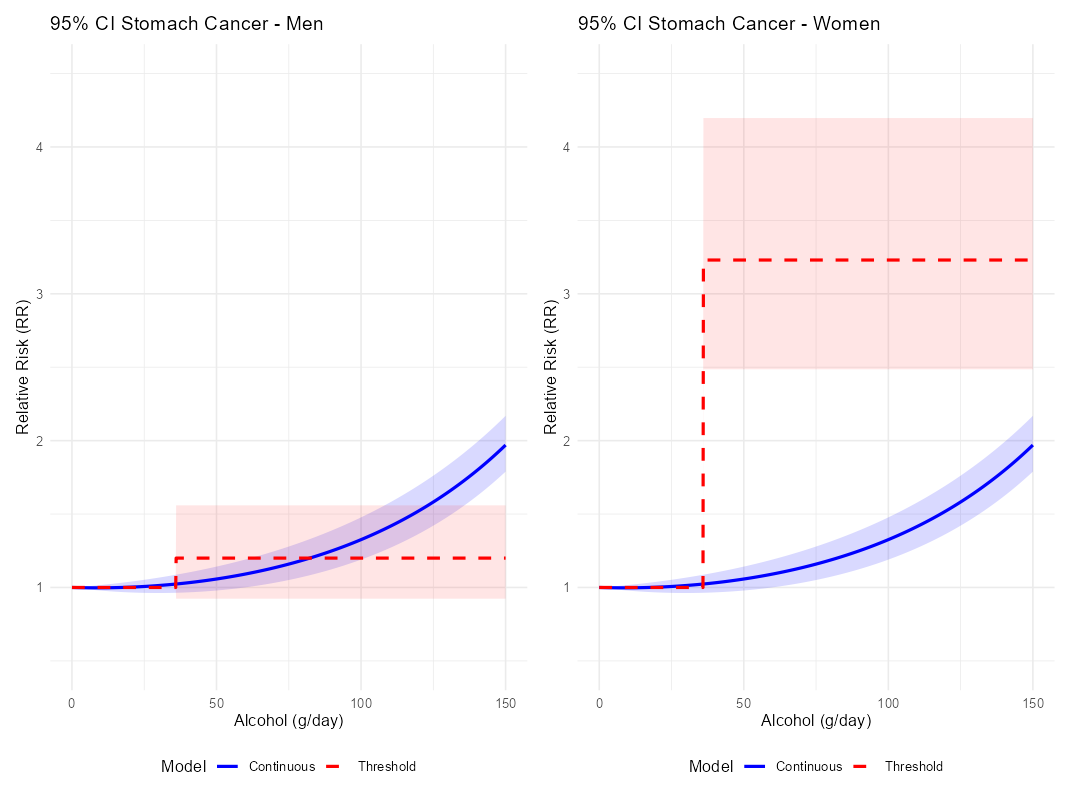

In [26]:
#| label: mort-trends-age-sex-chile27
#| results: "hold"

#source(paste0(getwd(),"/stomach_stomach_diffs.R"))
# Load libraries (using package::function syntax instead of library calls)
set.seed(2125)
# 1. Define exposure and population distribution (Gamma)
x <- seq(0, 150, length.out = 1000)
gamma_dens <- stats::dgamma(x, shape = 2, scale = 15)
scale_factor <- 4 / max(gamma_dens) # Visual adjustment for the background
print(paste0("Percentile of value 36: ", stats::pgamma(36, shape = 2, scale = 15) * 100))
# 2. Set parameters for the Continuous Model (Polynomial)
betaCurrent <- c(0, -0.00058, 0.000034, 0)
covBetaCurrent <- matrix(c(
  0, 0, 0, 0,
  0, 0.000001038, -0.00000000479, 0,
  0, -0.00000000479, 0.0000000000225, 0,
  0, 0, 0, 0
), nrow = 4, ncol = 4)
# 3. Build design matrix X for pointwise variance calculation
# Each row represents [1, x, x^2, x^3]
X_mat <- cbind(1, x, x^2, x^3)
# Linear predictor (log RR)
lp_poly <- X_mat %*% betaCurrent
# Delta method: Var(LP) = diag(X %*% Cov %*% t(X))
# Optimized in R to avoid computing a giant 1000x1000 matrix:
var_lp_poly <- rowSums((X_mat %*% covBetaCurrent) * X_mat)
se_lp_poly <- sqrt(var_lp_poly)
# 4. Create the Base Data Frame
df <- data.frame(
  x = x,
  scaled_density = gamma_dens * scale_factor,
  # Continuous Model with its 95% CI
  rr_poly = exp(lp_poly),
  poly_low = exp(lp_poly - 1.96 * se_lp_poly),
  poly_high = exp(lp_poly + 1.96 * se_lp_poly)
)
# 5. Add the Threshold (Step) Model with its 95% CI
se_step <- 0.133617
# Men (Base: log(1.20))
df$rr_step_m  <- ifelse(df$x < 36, 1, 1.20)
df$step_m_low  <- ifelse(df$x < 36, 1, exp(log(1.20) - 1.96 * se_step))
df$step_m_high <- ifelse(df$x < 36, 1, exp(log(1.20) + 1.96 * se_step))
# Women (Base: log(3.23))
df$rr_step_f  <- ifelse(df$x < 36, 1, 3.23)
df$step_f_low  <- ifelse(df$x < 36, 1, exp(log(3.23) - 1.96 * se_step))
df$step_f_high <- ifelse(df$x < 36, 1, exp(log(3.23) + 1.96 * se_step))
# 6. PLOT - MEN
plot_male <- ggplot2::ggplot(df, ggplot2::aes(x = x)) +
  ggplot2::geom_area(ggplot2::aes(y = scaled_density), fill = "gray70", alpha = 0.25) +
  # Confidence bands (Ribbons)
  ggplot2::geom_ribbon(ggplot2::aes(ymin = poly_low, ymax = poly_high), fill = "blue", alpha = 0.15) +
  ggplot2::geom_ribbon(ggplot2::aes(ymin = step_m_low, ymax = step_m_high), fill = "red", alpha = 0.1) +
  # Model lines
  ggplot2::geom_line(ggplot2::aes(y = rr_poly, color = "Continuous"), linewidth = 1) +
  ggplot2::geom_line(ggplot2::aes(y = rr_step_m, color = "Threshold"), linetype = "dashed", linewidth = 1) +
  ggplot2::scale_color_manual(values = c("Continuous" = "blue", "Threshold" = "red")) +
  ggplot2::scale_y_continuous(limits = c(0.5, 4.5), name = "Relative Risk (RR)") +
  ggplot2::labs(title = "95% CI Stomach Cancer - Men", x = "Alcohol (g/day)", color = "Model") +
  ggplot2::theme_minimal() + ggplot2::theme(legend.position = "bottom")
# 7. PLOT - WOMEN
plot_female <- ggplot2::ggplot(df, ggplot2::aes(x = x)) +
  ggplot2::geom_area(ggplot2::aes(y = scaled_density), fill = "gray70", alpha = 0.25) +
  # Confidence bands (Ribbons)
  ggplot2::geom_ribbon(ggplot2::aes(ymin = poly_low, ymax = poly_high), fill = "blue", alpha = 0.15) +
  ggplot2::geom_ribbon(ggplot2::aes(ymin = step_f_low, ymax = step_f_high), fill = "red", alpha = 0.1) +
  # Model lines
  ggplot2::geom_line(ggplot2::aes(y = rr_poly, color = "Continuous"), linewidth = 1) +
  ggplot2::geom_line(ggplot2::aes(y = rr_step_f, color = "Threshold"), linetype = "dashed", linewidth = 1) +
  ggplot2::scale_color_manual(values = c("Continuous" = "blue", "Threshold" = "red")) +
  ggplot2::scale_y_continuous(limits = c(0.5, 4.5), name = "Relative Risk (RR)") +
  ggplot2::labs(title = "95% CI Stomach Cancer - Women", x = "Alcohol (g/day)", color = "Model") +
  ggplot2::theme_minimal() + ggplot2::theme(legend.position = "bottom")
# Display both plots together using patchwork without calling library()
patchwork::wrap_plots(plot_male, plot_female)


### Results

We replicate the results of JRT [@ruiztagle2026sex] but with WHO 2024's AAFs [@who2025alcohol]. We also compared them with Sherk's 2016 report on cancer [@sherk2017intermahp].

#### Pop est

In [27]:
#| label: mort-trends-age-sex-chile16-std-pop-pre
#| results: "hold"

if(!file.exists(file.path(paste0(gsub("/__andres_control","",getwd())),
    "__andres_control",
    "ine_proyecciones_2012_2024.xlsx"))){
  # 2026-07-02= Build ine_proyecciones_2012-2024.xlsx
  # Replicates the structure of the project's ine_proyecciones.xlsx using
  # INE Chile proyeccion base 2024 data, but restricted to years 2012-2024.
  #
  # Source: INE Estimaciones y Proyecciones de Poblacion 1992-2070, base 2024
  # Useful tab: base-de-datos.xlsx -> "BBDD_EEPP-2024_0101"
  # Reference date used: 30 June (Poblacion al 30 de junio), demographically
  # conventional for rate denominators. Set reference_date = "01-01" for
  # January 1 stocks if preferred.
  # -----------------------------------------------------------------------------
  # 1. Settings
  # -----------------------------------------------------------------------------
  url_ine <- paste0(
    "https://www.ine.gob.cl/docs/default-source/proyecciones-de-poblacion/",
    "cuadros-estadisticos/proyecci%C3%B3n-base-2024/",
    "estimaciones-y-proyecciones-de-poblaci%C3%B3n-1992-2070_base-2024_base-de-datos.xlsx",
    "?sfvrsn=8e7df320_6"
  )
  src_file      <- "ine_basedatos.xlsx"    # downloaded INE file
  out_file      <- "ine_proyecciones_2012_2024.xlsx"
  first_year    <- 2012L
  last_year     <- 2024L
  reference_date <- "30-06"                # "30-06" (mid-year) or "01-01"
  # -----------------------------------------------------------------------------
  # 2. Download source if missing
  # -----------------------------------------------------------------------------
  if (!file.exists(src_file)) {
    message("Downloading INE base-de-datos file...")
    utils::download.file(url_ine, destfile = src_file, mode = "wb")
  }
  # -----------------------------------------------------------------------------
  # 3. Read long-format database
  # -----------------------------------------------------------------------------
  raw <- readxl::read_xlsx(src_file, sheet = "BBDD_EEPP-2024_0101")

  raw$year <- as.numeric(format(as.Date(raw$FECHA, format = "%d/%m/%Y"), "%Y"))
  raw$day_month <- format(as.Date(raw$FECHA, format = "%d/%m/%Y"), "%d-%m")
  # -----------------------------------------------------------------------------
  # 4. Filter reference date, years, and national level
  # -----------------------------------------------------------------------------
  df <- raw |>
    dplyr::filter(
      .data$NIVEL == "PAÍS",
      .data$day_month == reference_date,
      .data$year >= first_year,
      .data$year <= last_year
    )
  # -----------------------------------------------------------------------------
  # 5. Build one sex sheet
  # -----------------------------------------------------------------------------
  make_sex_sheet <- function(df_long, sex_code, sex_label) {
    out <- df_long |>
      dplyr::filter(.data$SEXO == sex_code) |>
      dplyr::select(edad = "EDAD", year = "year", poblacion = "POBLACION") |>
      tidyr::pivot_wider(
        names_from = "year",
        names_prefix = "ano_",
        values_from = "poblacion"
      ) |>
      dplyr::arrange(.data$edad)
    # Match the original file age labels: "0.0", "1.0", ..., "99.0", "100+"
    out <- out |>
      dplyr::mutate(
        edad = dplyr::if_else(.data$edad == 100L, "100+", paste0(.data$edad, ".0"))
      ) |>
      dplyr::relocate("edad")
    message("Built sheet '", sex_label, "': ", nrow(out), " rows x ", ncol(out), " cols")
    out
  }
  sheet_hombres <- make_sex_sheet(df, "H", "Hombres")
  sheet_mujeres <- make_sex_sheet(df, "M", "Mujeres")
  # -----------------------------------------------------------------------------
  # 6. Write Excel with same sheet names as the original
  # -----------------------------------------------------------------------------
  writexl::write_xlsx(
    list(Hombres = sheet_hombres, Mujeres = sheet_mujeres),
    path = out_file
  )
  message("Wrote ", out_file)
} else {
  message("Already created\n")
  # 2026-07-02= Import directly statistics from 2012-2024
  sheet_hombres <- readxl::read_xlsx(
    file.path(paste0(gsub("/__andres_control","",getwd())),
    "__andres_control",
    "ine_proyecciones_2012_2024.xlsx"), sheet = "Hombres") # male
    sheet_mujeres <- readxl::read_xlsx(
    file.path(paste0(gsub("/__andres_control","",getwd())),
    "__andres_control",
    "ine_proyecciones_2012_2024.xlsx"), sheet = "Mujeres") # female
}
# -----------------------------------------------------------------------------
# 7. Quick validation against original structure
# -----------------------------------------------------------------------------
orig <- readxl::read_xlsx(
  (paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ine_proyecciones.xlsx")),
  sheet = 1
)
cat("\n**Validation:**\n")
cat("Original Hombres dimensions:", nrow(orig), "x", ncol(orig), "\n")
cat("New Hombres dimensions:", nrow(sheet_hombres), "x", ncol(sheet_mujeres), "\n")
cat("Expected rows (0-99 + 100+):", 101L, "\n")
cat("Years in new file:", paste(names(sheet_hombres)[-1], collapse = ", "), "\n")

Already created


**Validation:**
Original Hombres dimensions: 101 x 10 
New Hombres dimensions: 101 x 14 
Expected rows (0-99 + 100+): 101 
Years in new file: ano_2012, ano_2013, ano_2014, ano_2015, ano_2016, ano_2017, ano_2018, ano_2019, ano_2020, ano_2021, ano_2022, ano_2023, ano_2024 


In [28]:
#| label: mort-trends-age-sex-chile16-std-pop
#| results: "hold"

# 2026-06-01= spw_male & spw_fem: calculate pop = sum(tot) antes de filter(age_group > 0), 
# so pop includes <15 years old and adult weights of 4 groups sum ~0.74. 
# spw_tot: make bind_rows of spw_male/spw_fem 
# that have been already filtered >0, then pop = sum(tot): weights sum 1.
# So, it is corrected.
prep_pop_age <- function(dat) {
  dat |>
    dplyr::mutate(
      edad = as.numeric(ifelse(edad == "100+", 100, edad))) |> 
    # (superseded 2026-07-10) formerly excluded age >=65 (i.e. <65)
    # 2026-07-10 = Include age 65: group 4 = 60-65 (edad <=65), matching deaths and the ENPG 12-65 frame
    dplyr::filter(edad <=65) |> 
    dplyr::mutate(  
      age_group = dplyr::case_when(
        edad < 15 ~ 0L,
        dplyr::between(edad, 15, 29) ~ 1L,
        dplyr::between(edad, 30, 44) ~ 2L,
        dplyr::between(edad, 45, 59) ~ 3L,
        edad >= 60 ~ 4L
      )
    ) |>
    tidyr::pivot_longer(
      cols = tidyselect::starts_with("ano_"),
      names_to = "year",
      values_to = "value"
    ) |>
    dplyr::mutate(year = as.numeric(gsub("ano_", "", year))) |>
    dplyr::group_by(year, age_group) |>
    dplyr::summarise(tot = sum(value, na.rm = TRUE), .groups = "drop")
}
pop_male <- prep_pop_age(sheet_hombres)
pop_fem <- prep_pop_age(sheet_mujeres)
pop_tot <- dplyr::bind_rows(pop_male, pop_fem) |>
  dplyr::group_by(year, age_group) |>
  dplyr::summarise(tot = sum(tot, na.rm = TRUE), .groups = "drop")
make_chile2018_std <- function(pop_tot, adult_denominator = TRUE) {
  std0 <- pop_tot |> dplyr::filter(year == 2018)
  denom <- if (adult_denominator) {
    std0 |> dplyr::filter(age_group > 0) |> dplyr::summarise(n = sum(tot)) |> dplyr::pull(n)
  } else {
    std0 |> dplyr::summarise(n = sum(tot)) |> dplyr::pull(n)
  }
  std0 |>
    dplyr::filter(age_group > 0) |>
    dplyr::transmute(age_group, spw = tot / denom)
}

std_chile2018_15plus <- make_chile2018_std(pop_tot, adult_denominator = TRUE)
std_chile2018_all_age <- make_chile2018_std(pop_tot, adult_denominator = FALSE)
std_who_world_all_age <- tibble::tribble(
  ~age_group, ~spw,
  1L, (8.47 + 8.22 + 7.93) / 100,
  2L, (7.61 + 7.15 + 6.59) / 100,
  3L, (6.04 + 5.37 + 4.55) / 100,
  4L, 3.72 / 100   # 2026-07-10: WHO weight kept at the 60-64 value. Group 4 is now 60-65 (edad_cant<=65); WHO segi uses 5-yr bands with no single-year 65 weight, so this is a documented approximation. Chile-2018 std (active default) auto-includes age 65.
)
# STANDARD POPULATION
# Choose ONE:
std_age <- std_chile2018_15plus      # 15+
# std_age <- std_chile2018_all_age   # all-ages Chile 2018
# std_age <- std_who_world_all_age   # comparison w/ WHO GHO all-ages
spw_male <- pop_male |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")
spw_fem <- pop_fem |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")
spw_tot <- pop_tot |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")

# 2026-07-02: population source (sheet_hombres/sheet_mujeres) only covers 2012-2024.
# Years present in mortality_results but absent from the population source are dropped
# from the standardized rate below (no denominator to standardize against for them).
discarded_years <- sort(setdiff(unique(mortality_results$year), unique(spw_tot$year)))
if (length(discarded_years) > 0) {
  message(
    "Standardized rates: discarding year(s) ", paste(discarded_years, collapse = ", "),
    " - no population data available (source covers 2012-2024 only)."
  )
}
# 2026-06-02= GPT complete version (w/ IC + NAs guard). Keep it as is.
# 2026-07-02= stop() on missing tot/spw replaced with a silent drop; the years this
# affects (2008, 2010) are already reported once above via `discarded_years`.
make_std_rate <- function(dat, pop_df, group_label) {
  joined <- dat |>
    dplyr::group_by(year, age_group) |>
    dplyr::summarise(
      mort = sum(mort, na.rm = TRUE),
      ll_mort = sum(ll_mort, na.rm = TRUE),
      up_mort = sum(up_mort, na.rm = TRUE),
      .groups = "drop"
    ) |>
    dplyr::left_join(
      pop_df |> dplyr::ungroup() |> dplyr::select(year, age_group, tot, spw),
      by = c("year", "age_group")
    ) |>
    dplyr::filter(!is.na(tot), !is.na(spw))

  joined |>
    dplyr::mutate(
      mort_rate    = mort    / tot * 100000,
      ll_mort_rate = ll_mort / tot * 100000,
      up_mort_rate = up_mort / tot * 100000
    ) |>
    dplyr::group_by(year) |>
    dplyr::summarise(
      std_mort_rate    = sum(mort_rate * spw),
      ll_std_mort_rate = sum(ll_mort_rate * spw),
      up_std_mort_rate = sum(up_mort_rate * spw),
      .groups = "drop"
    ) |>
    dplyr::mutate(gender = group_label) # to match Figure 1 ENG labels
}
# Watch out for the labels: Figure 1 keys are in "Male"/"Female"/"Total".
# Filter is in spanish (mortality gender = "Hombre"/"Mujer"),
# but output label should be in english so they can match.
std_rates <- dplyr::bind_rows(
  make_std_rate(mortality_results,                                    spw_tot,  "Total"),
  make_std_rate(mortality_results |> dplyr::filter(gender == "Hombre"), spw_male, "Male"),
  make_std_rate(mortality_results |> dplyr::filter(gender == "Mujer"),  spw_fem,  "Female")
)
# to avoid touching figure 1. use the same expected name 
combined_results <- std_rates |> dplyr::filter(year%%2==0)
combined_results |> 
knitr::kable("markdown", caption= "Standardized population")



Table: Standardized population

| year| std_mort_rate| ll_std_mort_rate| up_std_mort_rate|gender |
|----:|-------------:|----------------:|----------------:|:------|
| 2012|     29.206159|        15.561732|         43.44797|Total  |
| 2014|     28.655842|        15.048346|         42.59674|Total  |
| 2016|     27.901407|        13.905710|         41.80971|Total  |
| 2018|     25.367548|        12.332048|         38.38180|Total  |
| 2020|     27.097440|        14.452141|         39.73953|Total  |
| 2022|     27.650936|        14.094338|         41.46909|Total  |
| 2024|     21.625406|        10.346056|         33.43899|Total  |
| 2012|     48.693390|        27.144600|         70.92805|Male   |
| 2014|     47.978596|        26.615271|         69.58002|Male   |
| 2016|     45.518108|        24.139499|         66.68751|Male   |
| 2018|     41.292964|        21.600334|         61.01255|Male   |
| 2020|     44.294117|        25.093241|         63.38573|Male   |
| 2022|     45.890504|      

In [29]:
#| label: mort-trends-age-sex-chile16b-std-pop
#| results: "hold"
dplyr::bind_rows(
  spw_tot |> dplyr::group_by(year) |> dplyr::summarise(group = "Total", sum_spw = sum(spw), .groups = "drop"),
  spw_male |> dplyr::group_by(year) |> dplyr::summarise(group = "Hombre", sum_spw = sum(spw), .groups = "drop"),
  spw_fem |> dplyr::group_by(year) |> dplyr::summarise(group = "Mujer", sum_spw = sum(spw), .groups = "drop")
) |>
  dplyr::group_by(group) |>
  dplyr::summarise(min_sum = min(sum_spw), max_sum = max(sum_spw), .groups = "drop") |> 
  print()
# --- VALIDATE the standard (not only min==max: expected value) ---
expected_sum <- 1.0   # std_chile2018_15plus sum 1.0 through 15+
                      # (if we change to all-ages/WHO, use 0.4183, as of 2026-07-02, restricting >=65)
check_spw <- dplyr::bind_rows(
  spw_tot  |> dplyr::group_by(year) |> dplyr::summarise(group = "Total",  sum_spw = sum(spw), .groups = "drop"),
  spw_male |> dplyr::group_by(year) |> dplyr::summarise(group = "Hombre", sum_spw = sum(spw), .groups = "drop"),
  spw_fem  |> dplyr::group_by(year) |> dplyr::summarise(group = "Mujer",  sum_spw = sum(spw), .groups = "drop")
)
# 1) no NA (left_join(std_age) doesnt fail and no age_group is missing)
if (any(is.na(check_spw$sum_spw)))
  stop("spw with NA: left_join(std_age) failed or an age group was missing in pop_* database.")
# 2) all three groups, every year, sum exactly the chosen standard
if (!all(abs(check_spw$sum_spw - expected_sum) < 1e-6))
  stop(sprintf("spw does not sum %.5f in an age.group (observed range [%.5f, %.5f]). Check std_age.",
               expected_sum, min(check_spw$sum_spw), max(check_spw$sum_spw)))
# 3) confirmed that std_age is the one im using
if (abs(sum(std_age$spw) - expected_sum) >= 1e-6)
  stop(sprintf("std_age sums %.5f, and expected %.5f. Did you take std_chile2018_15plus?",
               sum(std_age$spw), expected_sum))
cat(sprintf("OK standardization: spw = %.4f in %d age group (std_age = std_chile2018_15plus).\n",
            expected_sum, nrow(check_spw)))

# A tibble: 3 × 3
  group  min_sum max_sum
  <chr>    <dbl>   <dbl>
1 Hombre       1       1
2 Mujer        1       1
3 Total        1       1
OK standardization: spw = 1.0000 in 39 age group (std_age = std_chile2018_15plus).


### Comparison with Cancer AAF (JRT)

We built a comparable table, by including Pancreatic and Stomach cancer, that I included once, but then I ended leaving them out because Shield et al 2025 did not consider them in their pipeline. Then, we aggregated data by year, gender and age group to obtain the alcohol attributable for each cancer.

In [30]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-1pre
#| results: "hold"

cancer_name_map <- c(
  "Breast Cancer" = "Breast Cancer",
  "Colon and rectum Cancer" = "Colorectal Cancer",   # naming differs between the two sources
  "Larynx Cancer" = "Larynx Cancer",
  "Liver Cancer" = "Liver Cancer",
  "Oesophagus Cancer" = "Oesophagus Cancer",
  "Oral Cavity and Pharynx Cancer" = "Oral Cavity and Pharynx Cancer",
  "Pancreatic Cancer" = "Pancreatic Cancer",
  "Stomach Cancer" = "Stomach Cancer"
)
age_group_lbl <- c(`1` = "15-29", `2` = "30-44", `3` = "45-59", `4` = "60-65")
sex_lbl <- c(Mujer = "Female", Hombre = "Male")

pipeline_cancer <- purrr::imap_dfr(disease_filters[names(cancer_name_map)], function(filter_info, disease_name) {
  filter_col <- filter_info$filter_col
  purrr::map_dfr(filter_info$genders, function(gender_i) {
    def |>
      dplyr::filter(gender == gender_i, year %in% unique(aaf_long$year)) |>
      dplyr::group_by(year, gender, age_group) |>
      dplyr::summarise(n = sum(.data[[filter_col]] == 1, na.rm = TRUE), .groups = "drop") |>
      dplyr::left_join(
        aaf_long |>
          dplyr::filter(disease == disease_name, gender == gender_i) |>
          dplyr::distinct(year, age_group, gender, disease, .keep_all = TRUE),
        by = c("year", "age_group", "gender")
      ) |>
      dplyr::transmute(
        Year = year,
        disease = cancer_name_map[[disease_name]],
        sex = sex_lbl[gender],
        age_group = age_group_lbl[as.character(age_group)],
        AAF = point, LL = lower, UL = upper,
        muertes = n,
        att_mort = round(point * n),
        att_mort_low = round(lower * n),
        att_mort_up = round(upper * n)
      )
  })
}) |>
  dplyr::filter(!is.na(AAF))

In [31]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-1
#| results: "hold"

pipeline_cancer_rounded <- pipeline_cancer |>
  #round to 4 decimals
  dplyr::mutate(dplyr::across(dplyr::matches("AAF|LL|UL"), ~ round(.x, 4)))
html_table <- tags$div(
  style = "max-height: 350px; overflow-y: auto;",
  tags$style(HTML("
    .simple-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
    .simple-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.3em; }
    .simple-table th, .simple-table td { padding: 0.1em 0.3em; text-align: left; border-bottom: 1px solid #ccc; }
    .simple-table th { border-bottom: 1.5px solid #333; }
    .simple-table .num { text-align: right; }
    /* scroll box */
    .scroll-box { max-height: 350px; overflow-y: auto; }
  ")),
  tags$table(
    class = "simple-table",
    tags$caption("Pipeline cancer estimates"),
    tags$thead(
      tags$tr(lapply(names(pipeline_cancer_rounded), tags$th))
    ),
    tags$tbody(
      lapply(seq_len(nrow(pipeline_cancer_rounded)), function(i) {
        row <- pipeline_cancer_rounded[i, ]
        tags$tr(
          lapply(seq_along(row), function(j) {
            val <- row[[j]]
            if (is.numeric(val)) {
              tags$td(class = "num", format(val, trim = TRUE))
            } else {
              tags$td(as.character(val))
            }
          })
        )
      })
    )
  )
)
htmltools::browsable(html_table)

Year,disease,sex,age_group,AAF,LL,UL,muertes,att_mort,att_mort_low,att_mort_up
2012,Breast Cancer,Female,15-29,0.0311,0.0248,0.0381,3,0,0,0
2012,Breast Cancer,Female,30-44,0.0223,0.0179,0.0271,116,3,2,3
2012,Breast Cancer,Female,45-59,0.0237,0.0179,0.0294,372,9,7,11
2012,Breast Cancer,Female,60-65,0.0137,0.0103,0.0174,165,2,2,3
2014,Breast Cancer,Female,15-29,0.0329,0.0271,0.0392,6,0,0,0
2014,Breast Cancer,Female,30-44,0.0329,0.0265,0.0396,122,4,3,5
2014,Breast Cancer,Female,45-59,0.0251,0.0206,0.0298,393,10,8,12
2014,Breast Cancer,Female,60-65,0.0217,0.0167,0.027,165,4,3,4
2016,Breast Cancer,Female,15-29,0.0345,0.0278,0.0416,4,0,0,0
2016,Breast Cancer,Female,30-44,0.033,0.0262,0.0405,114,4,3,5


In [71]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-2-aafs
#| results: "hold"

ref_cancer <- readr::read_tsv(
    file.path(gsub("__andres_control","",getwd()),
    #"__andres_control",
    "JRT_20260702_cancer",
    "Alcohol Attributable mortality (CANCER).txt"),
  locale = readr::locale(decimal_mark = ","),   # file uses comma decimals
  col_types = readr::cols()
)
cancer_compare <- pipeline_cancer |>
  dplyr::full_join(
    ref_cancer,
    by = c("Year", "disease", "sex", "age_group"),
    suffix = c("_pipeline", "_jrt")
  ) |>
  dplyr::mutate(
    diff_AAF      = AAF_pipeline - AAF_jrt,
    diff_muertes  = muertes_pipeline - muertes_jrt,
    diff_att_mort = att_mort_pipeline - att_mort_jrt
  ) |>
  dplyr::arrange(disease, Year, sex, age_group)

# rows present on only one side (full_join, so NA marks a gap on either side)
only_one_side <- cancer_compare |> 
  dplyr::filter(is.na(AAF_pipeline) | is.na(AAF_jrt)) |>
  dplyr::select(Year, disease, sex, age_group, AAF_pipeline, AAF_jrt, diff_AAF) |>
  dplyr::mutate(dplyr::across(dplyr::everything(), ~ tidyr::replace_na(as.character(.x), "NA")))
caption_html <- htmltools::tags$p(
  style = "font-family: Arial, sans-serif; font-size: 0.95em; font-weight: bold; margin-bottom: 0.3em;",
  "Rows present on only one side",
  htmltools::tags$br(),
  htmltools::tags$span(
    style = "font-weight: normal; font-size: 0.9em;",
    "NA indicates a missing match after the full_join between pipeline and JRT estimates."
  )
)
tbl <- knitr::kable(
  only_one_side,
  format = "html",
  table.attr = "style='border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; border: 1px solid #ccc;'"
)

htmltools::browsable(
  htmltools::tags$div(
    caption_html,
    htmltools::HTML(tbl)
  )
)

# max-height: 350px; overflow-y: auto; 
# aaf_table <- tags$div(
#   style = "max-height: 350px; overflow-y: auto;",
#   tags$style(HTML("
#     /* scroll box */
#     .scroll-box { max-height: 350px; overflow-y: auto; }      
#   ")),

Year,disease,sex,age_group,AAF_pipeline,AAF_jrt,diff_AAF


In [33]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-2-aafs-2
#| results: "hold"

# where AAF diverges most - expected to be nonzero everywhere: different RR source
top_aaf <- cancer_compare |>
  dplyr::arrange(dplyr::desc(abs(diff_AAF))) |>
  # dplyr::mutate(
  #   AAF_pipeline_fmt = sprintf("%.3f", AAF_pipeline),
  #   AAF_jrt_fmt      = sprintf("%.3f", AAF_jrt),
  #   diff_AAF_fmt     = sprintf("%.3f", diff_AAF)
  # ) |>
  dplyr::mutate(dplyr::across(dplyr::matches("AAF_pipeline|AAF_jrt|diff_AAF"), ~ round(.x, 4))) |> 
  dplyr::select(Year, disease, sex, age_group, AAF_pipeline, AAF_jrt, diff_AAF) |>
  head(30)
caption <- tags$caption(
  "Top 30 AAF divergences between pipeline and JRT estimates",
  tags$br(),
  tags$span("AAF differences are expected because the two estimates use different RR sources.")
)
# helper to build a row from a vector of cell contents
make_row <- function(cells, tag = tags$td) {
  tags$tr(lapply(cells, function(x) tag(x)))
}
aaf_table <- tags$div(
  style = "max-height: 350px; overflow-y: auto;",
  tags$style(HTML("
    .aaf-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
    .aaf-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.5em; }
    .aaf-table caption span { font-weight: normal; font-size: 0.9em; }
    .aaf-table th, .aaf-table td { padding: 0.3em 0.6em; text-align: left; }
    .aaf-table th { border-bottom: 1px solid black; }
    .aaf-table .num { text-align: right; }
    /* scroll box */
    .scroll-box { max-height: 350px; overflow-y: auto; }      
  ")),
  tags$table(
    class = "aaf-table",
    caption,
    tags$thead(
      tags$tr(
        tags$th("Year"),
        tags$th("Disease"),
        tags$th("Sex"),
        tags$th("Age group"),
        tags$th(class = "num", "AAF pipeline"),
        tags$th(class = "num", "AAF JRT"),
        tags$th(class = "num", "Difference")
      )
    ),
    tags$tbody(
      lapply(seq_len(nrow(top_aaf)), function(i) {
        tags$tr(
          tags$td(top_aaf$Year[i]),
          tags$td(top_aaf$disease[i]),
          tags$td(top_aaf$sex[i]),
          tags$td(top_aaf$age_group[i]),
          tags$td(class = "num", top_aaf$AAF_pipeline[i]),
          tags$td(class = "num", top_aaf$AAF_jrt[i]),
          tags$td(class = "num", top_aaf$diff_AAF[i])
        )
      })
    )
  )
)
htmltools::browsable(aaf_table)

Year,Disease,Sex,Age group,AAF pipeline,AAF JRT,Difference
2012,Oral Cavity and Pharynx Cancer,Female,45-59,0.1763,0.109,0.0673
2020,Oral Cavity and Pharynx Cancer,Male,45-59,0.3562,0.306,0.0502
2014,Oral Cavity and Pharynx Cancer,Male,30-44,0.3687,0.319,0.0497
2014,Oral Cavity and Pharynx Cancer,Male,15-29,0.3435,0.297,0.0465
2014,Oral Cavity and Pharynx Cancer,Female,30-44,0.2002,0.154,0.0462
2016,Oral Cavity and Pharynx Cancer,Female,30-44,0.186,0.142,0.044
2012,Oral Cavity and Pharynx Cancer,Female,15-29,0.1886,0.146,0.0426
2016,Oral Cavity and Pharynx Cancer,Male,30-44,0.305,0.266,0.039
2016,Oral Cavity and Pharynx Cancer,Male,45-59,0.3192,0.284,0.0352
2022,Oral Cavity and Pharynx Cancer,Female,30-44,0.1925,0.159,0.0335


In [34]:
diseases_not_available <- cancer_compare |>
  dplyr::filter(is.na(AAF_pipeline) | is.na(AAF_jrt)) |>
  dplyr::distinct(disease) |>
  dplyr::pull()
paste0("Diseases with at least one unmatched row: ", paste(diseases_not_available, collapse = ", "))


[1] "Diseases with at least one unmatched row: Breast Cancer, Colorectal Cancer, Larynx Cancer, Liver Cancer, Oesophagus Cancer, Oral Cavity and Pharynx Cancer, Pancreatic Cancer, Stomach Cancer"

In [35]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-3-deaths
#| results: "hold"

# raw mortality COUNT check - this is the more diagnostic one: both sides should be
# counting the same national ICD-coded deaths, so muertes shouldn't diverge much
# unless there's an ICD-range or de-duplication mismatch (see the paper-duplication
# bug found earlier for this same project)
top_diffs <- cancer_compare |>
  dplyr::filter(abs(diff_muertes) > 0) |>
  dplyr::select(
    Year, disease, sex, age_group,
    muertes_pipeline, muertes_jrt, diff_muertes
  ) |>
  dplyr::arrange(dplyr::desc(abs(diff_muertes)))

html_table <- tags$div(
  style = "max-height: 350px; overflow-y: auto;",
  tags$style(HTML("
    .cmp-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
    .cmp-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.5em; }
    .cmp-table caption span { font-weight: normal; font-size: 0.9em; }
    .cmp-table th, .cmp-table td { padding: 0.3em 0.6em; text-align: left; border-bottom: 1px solid #ccc; }
    .cmp-table th { border-bottom: 2px solid #333; }
    .cmp-table .num { text-align: right; }
    /* scroll box */
    .scroll-box { max-height: 350px; overflow-y: auto; }  
  ")),
  tags$table(
    class = "cmp-table",
    tags$caption(
      "Cancer mortality count discrepancies between pipeline and JRT estimates",
      tags$br(),
      tags$span(
        "Rows with non-zero differences in attributable deaths; ordered by absolute difference. ",
        "Diagnostic check: both sides should be counting the same national ICD-coded deaths. ",
        "Large divergences point to ICD-range or de-duplication mismatches."
      )
    ),
    tags$thead(
      tags$tr(
        tags$th("Year"),
        tags$th("Disease"),
        tags$th("Sex"),
        tags$th("Age group"),
        tags$th(class = "num", "Pipeline deaths"),
        tags$th(class = "num", "JRT deaths"),
        tags$th(class = "num", "Difference")
      )
    ),
    tags$tbody(
      lapply(seq_len(nrow(top_diffs)), function(i) {
        row <- top_diffs[i, ]
        tags$tr(
          tags$td(row$Year),
          tags$td(row$disease),
          tags$td(row$sex),
          tags$td(row$age_group),
          tags$td(class = "num", row$muertes_pipeline),
          tags$td(class = "num", row$muertes_jrt),
          tags$td(class = "num", row$diff_muertes)
        )
      })
    )
  )
)
htmltools::browsable(html_table)

Year,Disease,Sex,Age group,Pipeline deaths,JRT deaths,Difference
2016,Oral Cavity and Pharynx Cancer,Male,45-59,22,36,-14
2018,Oral Cavity and Pharynx Cancer,Male,45-59,32,46,-14
2022,Oral Cavity and Pharynx Cancer,Male,45-59,29,43,-14
2014,Oral Cavity and Pharynx Cancer,Male,45-59,14,27,-13
2024,Oral Cavity and Pharynx Cancer,Male,45-59,32,43,-11
2012,Oral Cavity and Pharynx Cancer,Male,45-59,27,37,-10
2016,Oral Cavity and Pharynx Cancer,Female,45-59,9,18,-9
2020,Oral Cavity and Pharynx Cancer,Female,45-59,11,20,-9
2020,Oral Cavity and Pharynx Cancer,Male,45-59,17,26,-9
2018,Oral Cavity and Pharynx Cancer,Female,45-59,7,15,-8


#### Recreate the tables 60+ 


The cancer comparison was rebuilt using a JRT-compatible mortality table generated by `__andres_control/make_jrt_compatible_cancer_table_ge60.R`.

The script does not modify the notebook or the original pipeline objects. It reads JRT's reference file, uses its row structure as the comparison template, and rebuilds our cancer mortality table from the raw DEIS mortality files. The main correction is that the `60+` age group is defined as all deaths occurring at age 60 or older, rather than the restricted `60-64` subset that had entered the shared notebook mortality object after the `edad_cant < 65` filter.
To make the mortality counts comparable with JRT, the script also harmonizes the ICD grouping used in the reference table. `Colorectal Cancer` is counted as `C18-C21`, which matches JRT's counts. `Oral Cavity and Pharynx Cancer` combines the local oral-cavity and other-pharyngeal components into one JRT-compatible category. Attributable deaths are then recomputed using our WHO 2024 AAF estimates and the harmonized mortality counts.
After this rebuild, the raw mortality counts match JRT exactly across the comparable cancer table, including the `60+` age group. Remaining differences in attributable deaths reflect differences in the AAF estimates, not differences in the underlying mortality counts.

In [36]:
#| label: mort-trends-age-sex-chile17-cancer-5a-comparison
#| results: "hold"

# 2026-07-02: compare the two sources in a single table, 
# for all rows that have a match
source(
  file.path(gsub("__andres_control","",getwd()),
    "__andres_control",
    "make_jrt_compatible_cancer_table_ge60.R")
)

.t0 <- Sys.time()

cancer_compare_comparable <- readr::read_csv(
  file.path(
    gsub("__andres_control", "", getwd()),
    "JRT_20260702_cancer",
    "pipeline_vs_jrt_cancer_all_ages.csv"
  ),
  show_col_types = FALSE
) |> 
  dplyr::rename("diff_mort" = "diff_muertes") |> 
  dplyr::mutate(AAF_pipeline= sprintf("%.4f", AAF_pipeline),
                UL_pipeline= sprintf("%.4f", UL_pipeline),
                LL_pipeline= sprintf("%.4f", LL_pipeline),
                AAF_jrt= sprintf("%.4f", AAF_jrt),
                diff_AAF= sprintf("%.4f", diff_AAF))
#select numeric columns for right alignment in the HTML table
num_cols <- vapply(cancer_compare_comparable, is.numeric, logical(1))

html_table <- htmltools::tags$div(
  style = "max-width: 100%; max-height: 400px; overflow: auto;",
  htmltools::tags$style(htmltools::HTML("
    .cmp-table {
      border-collapse: collapse;
      width: max-content;
      min-width: 100%;
      font-family: Arial, sans-serif;
      font-size: 0.85em;
    }
    .cmp-table th, .cmp-table td {
      padding: 0.25em 0.5em;
      border-bottom: 1px solid #ddd;
      white-space: nowrap;
    }
    .cmp-table th {
      position: sticky;
      top: 0;
      background: white;
      border-bottom: 2px solid #333;
    }
    .cmp-table .num {
      text-align: right;
      font-variant-numeric: tabular-nums;
    }
  ")),
  htmltools::tags$table(
    class = "cmp-table",
    htmltools::tags$thead(
      htmltools::tags$tr(lapply(names(cancer_compare_comparable), htmltools::tags$th))
    ),
    htmltools::tags$tbody(
      lapply(seq_len(nrow(cancer_compare_comparable)), function(i) {
        htmltools::tags$tr(
          lapply(seq_along(cancer_compare_comparable), function(j) {
            htmltools::tags$td(
              class = if (num_cols[j]) "num" else NULL,
              cancer_compare_comparable[[j]][i]
            )
          })
        )
      })
    )
  )
)
htmltools::browsable(html_table)

message(sprintf(
  "[%.2f min] Displayed cancer_compare_comparable.",
  as.numeric(difftime(Sys.time(), .t0, units = "mins"))
))

Starting JRT-compatible cancer comparison rebuild.
Script directory: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control
Project root: C:/Users/nDP/Desktop/ACC1240138_private
Searching for latest dated file in C:/Users/nDP/Desktop/ACC1240138_private/__andres_control with pattern aaf_nested_by_disease_YYYYMMDD.rds.
Found 3 candidate file(s): aaf_nested_by_disease_20260708.rds; aaf_nested_by_disease_20260709.rds; aaf_nested_by_disease_20260710.rds
Selected latest dated file: aaf_nested_by_disease_20260710.rds
Input path - JRT cancer table: C:/Users/nDP/Desktop/ACC1240138_private/JRT_20260702_cancer/Alcohol Attributable mortality (CANCER).txt
Input path - AAF nested bundle: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/aaf_nested_by_disease_20260710.rds
Input path - DEIS 2012-2023 parquet: C:/Users/nDP/Desktop/ACC1240138_private/ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/udpate jun 26/DEFUNCIONES_DEIS_12_23_15plus.parquet
Input path - DEIS 2024 CSV

Year,disease,sex,age_group,AAF_pipeline,LL_pipeline,UL_pipeline,muertes_pipeline,att_mort_pipeline,att_mort_low_pipeline,att_mort_up_pipeline,AAF_jrt,LL_jrt,UL_jrt,muertes_jrt,att_mort_jrt,att_mort_low_jrt,att_mort_up_jrt,diff_AAF,diff_mort,diff_att_mort
2012,Breast Cancer,Female,15-29,0.0311,0.0248,0.0381,3,0,0,0,0.0280,0.023,0.034,3,0,0,0,0.0031,0,0
2012,Breast Cancer,Female,30-44,0.0223,0.0179,0.0271,116,3,2,3,0.0200,0.016,0.024,116,2,2,3,0.0023,0,1
2012,Breast Cancer,Female,45-59,0.0237,0.0179,0.0294,372,9,7,11,0.0180,0.014,0.022,372,7,5,8,0.0057,0,2
2012,Breast Cancer,Female,60+,0.0137,0.0103,0.0174,876,12,9,15,0.0140,0.01,0.017,876,12,9,15,-0.0003,0,0
2014,Breast Cancer,Female,15-29,0.0329,0.0271,0.0392,6,0,0,0,0.0340,0.028,0.04,6,0,0,0,-0.0011,0,0
2014,Breast Cancer,Female,30-44,0.0329,0.0265,0.0396,122,4,3,5,0.0310,0.025,0.037,122,4,3,5,0.0019,0,0
2014,Breast Cancer,Female,45-59,0.0251,0.0206,0.0298,393,10,8,12,0.0260,0.022,0.032,393,10,9,13,-0.0009,0,0
2014,Breast Cancer,Female,60+,0.0217,0.0167,0.0270,901,20,15,24,0.0210,0.017,0.026,901,19,15,23,0.0007,0,1
2016,Breast Cancer,Female,15-29,0.0345,0.0278,0.0416,4,0,0,0,0.0340,0.028,0.041,4,0,0,0,0.0005,0,0
2016,Breast Cancer,Female,30-44,0.0330,0.0262,0.0405,114,4,3,5,0.0260,0.022,0.032,114,3,3,4,0.0070,0,1


[0.02 min] Displayed cancer_compare_comparable.


In [37]:
#| label: mort-trends-age-sex-chile17-cancer-4-comparable-comparison
#| results: "hold"

.t0 <- Sys.time()

top_diffs <- cancer_compare_comparable |>
  dplyr::filter(abs(diff_mort) > 0) |>
  dplyr::select(
    Year, disease, sex, age_group,
    muertes_pipeline, muertes_jrt, diff_mort
  ) |>
  dplyr::arrange(dplyr::desc(abs(diff_mort)))

if (nrow(top_diffs) == 0) {
  html_table <- htmltools::tags$div(
    htmltools::tags$style(htmltools::HTML("
      .cmp-note { font-family: Arial, sans-serif; font-size: 0.95em; }
      .cmp-note strong { font-weight: bold; }
    ")),
    htmltools::tags$p(
      class = "cmp-note",
      htmltools::tags$strong("Cancer mortality count check: PASS. "),
      "After rebuilding the JRT-compatible table with age 60+ defined as age >= 60, ",
      "pipeline and JRT mortality counts match exactly for all comparable 60+ cancer rows. ",
      "Remaining attributable-mortality differences therefore reflect AAF differences, not mortality-count mismatches."
    )
  )
} else {
  html_table <- htmltools::tags$div(
    htmltools::tags$style(htmltools::HTML("
      .cmp-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
      .cmp-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.5em; }
      .cmp-table caption span { font-weight: normal; font-size: 0.9em; }
      .cmp-table th, .cmp-table td { padding: 0.3em 0.6em; text-align: left; border-bottom: 1px solid #ccc; }
      .cmp-table th { border-bottom: 2px solid #333; }
      .cmp-table .num { text-align: right; }
    ")),
    htmltools::tags$table(
      class = "cmp-table",
      htmltools::tags$caption(
        "Cancer mortality count discrepancies between pipeline and JRT estimates",
        htmltools::tags$br(),
        htmltools::tags$span(
          "Rows with non-zero differences in raw mortality counts; ordered by absolute difference. ",
          "Diagnostic check: both sides should count the same national ICD-coded deaths."
        )
      ),
      htmltools::tags$thead(
        htmltools::tags$tr(
          htmltools::tags$th("Year"),
          htmltools::tags$th("Disease"),
          htmltools::tags$th("Sex"),
          htmltools::tags$th("Age group"),
          htmltools::tags$th(class = "num", "Pipeline deaths"),
          htmltools::tags$th(class = "num", "JRT deaths"),
          htmltools::tags$th(class = "num", "Difference")
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(top_diffs)), function(i) {
          row <- top_diffs[i, ]
          htmltools::tags$tr(
            htmltools::tags$td(row$Year),
            htmltools::tags$td(row$disease),
            htmltools::tags$td(row$sex),
            htmltools::tags$td(row$age_group),
            htmltools::tags$td(class = "num", row$muertes_pipeline),
            htmltools::tags$td(class = "num", row$muertes_jrt),
            htmltools::tags$td(class = "num", row$diff_muertes)
          )
        })
      )
    )
  )
}
htmltools::browsable(html_table)

message(sprintf(
  "[%.2f min] Reading JRT-compatible cancer comparison outputs.",
  as.numeric(difftime(Sys.time(), .t0, units = "mins"))
))

<R HTML widget>

[0.00 min] Reading JRT-compatible cancer comparison outputs.


In [38]:
#| label: mort-trends-age-sex-chile17-cancer-4-comparable-comparison-diffs-attr-deaths
#| results: "hold"

top_diffs_attr_d <- cancer_compare_comparable |>
  dplyr::mutate(
    delta_aaf = readr::parse_number(diff_AAF),
    delta_attributable_deaths = diff_att_mort,
    pct_delta_attributable_deaths = dplyr::if_else(
      abs(att_mort_jrt) > 0,
      100 * delta_attributable_deaths / abs(att_mort_jrt),
      NA_real_
    )
  ) |>
  dplyr::filter(abs(delta_aaf) > 0) |> 
  dplyr::select(
    Year, disease, sex, age_group,
    AAF_pipeline, AAF_jrt, delta_aaf,
    att_mort_pipeline, att_mort_jrt,
    att_mort_low_pipeline, att_mort_up_pipeline,
    att_mort_low_jrt, att_mort_up_jrt,
    delta_attributable_deaths,
    pct_delta_attributable_deaths
  ) |>
  dplyr::arrange(
  dplyr::desc(abs(delta_aaf))
  )|> 
  # dplyr::mutate(
  #   dplyr::across(
  #     dplyr::matches("AAF_pipeline|AAF_jrt|delta_aaf"),
  #     ~ sprintf("%.4f", .x)
  #   ),
  #   dplyr::across(
  #     dplyr::matches("att_mort_pipeline|att_mort_jrt|att_mort_low_pipeline|att_mort_up_pipeline|att_mort_low_jrt|att_mort_up_jrt|delta_attributable_deaths"),
  #     ~ as.integer(.x)
  #   ),
  dplyr::mutate(
    pct_delta_attributable_deaths = dplyr::if_else(
      is.na(pct_delta_attributable_deaths),
      NA_character_,
      sprintf("%.2f%%", pct_delta_attributable_deaths)
    )
  )

tbl_top_diffs_attr_d <-
top_diffs_attr_d |> 
   knitr::kable(
    format = "html")


caption_top_diffs_attr_d_html <- htmltools::tags$p(
  style = "font-family: Arial, sans-serif; font-size: 0.95em; font-weight: bold; margin-bottom: 0.3em;",
  "Top differences in cancer AAF estimates: WHO 2025 age-sex RRs vs. JRT estimates (both 60+ age group)",
  htmltools::tags$br(),
  htmltools::tags$span(
    style = "font-weight: normal; font-size: 0.9em;",
    ""
  )
)
htmltools::browsable(
  htmltools::tags$div(
    caption_top_diffs_attr_d_html,
    htmltools::tags$div(
      style = "max-height: 500px; overflow-y: auto; border: 0px solid #ddd;",
      htmltools::HTML(tbl_top_diffs_attr_d)
    )
  )
)

Year,disease,sex,age_group,AAF_pipeline,AAF_jrt,delta_aaf,att_mort_pipeline,att_mort_jrt,att_mort_low_pipeline,att_mort_up_pipeline,att_mort_low_jrt,att_mort_up_jrt,delta_attributable_deaths,pct_delta_attributable_deaths
2012,Oral Cavity and Pharynx Cancer,Female,45-59,0.1763,0.1090,0.0673,3,2,0,6,2,2,1,50.00%
2020,Oral Cavity and Pharynx Cancer,Male,45-59,0.3562,0.3060,0.0502,9,8,6,13,7,9,1,12.50%
2014,Oral Cavity and Pharynx Cancer,Male,30-44,0.3687,0.3190,0.0497,1,1,1,2,1,1,0,0.00%
2018,Oral Cavity and Pharynx Cancer,Male,60+,0.2210,0.2690,-0.0480,31,38,5,60,33,43,-7,-18.42%
2014,Oral Cavity and Pharynx Cancer,Male,15-29,0.3435,0.2970,0.0465,1,1,0,1,1,1,0,0.00%
2014,Oral Cavity and Pharynx Cancer,Female,30-44,0.2002,0.1540,0.0462,1,1,0,2,1,1,0,0.00%
2016,Oral Cavity and Pharynx Cancer,Female,30-44,0.1860,0.1420,0.0440,1,1,0,2,1,1,0,0.00%
2012,Oral Cavity and Pharynx Cancer,Female,15-29,0.1886,0.1460,0.0426,0,0,0,0,0,0,0,NA
2016,Oral Cavity and Pharynx Cancer,Male,30-44,0.3050,0.2660,0.0390,2,1,1,2,1,2,1,100.00%
2016,Oral Cavity and Pharynx Cancer,Male,45-59,0.3192,0.2840,0.0352,11,10,7,17,9,12,1,10.00%


#### Figure 1

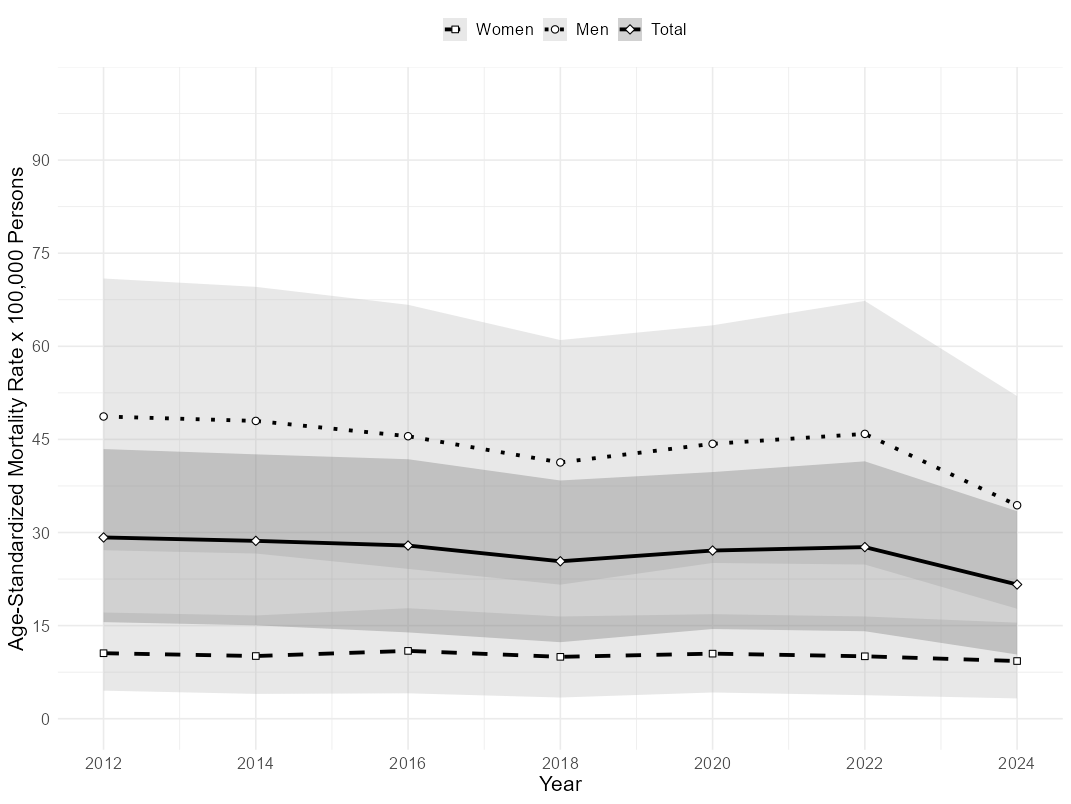

In [39]:
#| label: mort-trends-age-sex-chile17-fig1
#| results: "hold"

# Plot the unified figure
ggplot(combined_results, aes(x = year, y = std_mort_rate, linetype = gender, fill = gender)) +
  # Confidence interval ribbons
  geom_ribbon(
    aes(ymin = ll_std_mort_rate, ymax = up_std_mort_rate, fill = gender),
    alpha = 0.3, color = NA
  ) +
  # Lines for age-standardized mortality
  geom_line(
    aes(linetype = gender),
    linewidth = 1.2, color = "black"
  ) +
  # Points for age-standardized mortality
  geom_point(
    aes(shape = gender),
    size = 2, color = "black", fill = "white"
  ) +
  # Customize scales and labels
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    labels = c(2012, 2014, 2016, 2018, 2020, 2022, 2024)
  ) +
  scale_y_continuous(breaks = seq(0, 100, 15)) +
  coord_cartesian(ylim = c(0, 100)) +
  labs(
    x = "Year",
    y = "Age-Standardized Mortality Rate x 100,000 Persons",
    linetype = "",
    fill = "",
    shape = ""
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top",
    legend.key = element_blank()  # Remove background in legend
  ) +
  # Customize linetypes, fill colors, and shapes for Total and genders
  scale_linetype_manual(
    values = c("Male" = "dotted", "Female" = "dashed", "Total" = "solid"),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Male" = "gray70", "Female" = "gray70", "Total" = "gray40"),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Male" = 21, "Female" = 22, "Total" = 23),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  )

fig1 <-
  ggplot(combined_results, aes(x = year, group = gender)) +
  geom_ribbon(
    aes(ymin = ll_std_mort_rate, ymax = up_std_mort_rate, fill = gender),
    alpha = 0.38,
    color = NA
  ) +
  geom_line(
    aes(y = std_mort_rate, linetype = gender),
    linewidth = 1.15,
    color = "black"
  ) +
  geom_point(
    aes(y = std_mort_rate, shape = gender),
    size = 2.6,
    color = "black",
    fill = "white",
    stroke = 0.85
  ) +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    expand = expansion(mult = c(0.01, 0.03))
  ) +
  scale_y_continuous(
    breaks = seq(0, 100, 15),
    expand = expansion(mult = c(0.01, 0.04))
  ) +
  coord_cartesian(ylim = c(0, 100)) +
  scale_linetype_manual(
    values = c("Female" = "dashed", "Male" = "dotted", "Total" = "solid"),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Female" = 22, "Male" = 21, "Total" = 23),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Female" = "grey82", "Male" = "grey82", "Total" = "grey55"),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  labs(
    x = "Year",
    y = "Age-Standardized Mortality Rate x 100,000 Persons",
    linetype = NULL,
    shape = NULL,
    fill = NULL
  ) +
  guides(
    fill = "none",
    linetype = guide_legend(nrow = 1),
    shape = guide_legend(nrow = 1)
  ) +
  theme_minimal(base_size = 17) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.text = element_text(size = 16),
    legend.key = element_rect(fill = "grey82", color = NA),
    legend.key.width = unit(0.95, "cm"),
    legend.spacing.x = unit(0.25, "cm"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 15),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3),
    plot.margin = margin(8, 12, 8, 12)
  )
ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 1.png"
  ),
  plot = fig1,
  width = 5.52,
  height = 7.11,
  units = "in",
  dpi = 300,
  bg = "white"
)

In [40]:
#| label: mort-trends-age-sex-chile18-fig2-pre
#| results: "hold"

death_sex <- def %>%
  group_by(year, gender) %>%
  summarise(n = n(), .groups = "drop")

tot_death <- def %>%
  group_by(year) %>%
  summarise(n = n(), .groups = "drop")

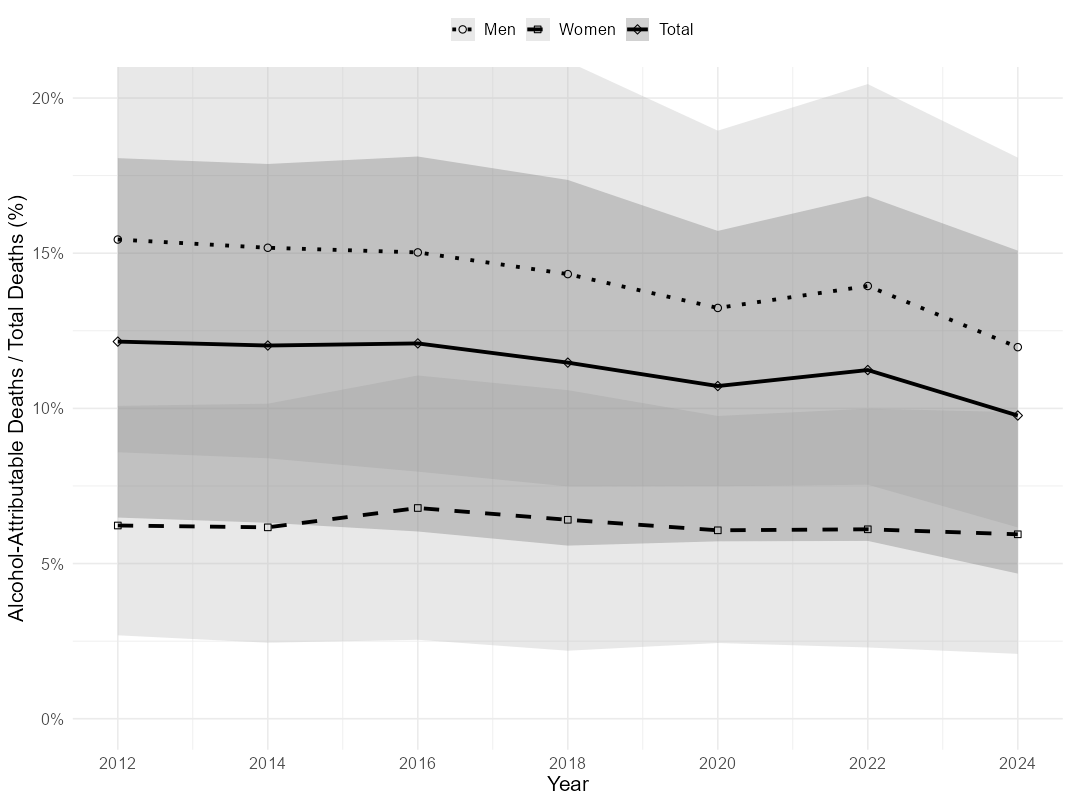

In [41]:
#| label: mort-trends-age-sex-chile18-fig2
#| results: "hold"

# 1. Adjust to transform into percentage
gender_data <- mortality_results |> 
  dplyr::filter(year %% 2==0, year>=2012) |> 
  group_by(year, gender) %>% 
  summarise(
    mort = sum(mort),
    ll_mort = sum(ll_mort),
    up_mort = sum(up_mort),
    .groups = "drop"
  ) %>% 
  left_join(death_sex, by = c("year", "gender")) %>% 
  mutate(
    prop = (mort / n) * 100,      # Multiplicado por 100
    ll_prop = (ll_mort / n) * 100,
    up_prop = (up_mort / n) * 100
  )
total_data <- mortality_results %>% 
  group_by(year) %>% 
  summarise(
    mort = sum(mort),
    ll_mort = sum(ll_mort),
    up_mort = sum(up_mort),
    .groups = "drop"
  ) %>% 
  left_join(tot_death, by = "year") %>% 
  mutate(
    prop = (mort / n) * 100,      # Multiplicado por 100
    ll_prop = (ll_mort / n) * 100,
    up_prop = (up_mort / n) * 100
  ) %>% 
  mutate(gender = "Total")
combined_data <- bind_rows(gender_data, total_data) |>
        dplyr::filter(year %% 2==0, year>=2012)

# 2. Ajustar el grÃ¡fico
ggplot(combined_data) +
  geom_ribbon(
    aes(x = year, ymin = ll_prop, ymax = up_prop, fill = gender),
    alpha = 0.3, color = NA
  ) +
  geom_line(
    aes(x = year, y = prop, linetype = gender),
    color = "black", linewidth = 1.2 # Se recomienda usar linewidth en versiones recientes
  ) +
  geom_point(
    aes(x = year, y = prop, shape = gender),
    color = "black", size = 2
  ) +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2)
  ) +
  # Ajustar escala Y de 0 a 20 (que representa 0% a 20%)
  scale_y_continuous(
    breaks = seq(0, 20, 5),
    labels = function(x) paste0(x, "%")
  ) +
  coord_cartesian(ylim = c(0, 20)) +
  labs(
    x = "Year",
    y = "Alcohol-Attributable Deaths / Total Deaths (%)",
    linetype = "",
    shape = "",
    fill = ""
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top"
  ) +
  scale_linetype_manual(
    values = c("Hombre" = "dotted", "Mujer" = "dashed", "Total" = "solid"),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Hombre" = "gray70", "Mujer" = "gray70", "Total" = "gray40"),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Hombre" = 21, "Mujer" = 22, "Total" = 23),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  )

combined_data <- bind_rows(gender_data, total_data) |> 
  dplyr::filter(year %% 2==0, year>=2012) |> 
  dplyr::mutate(gender = factor(gender, levels = c("Mujer", "Hombre", "Total")))

fig2 <- ggplot(combined_data, aes(x = year, group = gender)) +
  geom_ribbon(
    aes(ymin = ll_prop, ymax = up_prop, fill = gender),
    alpha = 0.38,
    color = NA
  ) +
  geom_line(
    aes(y = prop, linetype = gender),
    color = "black",
    linewidth = 1.15
  ) +
  geom_point(
    aes(y = prop, shape = gender),
    color = "black",
    fill = "white",
    size = 2.6,
    stroke = 0.85
  ) +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    expand = expansion(mult = c(0.01, 0.03))
  ) +
  scale_y_continuous(
    breaks = seq(5, 25, 5),
    labels = function(x) paste0(x, "%"),
    expand = expansion(mult = c(0.01, 0.04))
  ) +
  #coord_cartesian(ylim = c(5, 25.8)) +
  scale_linetype_manual(
    values = c("Mujer" = "dashed", "Hombre" = "dotted", "Total" = "solid"),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Mujer" = 22, "Hombre" = 21, "Total" = 23),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Mujer" = "grey82", "Hombre" = "grey82", "Total" = "grey55"),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  labs(
    x = "Year",
    y = "Alcohol-Attributable Deaths / Total Deaths",
    linetype = NULL,
    shape = NULL,
    fill = NULL
  ) +
  guides(
    fill = "none",
    linetype = guide_legend(nrow = 1),
    shape = guide_legend(nrow = 1)
  ) +
  theme_minimal(base_size = 17) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.text = element_text(size = 16),
    legend.key = element_rect(fill = "grey82", color = NA),
    legend.key.width = unit(0.95, "cm"),
    legend.spacing.x = unit(0.25, "cm"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 15),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3),
    plot.margin = margin(8, 12, 8, 12)
  )
ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 2.png"
  ),
  plot = fig2,
  width = 5.52,
  height = 7.11,
  units = "in",
  dpi = 300,
  bg = "white"
)


#### Figure 3

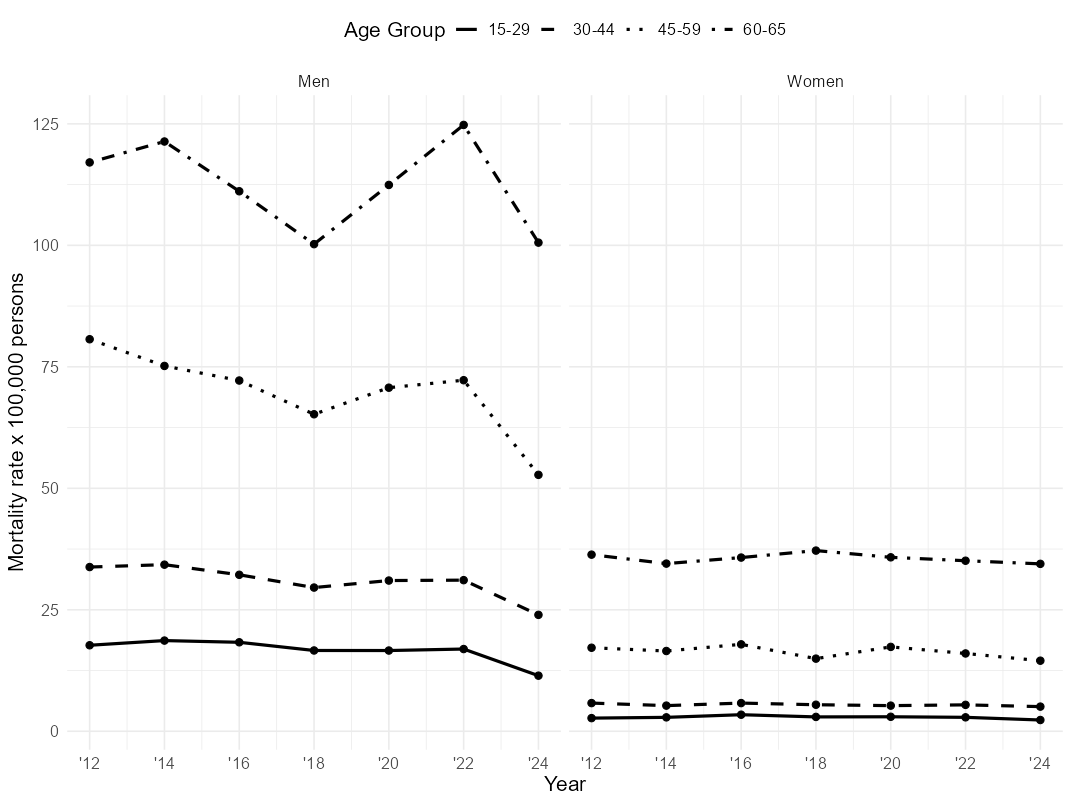

In [42]:
#| label: mort-trends-age-sex-chile19-fig3
#| results: "hold"

# 2026-06-02: stop dividing deaths by sex by the total population
spw_by_sex <- dplyr::bind_rows(
  spw_male |> dplyr::mutate(gender = "Hombre"),
  spw_fem  |> dplyr::mutate(gender = "Mujer")
) |> dplyr::select(year, age_group, gender, tot, spw) |> 
  dplyr::filter(year %% 2==0, year>=2012)

mortality_results |> 
  dplyr::filter(year %% 2==0, year>=2012) |> 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group) # Se eliminÃ³ .groups
  ) %>% 
  # 2026-06-02: divide deaths by sex by the total population
    left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>%
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000
  ) %>% 
  ggplot(aes(x = year, y = mort_rate, linetype = factor(age_group))) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    labels = function(x) paste0("'", substr(as.character(x), 3, 4))
  ) +
  scale_linetype_manual(
    values = c("1" = "solid", "2" = "dashed", "3" = "dotted", "4" = "dotdash"),
    labels = c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65")
  ) +
  facet_wrap(~ gender, labeller = as_labeller(c("Mujer" = "Women", "Hombre" = "Men"))) +
  labs(
    x = "Year",
    y = "Mortality rate x 100,000 persons",
    linetype = "Age Group"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top"
  )
fig3 <- mortality_results %>% 
  dplyr::filter(year %% 2 == 0, year >= 2012) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group)
  ) %>% 
  # 2026-06-02: divide deaths by sex by the total population
  left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>%
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000,
    gender = factor(gender, levels = c("Hombre", "Mujer")),
    age_group = factor(age_group, levels = c("1", "2", "3", "4"))
  ) %>% 
  ggplot(aes(x = year, y = mort_rate, linetype = age_group)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.4, color = "black") +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    labels = function(x) paste0("'", substr(as.character(x), 3, 4))
  ) +
  scale_y_continuous(
    breaks = c(0, 200, 400),
    limits = c(0, 600)
  ) +
  scale_linetype_manual(
    values = c("1" = "solid", "2" = "dashed", "3" = "dotted", "4" = "dotdash"),
    labels = c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65")
  ) +
  facet_wrap(
    ~ gender,
    labeller = as_labeller(c("Hombre" = "Men", "Mujer" = "Women"))
  ) +
  labs(
    x = "Year",
    y = "Mortality rate x 100,000 persons",
    linetype = "Age Group"
  ) +
  guides(
    linetype = guide_legend(
      title.position = "left",
      nrow = 1
    )
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.title = element_text(size = 18),
    legend.text = element_text(size = 14),
    legend.key.width = unit(1.2, "cm"),
    strip.text = element_text(size = 14),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 13),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )
ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 3.png"
  ),
  plot = fig3,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

In [43]:
mortality_results |> 
  filter(grepl("Injuries",disease)) |> 
  group_by(disease) |> 
  summarise(mean= mean(mort))

# A tibble: 3 × 2
  disease                 mean
  <chr>                  <dbl>
1 Intentional Injuries    53.0
2 Road Injuries           60.3
3 Unintentional Injuries  47.2

In [44]:
#| label: mort-trends-age-sex-chile19b-fig3-2022
#| results: "hold"

mortality_results %>% 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group)
  ) %>% 
  left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>% 
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000,
    gender = factor(gender, levels = c("Hombre", "Mujer")),
    age_group = factor(age_group, levels = c("1", "2", "3", "4"))
  ) |> 
  dplyr::filter(year==2022) |> 
  knitr::kable("markdown", caption="Total deaths by gender and age group, 2022")



Table: Total deaths by gender and age group, 2022

| year|gender |age_group |       mort|   ll_mort|   up_mort|     tot|       spw|  mort_rate| ll_mort_rate| up_mort_rate|
|----:|:------|:---------|----------:|---------:|---------:|-------:|---------:|----------:|------------:|------------:|
| 2022|Hombre |1         |  355.66121| 148.24652|  581.1799| 2101798| 0.3269340|  16.921760|    7.0533189|    27.651558|
| 2022|Mujer  |1         |   58.30293|  19.87986|  102.3763| 2032040| 0.3269340|   2.869182|    0.9783201|     5.038107|
| 2022|Hombre |2         |  691.55746| 333.16191| 1046.4250| 2223820| 0.3083034|  31.097726|   14.9815143|    47.055291|
| 2022|Mujer  |2         |  119.15642|  50.16187|  194.5811| 2192631| 0.3083034|   5.434404|    2.2877477|     8.874319|
| 2022|Hombre |3         | 1331.54488| 791.58072| 1885.4264| 1843136| 0.2806409|  72.243442|   42.9474936|   102.294483|
| 2022|Mujer  |3         |  309.75379| 119.53711|  500.7603| 1934694| 0.2806409|  16.010480|    6.17

In [45]:
#| label: mort-trends-age-sex-chile19b-fig3-2022-group1
#| results: "hold"

att_15_29_2022 <- mortality_results |>
  dplyr::filter(year == 2022, age_group == 1) |>
  dplyr::summarise(att = sum(mort, na.rm = TRUE))

den_15_29_2022 <- def |>
  dplyr::filter(year == 2022, age_group == 1) |>
  dplyr::summarise(deaths = dplyr::n())

print(paste0("Percentage of attributed mortality of total, 15-29 yrs. :", round(att_15_29_2022$att / den_15_29_2022$deaths * 100,2)))

[1] "Percentage of attributed mortality of total, 15-29 yrs. :14.09"


In [46]:
att_60_2022 <- mortality_results |>
  dplyr::filter(year == 2022, age_group == 4) |>
  dplyr::summarise(att = sum(mort, na.rm = TRUE))

den_60_2022 <- def |>
  dplyr::filter(year == 2022, age_group == 4) |>
  dplyr::summarise(deaths = dplyr::n())

print(paste0("Percentage of attributed mortality of total, 60-65 yrs. :", 
    round(att_60_2022$att / den_60_2022$deaths * 100)
  ))

[1] "Percentage of attributed mortality of total, 60-65 yrs. :9"


#### Figure 5

Check missing categories

In [47]:
cats_106 <- c("Breast Cancer","Colon and rectum Cancer","Larynx Cancer",
  "Oral Cavity and Pharynx Cancer","Other Pharyngeal Cancer","Liver Cancer",
  "Oesophagus Cancer","Stomach Cancer","Pancreatic Cancer",
  "Intentional Injuries","Road Injuries","Unintentional Injuries",
  "Hypertensive Heart Disease","Intracerebral Haemorrhage","Ischaemic Heart Disease",
  "Ischaemic Stroke","DM2","Liver Cirrhosis","Lower Respiratory Infection",
  "Tuberculosis","Acute Pancreatitis","HIV","Epilepsy")
setdiff(unique(mortality_results$disease), cats_106)   # lo que cae en NA en Fig 4/5

[1] "Fully attributable to alcohol"

In [48]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-categories
#| results: "asis"

# 2026-06-02= Many categories bad defined or twice. Check consistency
mortality_results_cat <- mortality_results %>%
  mutate(category = case_when(
    disease %in% c("Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
                   "Lip and Oral Cavity Cancer", "Liver Cancer", "Oesophagus Cancer",
                   "Other Pharyngeal Cancer", "Oral Cavity and Pharynx Cancer", 
                   # 2026-06-02= added Stomach and Pancreatic cancer
                   "Stomach Cancer", "Pancreatic Cancer") ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage", 
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection", 
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    disease == "Fully attributable to alcohol" ~ "Fully Attributable",
    TRUE ~ "Uncategorized" #This will show if a disease escapes
  ))
table(mortality_results_cat$category, mortality_results_cat$disease) |>  
  knitr::kable("markdown", caption = "Categories and groupings")



Table: Categories and groupings

|                   | Acute Pancreatitis| Breast Cancer| Colon and rectum Cancer| DM2| Epilepsy| Fully attributable to alcohol| HIV| Hypertensive Heart Disease| Intentional Injuries| Intracerebral Haemorrhage| Ischaemic Heart Disease| Ischaemic Stroke| Larynx Cancer| Liver Cancer| Liver Cirrhosis| Lower Respiratory Infection| Oesophagus Cancer| Oral Cavity and Pharynx Cancer| Other Pharyngeal Cancer| Pancreatic Cancer| Road Injuries| Stomach Cancer| Tuberculosis| Unintentional Injuries|
|:------------------|------------------:|-------------:|-----------------------:|---:|--------:|-----------------------------:|---:|--------------------------:|--------------------:|-------------------------:|-----------------------:|----------------:|-------------:|------------:|---------------:|---------------------------:|-----------------:|------------------------------:|-----------------------:|-----------------:|-------------:|--------------:|------------:|------

In [49]:
scale_vals <- c(
  "Cancer" = "black",
  "Cardiovascular" = "darkgray",
  "Injuries" = "gray",
  "Neuropsychiatric" = "lightgray",
  "Other Causes" = "dimgray"
)
scale_names <- names(scale_vals)
scale_names
dput(scale_names)
sapply(scale_names, charToRaw)

c("Cancer", "Cardiovascular", "Injuries", "Neuropsychiatric", 
"Other Causes")


$Cancer
[1] 43 61 6e 63 65 72

$Cardiovascular
 [1] 43 61 72 64 69 6f 76 61 73 63 75 6c 61 72

$Injuries
[1] 49 6e 6a 75 72 69 65 73

$Neuropsychiatric
 [1] 4e 65 75 72 6f 70 73 79 63 68 69 61 74 72 69 63

$`Other Causes`
 [1] 4f 74 68 65 72 20 43 61 75 73 65 73


Warning message:
No shared levels found between `names(values)` of the manual scale and the data's colour values. 


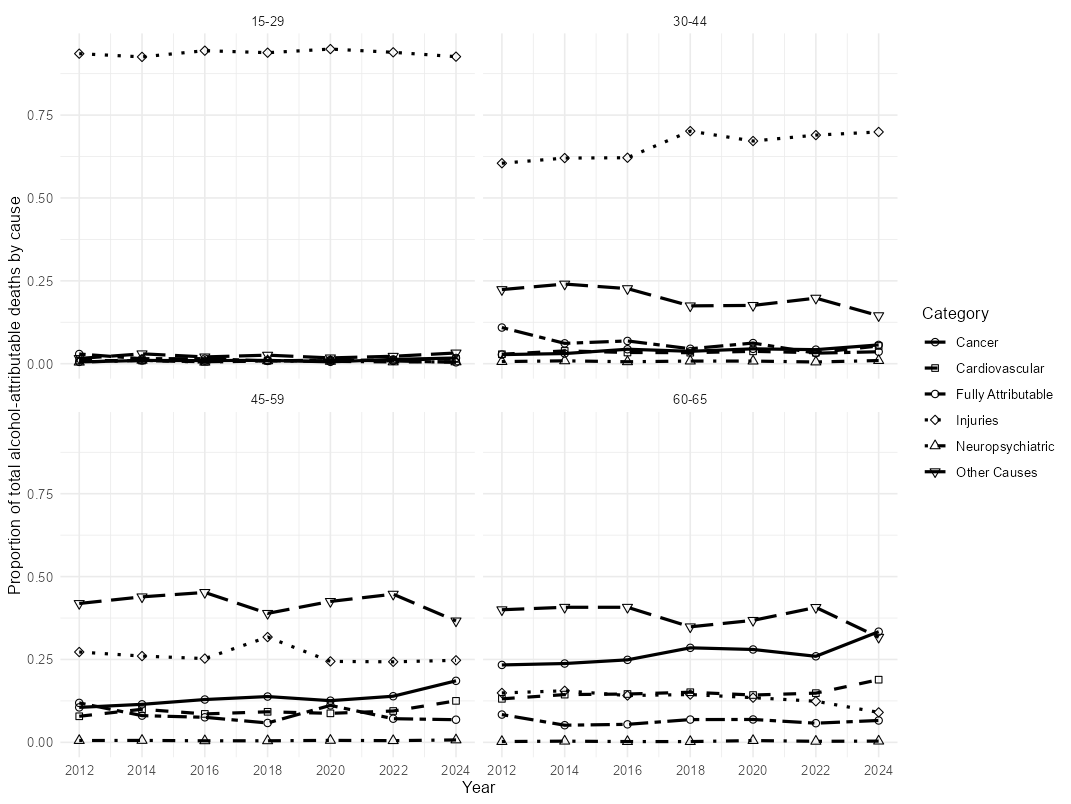

In [50]:
#| label: mort-trends-age-sex-chile20-fig5
#| results: "hold"

mortality_results_cat %>% 
  dplyr::filter(year %% 2 == 0, year >= 2012) %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort= mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x= year, y= prop_mort, linetype= category, shape= category, col = category)) +  # Map shape to category
  geom_line(linewidth= 1, color = "black") +
  geom_point(size= 2, color = "black") +
  scale_x_continuous(
    breaks = c(2012, 2014, 2016, 2018, 2020, 2022, 2024),
    labels = c(2012, 2014, 2016, 2018, 2020, 2022, 2024)
  ) +
  scale_color_manual(
    values = c(
      "Cancer" = "black", 
      "Cardiovascular" = "darkgray", 
      "Injuries" = "gray", 
      "Neuropsychiatric" = "lightgray", 
      "Other Causes" = "dimgray",
      "Fully Attributable" = "red3"
    )
  ) +
  scale_shape_manual(
    values = c(
      "Cancer" = 21,
      "Cardiovascular" = 22,
      "Injuries" = 23,
      "Neuropsychiatric" = 24,
      "Other Causes" = 25,
      "Fully Attributable" = 1
    )
  ) +
  scale_linetype_manual(
    values = c(
      "Cancer" = "solid", 
      "Cardiovascular" = "dashed", 
      "Injuries" = "dotted", 
      "Neuropsychiatric" = "dotdash", 
      "Other Causes" = "longdash",
      "Fully Attributable" = "twodash"
    )
  ) +
  facet_wrap(~ age_group, labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65"))) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"  # Add shape legend title
  ) +
  theme_minimal()

fig4 <- mortality_results_cat %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2012, 2024, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.2, 0.4, 0.6, 0.8),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25,
    "Fully Attributable" = 1
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash",
    "Fully Attributable" = "twodash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )
ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 5.png"
  ),
  plot = fig4,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

[1] "Without pancreatic and stomach cancer, men"


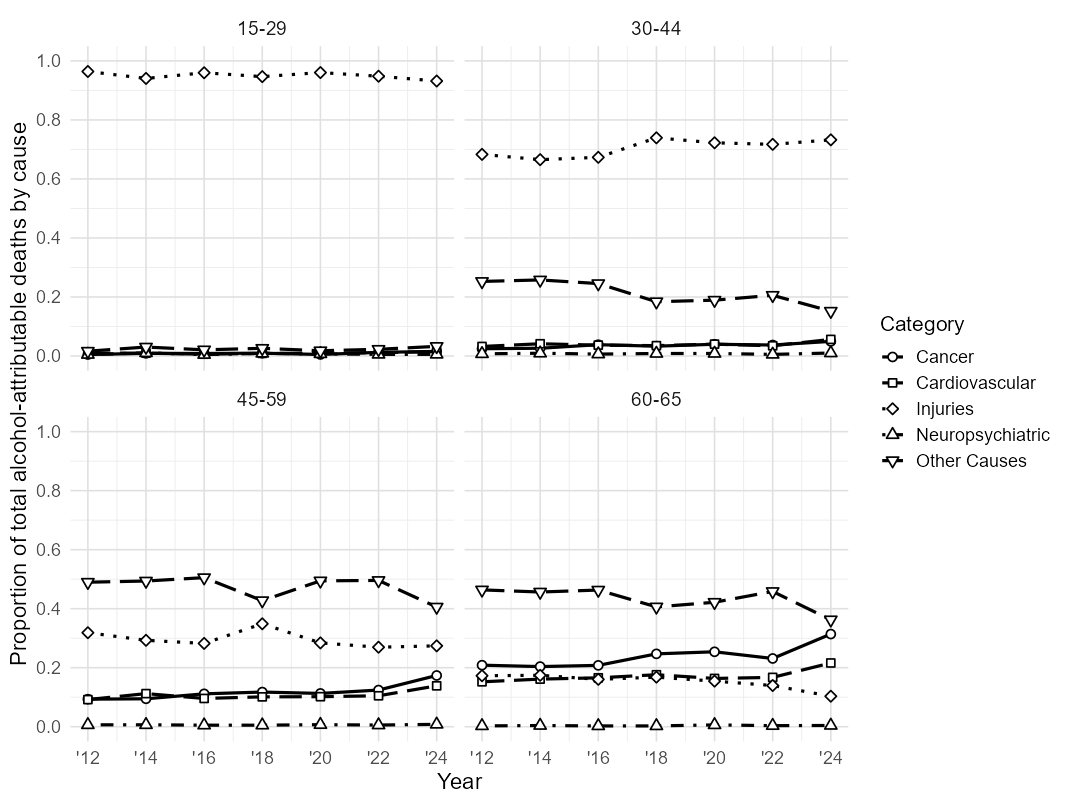

In [51]:
#| label: mort-trends-age-sex-chile20b-fig5
#| results: "hold"

print("Without pancreatic and stomach cancer, men")

mortality_results_cat_not_stomach_pancreas_cancer <- mortality_results %>%
  dplyr::filter(!grepl("Fully", disease)) %>%  # Exclude "Fully attributable to alcohol"
  dplyr::filter(!disease %in% c("Stomach Cancer", "Pancreatic Cancer")) %>%   # <- scope IARC
  dplyr::mutate(category = dplyr::case_when(
    disease %in% c(
      "Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
      "Oral Cavity and Pharynx Cancer", "Other Pharyngeal Cancer",
      "Liver Cancer", "Oesophagus Cancer"
      # Stomach/Pancreatic ya quedaron fuera por el filter de arriba
    ) ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage",
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection",
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    TRUE ~ "Uncategorized"   # red de seguridad
  ))

 mortality_results_cat_not_stomach_pancreas_cancer %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(
  breaks = seq(2012, 2024, 2),
  labels = function(x) paste0("'", substr(as.character(x), 3, 4))
  )+
  scale_y_continuous(
    breaks = c(0, 0.2, 0.4, 0.6, 0.8,1),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 5_not_panc_stomach.png"
  ),
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

#### Figure 4

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


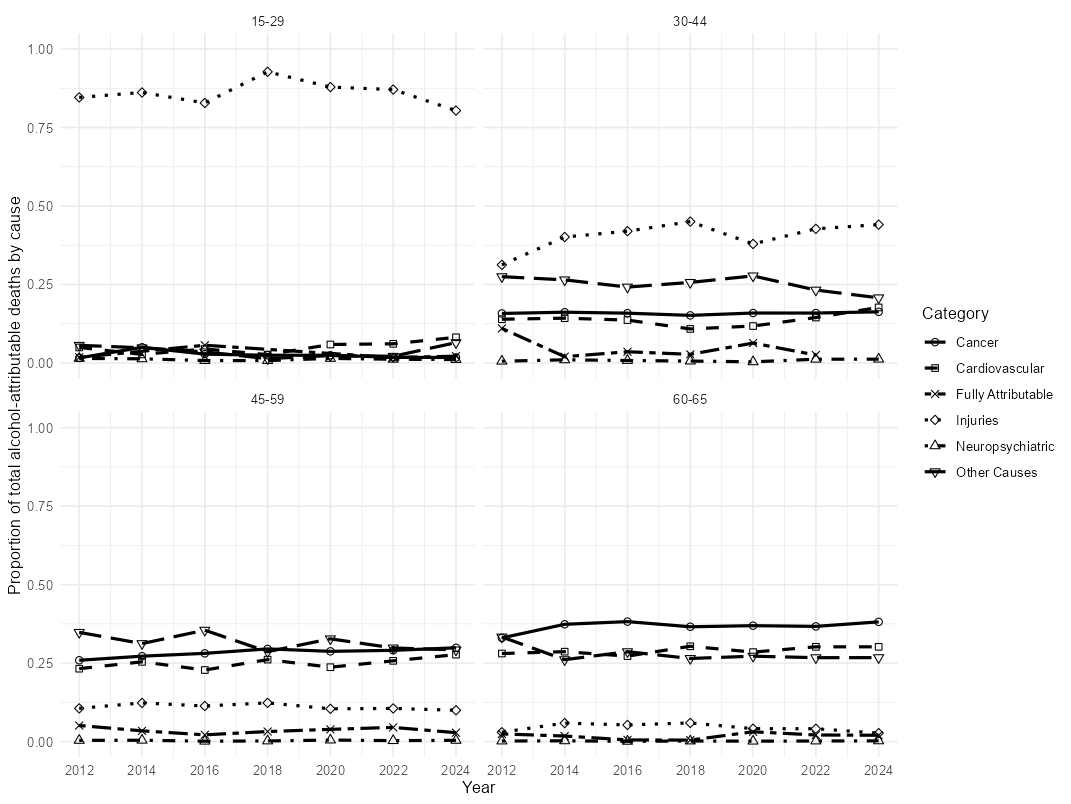

Warning messages:
1: Removed 45 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 45 rows containing missing values or values outside the scale range (`geom_point()`). 


In [52]:
#| label: mort-trends-age-sex-chile21-fig
#| results: "hold"

mortality_results_cat %>%
  dplyr::filter(year %% 2 == 0, year >= 2012) |>
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(size = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = c(2012, 2014, 2016, 2018, 2020, 2022, 2024),
    labels = c(2012, 2014, 2016, 2018, 2020, 2022, 2024)
  ) +
    scale_y_continuous(
    breaks = c(0, 0.25, 0.50, 0.75, 1),
    limits = c(0, 1)
  ) +
    scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25,
    "Fully Attributable" = 4
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "dashed",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash",
    "Fully Attributable" = "twodash"
  )) +
  facet_wrap(~ age_group, labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65"))) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal()

fig5 <- mortality_results_cat %>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2012, 2024, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.25, 0.50, 0.75, 1),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 4.png"
  ),
  plot = fig5,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

[1] "Without pancreatic and stomach cancer, women"


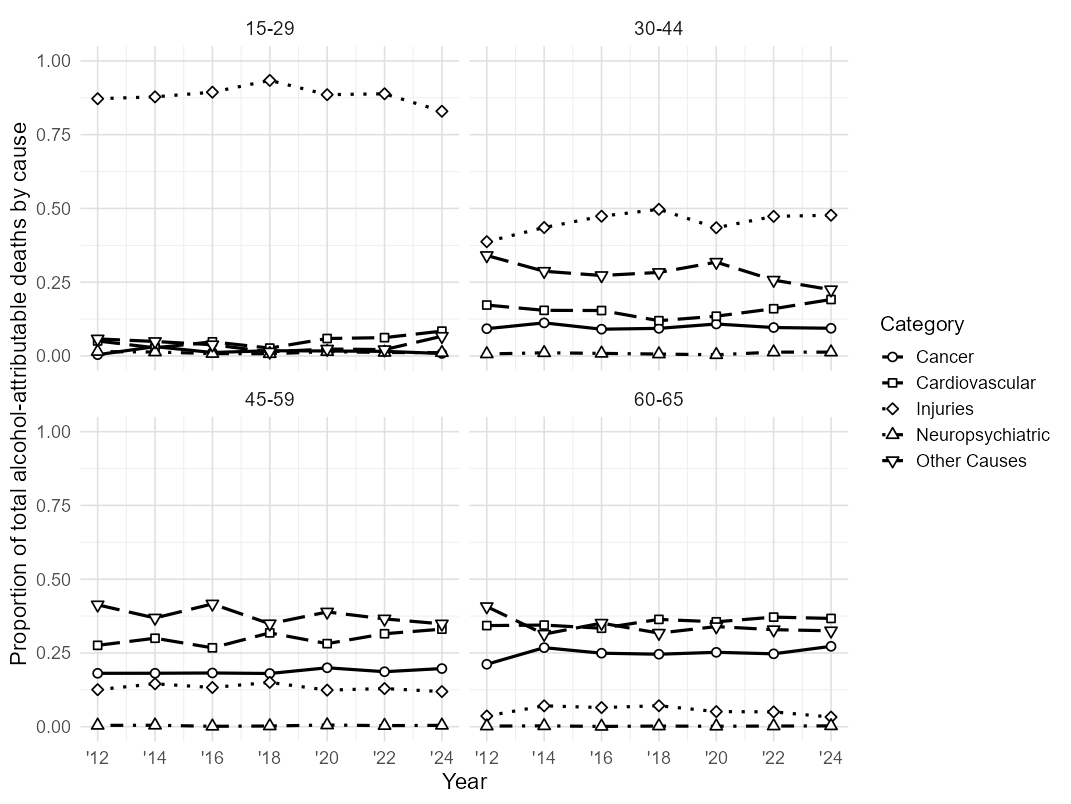

In [53]:
#| label: mort-trends-age-sex-chile21b-fig-fitlered
#| results: "hold"

print("Without pancreatic and stomach cancer, women")

mortality_results_cat_not_stomach_pancreas_cancer%>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(
  breaks = seq(2012, 2024, 2),
  labels = function(x) paste0("'", substr(as.character(x), 3, 4))
  )+
  scale_y_continuous(
    breaks = c(0, 0.25, 0.50, 0.75, 1),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 4_not_pancreas_stomach.png"
  ),
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)


#### Tables

In [54]:
#| label: mort-trends-age-sex-chile22-tab1-women
#| results: "hold"

cols <- c(t(outer(c("mort", "ci"), paste0("20", 6:12*2), paste, sep = "_")))

mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  # Filter for "Mujer"
  filter(gender == "Mujer") |> 
  # Group by year and disease (exclude age_group)
  group_by(year, disease) |> 
  # Summarize values across age groups
  summarise(
    mort = sum(round(mort,0), na.rm = TRUE),
    ci = paste0("[", sum(round(ll_mort,0), na.rm = TRUE), "-", sum(round(up_mort,0), na.rm = TRUE), "]"),
    .groups = "drop"
  ) |> 
  # Pivot years into columns
  pivot_wider(
    names_from = year,
    values_from = c(mort, ci)
  )  |> 
  dplyr::select("disease", all_of(cols)) |> 
  knitr::kable("markdown", caption= "Table, women")



Table: Table, women

|disease                        | mort_2012| mort_2014| mort_2016| mort_2018| mort_2020| mort_2022| mort_2024|ci_2012   |ci_2014   |ci_2016   |ci_2018  |ci_2020   |ci_2022   |ci_2024  |
|:------------------------------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|:---------|:---------|:---------|:--------|:---------|:---------|:--------|
|Acute Pancreatitis             |        11|        11|        14|        13|        12|        15|        15|[4-15]    |[4-16]    |[6-21]    |[6-19]   |[5-19]    |[6-22]    |[7-23]   |
|Breast Cancer                  |        14|        18|        15|        13|        19|        15|        14|[11-17]   |[14-21]   |[11-19]   |[9-14]   |[15-24]   |[12-18]   |[11-18]  |
|Colon and rectum Cancer        |        11|        14|        12|        14|        20|        19|        18|[-16-41]  |[-20-51]  |[-27-52]  |[-37-65] |[-37-78]  |[-41-83]  |[-41-80] |
|DM2                            |         3|   

In [55]:
#| label: mort-trends-age-sex-chile23-tab2-men
#| results: "hold"

 mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  # Filter for "Mujer"
  filter(gender == "Hombre") %>% 
  # Group by year and disease (exclude age_group)
  group_by(year, disease) |> 
  # Summarize values across age groups
  summarise(
    mort = sum(round(mort,0), na.rm = TRUE),
    ci = paste0("[", sum(round(ll_mort,0), na.rm = TRUE), "-", sum(round(up_mort,0), na.rm = TRUE), "]"),
    .groups = "drop"
  ) |> 
  # Pivot years into columns
  pivot_wider(
    names_from = year,
    values_from = c(mort, ci)
  ) |>  
   dplyr::select("disease", all_of(cols)) |>
   knitr::kable("markdown", caption= "Table, men")



Table: Table, men

|disease                        | mort_2012| mort_2014| mort_2016| mort_2018| mort_2020| mort_2022| mort_2024|ci_2012    |ci_2014    |ci_2016    |ci_2018   |ci_2020   |ci_2022    |ci_2024   |
|:------------------------------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|:----------|:----------|:----------|:---------|:---------|:----------|:---------|
|Acute Pancreatitis             |        29|        41|        33|        33|        46|        39|        29|[19-38]    |[27-55]    |[22-42]    |[21-43]   |[30-60]   |[25-50]    |[18-39]   |
|Colon and rectum Cancer        |        90|       121|       136|       145|       171|       211|       230|[78-102]   |[106-136]  |[119-153]  |[128-164] |[151-192] |[188-233]  |[203-256] |
|DM2                            |        25|        20|        23|        19|        26|        34|        30|[-9-62]    |[-7-51]    |[-10-59]   |[-7-46]   |[-10-64]  |[-14-86]   |[-14-74]  |
|Epilepsy          

In [56]:
#| label: mort-trends-age-sex-chile24
#| results: "hold"

# 1. Total attributable deaths by year 
# Suma mort sobre todas las enfermedades, grupos de edad y sexo
# Nota: IHD/IS/DM2 pueden ser negativos. se incluyen (no clipear)

attr_by_year <- mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  )
# 2. Total observed deaths by year (de def, only >= 15 anios) 
total_by_year <- def |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group)) |>          # age >= 15 ya filtrado en chile11
  dplyr::group_by(year) |>
  dplyr::summarise(total_deaths = dplyr::n(), .groups = "drop")

total_by_year_sex <- def |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group)) |>
  dplyr::count(year, gender, name = "total_deaths")
# 3. Burden (%) 
burden <- attr_by_year |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_m <-  mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::filter(gender =="Hombre") |> 
  dplyr::left_join(total_by_year_sex, by = c("year", "gender")) |> 
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_f <-  mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::filter(gender =="Mujer") |> 
  dplyr::left_join(total_by_year_sex, by = c("year", "gender")) |> 
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
# 4. Rate of decline 2012 
b2012 <- burden$burden_pct[burden$year == 2012]
b2024 <- burden$burden_pct[burden$year == 2024]
print(cat(sprintf("2012: %.2f%%\n2024: %.2f%%\nChange: %.1f%%\n",
            b2012, b2024, (b2024 - b2012) / b2012 * 100)))

2012: 12.15%
2024: 9.77%
Change: -19.6%
NULL


In [57]:
#| label: mort-trends-age-sex-chile25
#| results: "hold"

burden |> knitr::kable("markdown", caption= "Burden by year") |>  print()
burden_m|> knitr::kable("markdown", caption= "Burden by year, Male population") |>  print()
burden_f|> knitr::kable("markdown", caption= "Burden by year, Female population") |>  print()



Table: Burden by year

| year| attr_deaths| attr_deaths_ll| attr_deaths_ul| total_deaths| burden_pct| burden_pct_ll| burden_pct_ul|
|----:|-----------:|--------------:|--------------:|------------:|----------:|-------------:|-------------:|
| 2012|    3401.619|       1814.403|       5056.415|        27992|  12.152112|      6.481863|      18.06378|
| 2014|    3465.859|       1819.734|       5151.921|        28821|  12.025463|      6.313917|      17.87558|
| 2016|    3497.385|       1744.748|       5239.071|        28919|  12.093728|      6.033222|      18.11636|
| 2018|    3315.066|       1611.569|       5015.785|        28891|  11.474389|      5.578100|      17.36107|
| 2020|    3673.803|       1959.002|       5387.120|        34271|  10.719860|      5.716209|      15.71918|
| 2022|    3865.428|       1971.166|       5792.503|        34403|  11.235731|      5.729634|      16.83720|
| 2024|    3118.052|       1492.478|       4813.961|        31915|   9.769865|      4.676417|      15.0

In [ ]:
#| label: mort-trends-age-sex-chile26-major-results
#| results: "hold"

# 2026-07-10: "Published paper" values are hand-checked against the final text of
# Ruiz-Tagle Maturana et al. 2026 (Public Health in Practice) plus its 2026-06-28
# corrigendum. The corrigendum only replaced Figs. 1-5 (they were duplicated/mislabeled
# in the original proof); the numbers and text quoted below are unaffected by it.
# The paper's own window is 2008-2022; our pipeline only has reliable data from 2012
# onward and now runs through 2024, so "study start"/"latest" below compare 2008-vs-2012
# and 2022-vs-2024, not the same calendar year -- spelled out in the Aspect labels so
# this is not mistaken for an exact year match.

#Helpers
fmt_pct <- function(x, digits = 2) {
  paste0(formatC(x, format = "f", digits = digits), "%")
}
fmt_change <- function(x) {
  paste0(ifelse(x < 0, "−", ""), formatC(abs(x), format = "f", digits = 1), "%")
}
fmt_ci <- function(x, lo, hi) {
  sprintf("%.2f%% (95%% CI: %.2f–%.2f%%)", x, lo, hi)
}

#:#:#:#:#:#:#:#:
total_by_year <- def |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group)) |>
  dplyr::count(year, name = "total_deaths")
burden <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year) |>
  dplyr::summarise(
    attr_deaths    = sum(mort, na.rm = TRUE),
    attr_deaths_ll = sum(ll_mort, na.rm = TRUE),
    attr_deaths_ul = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
# 2026-07-10 fix: sex-specific denominator (was joining the both-sex total by "year",
# which gave male 7.6% / female 2.2%). Now male deaths / male deaths, etc.
total_by_year_sex <- def |>
  dplyr::filter(year %% 2 == 0, year >= 2012) |>
  dplyr::filter(!is.na(age_group)) |>
  dplyr::count(year, gender, name = "total_deaths")

burden_by_sex <- mortality_results |>
  dplyr::filter(year %% 2 == 0, year >= 2012) |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths    = sum(mort, na.rm = TRUE),
    attr_deaths_ll = sum(ll_mort, na.rm = TRUE),
    attr_deaths_ul = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(total_by_year_sex, by = c("year", "gender")) |>
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
b2012 <- burden |>
  dplyr::filter(year == 2012) |>
  dplyr::slice(1)
b2024 <- burden |>
  dplyr::filter(year == 2024) |>
  dplyr::slice(1)
decline_2012_2024 <-
  (b2024$burden_pct - b2012$burden_pct) / b2012$burden_pct * 100
# Paper's sex-specific burden (12.4% men / 6.4% women) is reported for 2022, its final
# year; matched here to our own final year (2024) rather than 2012, since the paper gives
# no 2012 sex split.
male_2024 <- burden_by_sex |>
  dplyr::filter(year == 2024, gender == "Hombre") |>
  dplyr::pull(burden_pct)
female_2024 <- burden_by_sex |>
  dplyr::filter(year == 2024, gender == "Mujer") |>
  dplyr::pull(burden_pct)
# Renamed ihd_male -> ihd_male_check: `ihd_male` is also the name of a real global AAF
# table built earlier from GENERAL_ihd_RR_2018_03_16.R; a bare `ihd_male <- ...` here would
# silently clobber it for any chunk that runs after this one but before that table is
# rebuilt further down.
ihd_male_check <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(disease == "Ischaemic Heart Disease", gender == "Hombre") |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll   = sum(ll_mort, na.rm = TRUE),
    ul   = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  )
ihd_male_text <- if (
  all(ihd_male_check$mort > 0, na.rm = TRUE) &&
    any(ihd_male_check$ll < 0 & ihd_male_check$ul > 0, na.rm = TRUE)
) {
  "Positive, very wide CI (straddles null)"
} else {
  "Review IHD male estimates"
}
# The paper does not isolate IHD for older men -- it only says "cardiovascular diseases
# and liver cirrhosis" broadly (Discussion). The IHD-specific claim ("increasing trend")
# is made for older WOMEN, so that is the comparison actually supported by the text.
# Same clobber concern as above: named ihd_female_check, not ihd_female.
ihd_female_check <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(disease == "Ischaemic Heart Disease", gender == "Mujer") |>
  dplyr::group_by(year) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE), .groups = "drop") |>
  dplyr::arrange(year)
ihd_female_text <- if (
  all(ihd_female_check$mort > 0, na.rm = TRUE) &&
    dplyr::last(ihd_female_check$mort) > dplyr::first(ihd_female_check$mort)
) {
  "Increasing (matches paper)"
} else {
  "Not increasing in our data"
}
hhd <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(disease == "Hypertensive Heart Disease") |>
  dplyr::group_by(year) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE), .groups = "drop") |>
  dplyr::arrange(year)
hhd_text <- if (
  all(hhd$mort > 0, na.rm = TRUE) &&
    dplyr::last(hhd$mort) > dplyr::first(hhd$mort)
) {
  "Positive and growing"
} else {
  "Review HHD estimates"
}
dominant_cause <- mortality_results |>
  dplyr::group_by(disease) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE), .groups = "drop") |>
  dplyr::slice_max(order_by = mort, n = 1, with_ties = FALSE) |>
  dplyr::pull(disease)
lc_text <- if (dominant_cause == "Liver Cirrhosis") {
  "Yes (unchanged)"
} else {
  paste("No:", dominant_cause)
}
young_male_injuries <- mortality_results |>
  dplyr::filter(
    gender == "Hombre",
    age_group == 1,
    stringr::str_detect(disease, stringr::regex("injur|road", ignore_case = TRUE))
  ) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE)) |>
  dplyr::pull(mort)

injury_text <- if (young_male_injuries > 0) {
  "Yes (unchanged)"
} else {
  "Review injuries in young men"
}
comparison_table <- tibble::tibble(
  Aspect = c(
    "Total burden — study start (2008 paper / 2012 ours)",
    "Total burden — latest (2022 paper / 2024 ours)",
    "Rate of decline (2008→2022 paper / 2012→2024 ours)",
    "Male burden — latest (2022 paper / 2024 ours)",
    "Female burden — latest (2022 paper / 2024 ours)",
    "IHD, men (paper has no men-specific IHD claim)",
    "IHD trend, older women",
    "HHD",
    "Liver cirrhosis dominance",
    "Injuries in young men"
  ),
  `Published paper` = c(
    "14.6% (95% CI: 10.9–18.4%)",
    "9.6% (95% CI: 7.2–12.2%)",
    "−34%",
    "12.4%",
    "6.4%",
    "Not isolated (CVD broad + liver cirrhosis, older men)",
    "Increasing trend",
    "Not highlighted",
    "Yes, but age-specific (leads 30–59; co-leads w/ CVD in 60+ men)",
    "Yes (leading cause throughout)"
  ),
  `Recent analysis` = c(
    fmt_ci(b2012$burden_pct, b2012$burden_pct_ll, b2012$burden_pct_ul),
    fmt_ci(b2024$burden_pct, b2024$burden_pct_ll, b2024$burden_pct_ul),
    fmt_change(decline_2012_2024),
    fmt_pct(male_2024),
    fmt_pct(female_2024),
    ihd_male_text,
    ihd_female_text,
    hhd_text,
    lc_text,
    injury_text
  )
)
comparison_table |>
  knitr::kable("markdown")



|Aspect                                              |Published paper                                                 |Recent analysis              |
|:---------------------------------------------------|:---------------------------------------------------------------|:----------------------------|
|Total burden — study start (2008 paper / 2012 ours) |14.6% (95% CI: 10.9–18.4%)                                      |12.15% (95% CI: 6.48–18.06%) |
|Total burden — latest (2022 paper / 2024 ours)      |9.6% (95% CI: 7.2–12.2%)                                        |9.77% (95% CI: 4.68–15.08%)  |
|Rate of decline (2008→2022 paper / 2012→2024 ours)  |−34%                                                            |−19.6%                       |
|Male burden — latest (2022 paper / 2024 ours)       |12.4%                                                           |7.60%                        |
|Female burden — latest (2022 paper / 2024 ours)     |6.4%                                        

In [69]:
#| label: mort-trends-age-sex-chile27-major-results2
#| results: "hold"

# 2026-07-10: "Published paper" values are hand-checked against the final text of
# Ruiz-Tagle Maturana et al. 2026 (Public Health in Practice) plus its 2026-06-28
# corrigendum. The corrigendum only replaced Figs. 1-5 (they were duplicated/mislabeled
# in the original proof); the numbers and text quoted below are unaffected by it.
# The paper's own window is 2008-2022; our pipeline only has reliable data from 2012
# onward and now runs through 2024, so every "2012" row below is really paper-2008-vs-
# ours-2012, and every "2024" row is paper-2022-vs-ours-2024 -- spelled out in the Aspect
# labels so this is not mistaken for an exact year match. "Lowest total mortality rate"
# (2012) and "Post-2012 peak" (2018) are the two rows where paper and pipeline years
# genuinely coincide, so those keep their original labels.

fmt_pct <- function(x, digits = 1) {
  paste0(formatC(x, format = "f", digits = digits), "%")
}
fmt_pct_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f%% (95%% CI: %.", digits, "f\u{2013}%.", digits, "f%%)"),
    x, lo, hi
  )
}
fmt_rate_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f per 100,000 (95%% CI: %.", digits, "f\u{2013}%.", digits, "f)"),
    x, lo, hi
  )
}
fmt_change <- function(x, digits = 1) {
  paste0(
    ifelse(x < 0, "\u{2212}", ""),
    formatC(abs(x), format = "f", digits = digits),
    "%"
  )
}

def_analysis <- def |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group))
deaths_total <- def_analysis |>
  dplyr::count(year, name = "n")
deaths_sex <- def_analysis |>
  dplyr::count(year, gender, name = "n")

burden_total <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_total, by = "year") |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )
burden_sex <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_sex, by = c("year", "gender")) |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )
total_2012 <- burden_total |> dplyr::filter(year == 2012)
total_2024 <- burden_total |> dplyr::filter(year == 2024)
male_2024 <- burden_sex |> dplyr::filter(year == 2024, gender == "Hombre")
female_2024 <- burden_sex |> dplyr::filter(year == 2024, gender == "Mujer")
decline_total <- (total_2024$prop - total_2012$prop) / total_2012$prop * 100
lowest_total_rate <- std_rates |>
  dplyr::filter(gender == "Total") |>
  dplyr::slice_min(order_by = std_mort_rate, n = 1, with_ties = FALSE)
post_2012_peak_total_rate <- std_rates |>
  dplyr::filter(gender == "Total", year > 2012) |>
  dplyr::slice_max(order_by = std_mort_rate, n = 1, with_ties = FALSE)
total_rate_2024 <- std_rates |> dplyr::filter(year == 2024, gender == "Total")
male_rate_2024 <- std_rates |> dplyr::filter(year == 2024, gender == "Male")
female_rate_2024 <- std_rates |> dplyr::filter(year == 2024, gender == "Female")

extended_comparison <- tibble::tibble(
  Aspect = c(
    "Total burden \u2014 study start (2008 paper / 2012 ours)",
    "Total burden \u2014 latest (2022 paper / 2024 ours)",
    "Rate of decline (2008\u{2192}2022 paper / 2012\u{2192}2024 ours)",
    "Lowest total mortality rate",
    "Post-2012 peak total mortality rate",
    "Total mortality rate \u2014 latest (2022 paper / 2024 ours)",
    "Male burden \u2014 latest (2022 paper / 2024 ours)",
    "Female burden \u2014 latest (2022 paper / 2024 ours)",
    "Male mortality rate \u2014 latest (2022 paper / 2024 ours)",
    "Female mortality rate \u2014 latest (2022 paper / 2024 ours)"
  ),
  `Published paper` = c(
    "14.6% (95% CI: 10.9-18.4%)",
    "9.6% (95% CI: 7.2-12.2%)",
    "\u{2212}34%",
    "2012: 62 per 100,000",
    "2018 peak",
    "65.4 per 100,000",
    "12.4%",
    "6.4%",
    "84.4 per 100,000",
    "38.4 per 100,000"
  ),
  `Recent analysis` = c(
    fmt_pct_ci(total_2012$prop, total_2012$ll_prop, total_2012$up_prop),
    fmt_pct_ci(total_2024$prop, total_2024$ll_prop, total_2024$up_prop),
    fmt_change(decline_total),
    paste0(lowest_total_rate$year, ": ", fmt_rate_ci(
      lowest_total_rate$std_mort_rate,
      lowest_total_rate$ll_std_mort_rate,
      lowest_total_rate$up_std_mort_rate
    )),
    paste0(post_2012_peak_total_rate$year, ": ", fmt_rate_ci(
      post_2012_peak_total_rate$std_mort_rate,
      post_2012_peak_total_rate$ll_std_mort_rate,
      post_2012_peak_total_rate$up_std_mort_rate
    )),
    fmt_rate_ci(
      total_rate_2024$std_mort_rate,
      total_rate_2024$ll_std_mort_rate,
      total_rate_2024$up_std_mort_rate
    ),
    fmt_pct_ci(male_2024$prop, male_2024$ll_prop, male_2024$up_prop),
    fmt_pct_ci(female_2024$prop, female_2024$ll_prop, female_2024$up_prop),
    fmt_rate_ci(
      male_rate_2024$std_mort_rate,
      male_rate_2024$ll_std_mort_rate,
      male_rate_2024$up_std_mort_rate
    ),
    fmt_rate_ci(
      female_rate_2024$std_mort_rate,
      female_rate_2024$ll_std_mort_rate,
      female_rate_2024$up_std_mort_rate
    )
  )
)
extended_comparison |>
  knitr::kable("markdown")



|Aspect                                                  |Published paper            |Recent analysis                            |
|:-------------------------------------------------------|:--------------------------|:------------------------------------------|
|Total burden — study start (2008 paper / 2012 ours)     |14.6% (95% CI: 10.9-18.4%) |12.2% (95% CI: 6.5–18.1%)                  |
|Total burden — latest (2022 paper / 2024 ours)          |9.6% (95% CI: 7.2-12.2%)   |9.8% (95% CI: 4.7–15.1%)                   |
|Rate of decline (2008→2022 paper / 2012→2024 ours)      |−34%                       |−19.6%                                     |
|Lowest total mortality rate                             |2012: 62 per 100,000       |2023: 1.0 per 100,000 (95% CI: 1.0–1.0)    |
|Post-2012 peak total mortality rate                     |2018 peak                  |2014: 28.7 per 100,000 (95% CI: 15.0–42.6) |
|Total mortality rate — latest (2022 paper / 2024 ours)  |65.4 per 100,000       

In [ ]:
#| label: mort-trends-age-sex-chile27b-major-results2-who-scope
#| results: "hold"
mortality_results_who_scope <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!disease %in% c("Stomach Cancer", "Pancreatic Cancer"))

burden_total_who_scope <- mortality_results_who_scope |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_total, by = "year") |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )
burden_sex_who_scope <- mortality_results_who_scope |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_sex, by = c("year", "gender")) |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )

std_rates_who_scope <- dplyr::bind_rows(
  make_std_rate(mortality_results_who_scope, spw_tot, "Total"),
  make_std_rate(
    mortality_results_who_scope |> dplyr::filter(gender == "Hombre"),
    spw_male,
    "Hombre"
  ),
  make_std_rate(
    mortality_results_who_scope |> dplyr::filter(gender == "Mujer"),
    spw_fem,
    "Mujer"
  )
)

fmt_rate_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f (95%% CI: %.", digits, "f, %.", digits, "f)"),
    x, lo, hi
  )
}
fmt_pct_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f (95%% CI: %.", digits, "f, %.", digits, "f)"),
    x, lo, hi
  )
}

print(paste0("std. mortality rate w/o stomach & pancreatic cancer: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2024 & std_rates_who_scope$gender=="Total"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("std. mortality rate w/o stomach & pancreatic cancer, men: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2024 & std_rates_who_scope$gender=="Hombre"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("std. mortality rate w/o stomach & pancreatic cancer, women: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2024 & std_rates_who_scope$gender=="Mujer"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer: ", 
with(burden_total_who_scope[which(burden_total_who_scope$year==2024),], 
fmt_pct_ci(prop, ll_prop, up_prop))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer, men: ", 
with(burden_sex_who_scope[which(burden_sex_who_scope$year==2024 & burden_sex_who_scope$gender=="Hombre"),], 
fmt_pct_ci(prop, ll_prop, up_prop))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer, women: ", 
with(burden_sex_who_scope[which(burden_sex_who_scope$year==2024 & burden_sex_who_scope$gender=="Mujer"),], 
fmt_pct_ci(prop, ll_prop, up_prop))))


[1] "std. mortality rate w/o stomach & pancreatic cancer: 20.6 (95% CI: 9.7, 32.0)"
[1] "std. mortality rate w/o stomach & pancreatic cancer, men: 33.4 (95% CI: 17.2, 50.5)"
[1] "std. mortality rate w/o stomach & pancreatic cancer, women: 8.2 (95% CI: 2.5, 14.0)"
[1] "alcohol burden w/o stomach & pancreatic cancer: 9.3 (95% CI: 4.4, 14.4)"
[1] "alcohol burden w/o stomach & pancreatic cancer, men: 11.6 (95% CI: 6.0, 17.6)"
[1] "alcohol burden w/o stomach & pancreatic cancer, women: 5.2 (95% CI: 1.6, 8.9)"


# Session info

In [62]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", getwd()))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: C:\Users\nDP\AppData\Local/R/win-library/4.4
Date: 2026-07-10 17:37:49.589046
Editor context: c:/Users/nDP/Desktop/ACC1240138_private/__andres_control
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/nDP/AppData/Local/Temp/RtmpGuJP5Z/file196c2dd76020 -V' had status 1


1,bit,4.6.0,CRAN (R 4.4.3)
2,bit64,4.6.0-1,CRAN (R 4.4.3)
3,bslib,0.10.0,CRAN (R 4.4.3)
4,cachem,1.1.0,CRAN (R 4.4.3)
5,cellranger,1.1.0,CRAN (R 4.4.3)
6,cli,3.6.5,CRAN (R 4.4.3)
7,crayon,1.5.3,CRAN (R 4.4.3)
8,crosstalk,1.2.2,CRAN (R 4.4.3)
9,DBI,1.3.0,CRAN (R 4.4.3)
10,devtools,2.5.0,CRAN (R 4.4.3)
11,digest,0.6.39,CRAN (R 4.4.3)


## References

::: {#refs}
:::

# Appendix: Table 5 IHD/IS AAF experiment

 Purpose:
- Re-run the unified cardiovascular AAF engine for Ischaemic Heart Disease (IHD)
- and Ischaemic Stroke (IS), changing only the current-drinker RR curves:
- use the Chile 2014 Table 5 sex-specific RR parameters instead of the
- age-banded `GENERAL_ihd_RR_2018_03_16.R` / `GENERAL_IS_RR_2018_03_16.R` records.

In [63]:
#| label: id-is-rr
#| echo: true

# Hard-coded Table 5 RR coefficients and former-drinker RRs.
table5_rr_parameters <- data.frame(
    family = c("ihd", "ihd", "is", "is"),
    disease = c(
      "Ischaemic Heart Disease", "Ischaemic Heart Disease",
      "Ischaemic Stroke", "Ischaemic Stroke"
    ),
    sex = c("male", "female", "male", "female"),
    source_object = c(
      "table5_ihd_male", "table5_ihd_female",
      "table5_is_male", "table5_is_female"
    ),
    b1 = c(-0.046271, -0.052526, -0.141950, -0.249674),
    se_b1 = c(0.024037, 0.032510, 0.012866, 0.019163),
    b2 = c(0.000001, 0.014704, 0.039613, 0.037207),
    se_b2 = c(0.000000, 0.007925, 0.001782, 0.000523),
    fact = c(1 / 3, 1 / 20, 1, 1),
    rr_former = c(1.25, 1.54, 0.97, 0.97),
    rr_former_lower = c(1.15, 1.17, 0.83, 0.83),
    rr_former_upper = c(1.36, 2.03, 1.14, 1.14),
    stringsAsFactors = FALSE
  )
table5_rr_parameters|> 
    knitr::kable("markdown", caption="IHD/IS by sex (from Table 5, PUC's study")



Table: IHD/IS by sex (from Table 5, PUC's study

|family |disease                 |sex    |source_object     |        b1|    se_b1|       b2|    se_b2|      fact| rr_former| rr_former_lower| rr_former_upper|
|:------|:-----------------------|:------|:-----------------|---------:|--------:|--------:|--------:|---------:|---------:|---------------:|---------------:|
|ihd    |Ischaemic Heart Disease |male   |table5_ihd_male   | -0.046271| 0.024037| 0.000001| 0.000000| 0.3333333|      1.25|            1.15|            1.36|
|ihd    |Ischaemic Heart Disease |female |table5_ihd_female | -0.052526| 0.032510| 0.014704| 0.007925| 0.0500000|      1.54|            1.17|            2.03|
|is     |Ischaemic Stroke        |male   |table5_is_male    | -0.141950| 0.012866| 0.039613| 0.001782| 1.0000000|      0.97|            0.83|            1.14|
|is     |Ischaemic Stroke        |female |table5_is_female  | -0.249674| 0.019163| 0.037207| 0.000523| 1.0000000|      0.97|            0.83|            1

In [64]:
#| label: table5-ihd-is-aaf-step2-same-engine
#| results: "hold"

# Start execution timer for this chunk
.t0 <- Sys.time()
# This block uses the live notebook objects from step2.
# It does not read aaf_engine_inputs_bundle_*.rds or aaf_nested_by_disease_*.rds.
# Small helper to extract named list elements with a fallback default value
table5_get <- function(x, nm, default = NULL) {
  if (!is.null(x[[nm]])) x[[nm]] else default
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Approximate log-normal variance from a 95% confidence interval.
table5_lognormal_var_from_ci <- function(lower, upper) {
  ((log(upper) - log(lower)) / (2 * stats::qnorm(0.975)))^2
}
# Table 5 current-drinker RR curve for IHD in males.
table5_rr_ihd_male <- function(x, beta) {
  # Table 5: ln(RR) = B1 * x^0.5 + B2 * x^3.
  exp(beta[[1L]] * sqrt(x) + beta[[2L]] * x^3)
}
# Table 5 current-drinker RR curve for IHD in females.
table5_rr_ihd_female <- function(x, beta) {
  # Table 5: ln(RR) = B1 * x + B2 * x * ln(x).
  exp(beta[[1L]] * x + beta[[2L]] * x * log(x))
}
# Table 5 current-drinker RR curve for ischaemic stroke in males.
table5_rr_is_male <- function(x, beta) {
  # Table 5: ln(RR) = B1 * x^0.5 + B2 * x^0.5 * ln(x).
  exp(beta[[1L]] * sqrt(x) + beta[[2L]] * sqrt(x) * log(x))
}
# Table 5 current-drinker RR curve for ischaemic stroke in females.
table5_rr_is_female <- function(x, beta) {
  # Table 5: ln(RR) = B1 * x^0.5 + B2 * x.
  exp(beta[[1L]] * sqrt(x) + beta[[2L]] * x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Build a single registry record compatible with aaf_unified.R.
table5_make_record <- function(row, age_band) {
  rr_fun <- switch(
    paste(row$family, row$sex, sep = "_"),
    ihd_male = table5_rr_ihd_male,
    ihd_female = table5_rr_ihd_female,
    is_male = table5_rr_is_male,
    is_female = table5_rr_is_female,
    stop("Unsupported Table 5 RR row: ", row$family, " / ", row$sex)
  )
  list(
    disease = row$disease,
    pipeline_disease = row$disease,
    rr_endpoint = row$disease,
    source_note = paste(
      "Chile 2014 Table 5 sex-specific RR sensitivity;",
      "same RR repeated across age bands because Table 5 is not age-banded.",
      "The 'fact' column is stored as metadata and is not used as a hidden x-scale."
    ),
    pipeline_icd10 = if (identical(row$family, "ihd")) "I20-I25" else "G45-G46.8/I63/I65-I66/I67.2-I67.8/I69.3-I69.4",
    sex = row$sex,
    source_file = "expand_pif.ipynb::table5-ihd-is-aaf-step2-same-engine",
    source_object = paste0(row$source_object, "_", gsub("[^0-9A-Za-z]+", "_", age_band)),
    adam_age_band = age_band,
    RRCurrent = rr_fun,
    betaCurrent = c(row$b1, row$b2),
    covBetaCurrent = diag(c(row$se_b1^2, row$se_b2^2), 2L),
    lnRRFormer = log(row$rr_former),
    varLnRRFormer = table5_lognormal_var_from_ci(row$rr_former_lower, row$rr_former_upper),
    table5_fact = row$fact,
    table5_rr_former_ci = c(row$rr_former_lower, row$rr_former_upper)
  )
}
# Build an adam_rr_registry object for IHD or IS.
table5_make_registry <- function(family = c("ihd", "is")) {
  family <- match.arg(family)
  pars <- if (is.function(table5_rr_parameters)) {
    table5_rr_parameters()
  } else {
    table5_rr_parameters
  }
  pars <- pars[pars$family == family, , drop = FALSE]
  age_bands <- c("15-34", "35-64", "65+")
  records <- list()
  for (i in seq_len(nrow(pars))) {
    for (band in age_bands) {
      rec <- table5_make_record(pars[i, , drop = FALSE], band)
      records[[paste(rec$sex, rec$source_object, sep = "::")]] <- rec
    }
  }
  class(records) <- c("adam_rr_registry", "list")
  attr(records, "summary") <- table5_registry_summary(records)
  records
}
# Return a concise summary data.frame of the registry.
table5_registry_summary <- function(registry) {
  do.call(rbind, lapply(registry, function(record) {
    data.frame(
      source_object = record$source_object,
      sex = record$sex,
      pipeline_disease = record$pipeline_disease,
      adam_age_band = record$adam_age_band,
      n_betas = length(record$betaCurrent),
      rr_former = exp(record$lnRRFormer),
      table5_fact = record$table5_fact,
      stringsAsFactors = FALSE
    )
  }))
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Return a verbose metadata data.frame of the registry.
table5_registry_metadata <- function(registry) {
  do.call(rbind, lapply(registry, function(record) {
    data.frame(
      disease = record$disease,
      pipeline_disease = record$pipeline_disease,
      rr_endpoint = record$rr_endpoint,
      source_note = record$source_note,
      pipeline_icd10 = record$pipeline_icd10,
      sex = record$sex,
      adam_age_band = record$adam_age_band,
      source_file = record$source_file,
      source_object = record$source_object,
      betaCurrent = paste(format(record$betaCurrent), collapse = "; "),
      covBetaCurrent = paste(format(as.vector(record$covBetaCurrent)), collapse = "; "),
      lnRRFormer = record$lnRRFormer,
      rr_form_used = exp(record$lnRRFormer),
      varLnRRFormer_recorded = record$varLnRRFormer,
      table5_fact = record$table5_fact,
      table5_rr_former_ci = paste(format(record$table5_rr_former_ci), collapse = "; "),
      stringsAsFactors = FALSE
    )
  }))
}
# Convert wide AAF output to the project's standard 4 age-group format.
table5_wide_to_standard <- function(df, prefix) {
  out <- data.frame(
    Year = df$Year,
    disease = df$disease,
    stringsAsFactors = FALSE
  )
  for (ag in 1:4) {
    out[[paste0("AAF_ag", ag)]] <- df[[paste0(prefix, ag, "_point")]]
    out[[paste0("LL_ag", ag)]] <- df[[paste0(prefix, ag, "_lower")]]
    out[[paste0("UL_ag", ag)]] <- df[[paste0(prefix, ag, "_upper")]]
  }
  out
}
# Stack female and male standard tables into long format.
table5_standard_to_long <- function(female, male) {
  rows <- list()
  i <- 1L
  add_rows <- function(df, gender) {
    for (r in seq_len(nrow(df))) {
      for (ag in 1:4) {
        rows[[i]] <<- data.frame(
          year = df$Year[[r]],
          age_group = ag,
          gender = gender,
          disease = df$disease[[r]],
          point = df[[paste0("AAF_ag", ag)]][[r]],
          lower = df[[paste0("LL_ag", ag)]][[r]],
          upper = df[[paste0("UL_ag", ag)]][[r]],
          stringsAsFactors = FALSE
        )
        i <<- i + 1L
      }
    }
    invisible(NULL)
  }
  add_rows(female, "Mujer")
  add_rows(male, "Hombre")
  do.call(rbind, rows)
}
# Combine IHD and IS results into female/male/long tables.
table5_cv_standard_tables <- function(ihd_result, is_result) {
  female <- rbind(
    table5_wide_to_standard(ihd_result$tables$ihd_female, "Fem"),
    table5_wide_to_standard(is_result$tables$is_female, "Fem")
  )
  male <- rbind(
    table5_wide_to_standard(ihd_result$tables$ihd_male, "Male"),
    table5_wide_to_standard(is_result$tables$is_male, "Male")
  )
  list(
    female = female,
    male = male,
    long = table5_standard_to_long(female, male)
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Locate the validated AAF engine directory and its unified R source file
# Locate the __andres_control directory from the working directory.
table5_find_control_dir <- function() {
  candidates <- unique(c(
    normalizePath(".", winslash = "/", mustWork = FALSE),
    normalizePath(file.path(".", "__andres_control"), winslash = "/", mustWork = FALSE),
    normalizePath(file.path("..", "__andres_control"), winslash = "/", mustWork = FALSE)
  ))
  hits <- candidates[file.exists(file.path(candidates, "aaf_unified.R"))]
  if (!length(hits)) {
    stop("Could not find __andres_control/aaf_unified.R from getwd(): ", getwd())
  }
  normalizePath(hits[[1L]], winslash = "/", mustWork = TRUE)
}
table5_control_dir <- if (exists("adam_control_dir")) adam_control_dir else table5_find_control_dir()
table5_engine_file <- file.path(table5_control_dir, "aaf_unified.R")
# Load the engine functions only if they are not already available in the global environment
if (!exists("run_aaf_cells_parallel") || !exists("compute_cv_aaf_from_registry")) {
  source(table5_engine_file)
}
# Define all objects that must already exist before running the Table 5 AAF sensitivity
required_objects <- c(
  "run_aaf_cells_parallel", "compute_cv_aaf_from_registry",
  "table5_rr_parameters",
  "aaf_mc", "aaf_uncertainty", "adam_years_vec",
  "g_fem_hed_list", "g_male_hed_list",
  "p_abs_list_fem", "p_abs_list_male",
  "p_form_list_fem", "p_form_list_male",
  "p_hed_list_fem", "p_hed_list_male",
  "x_vals"
)
# Check which required objects are missing from the global environment
missing_objects <- required_objects[
  !vapply(required_objects, exists, logical(1), envir = .GlobalEnv, inherits = TRUE)
]
# Stop early with an informative message if dependencies are missing
if (length(missing_objects) > 0) {
  stop("Missing required object(s): ", paste(missing_objects, collapse = ", "))
}
# Determine the number of parallel workers, defaulting to one less than available cores
table5_n_cores <- if (is.null(aaf_mc$n_cores)) {
  min(12L, max(1L, parallel::detectCores(logical = TRUE) - 1L))
} else {
  as.integer(aaf_mc$n_cores)
}
# Same uncertainty contract as step2:
# common_args <- c(aaf_mc, aaf_uncertainty, list(...)).
# The consumption knobs are passed explicitly, so neff_consumption is used when present.
# Build the argument list shared by both IHD and IS AAF computations
table5_cv_common_args <- c(
  list(
    n_sim = as.integer(aaf_mc$n_sim),
    n_pca = as.integer(aaf_mc$n_pca),
    seed = as.integer(aaf_mc$seed),
    n_cores = table5_n_cores
  ),
  list(
    prev_method = table5_get(aaf_uncertainty, "prev_method", "dirichlet"),
    neff = table5_get(aaf_uncertainty, "neff", 1000),
    design_factor = table5_get(aaf_uncertainty, "design_factor", 1.35),
    fd_uncertainty = isTRUE(table5_get(aaf_uncertainty, "fd_uncertainty", TRUE)),
    neff_consumption = table5_get(aaf_uncertainty, "neff_consumption", NULL),
    design_factor_consumption = table5_get(aaf_uncertainty, "design_factor_consumption", 1)
  ),
  list(
    years = adam_years_vec,
    use_parallel = TRUE,
    stop_on_error = FALSE
  )
)
# Package the heavy-episodic-drinking input lists for females and males
table5_cv_hed_inputs <- list(
  g_fem_hed_list = g_fem_hed_list,
  g_male_hed_list = g_male_hed_list,
  p_abs_list_fem = p_abs_list_fem,
  p_abs_list_male = p_abs_list_male,
  p_form_list_fem = p_form_list_fem,
  p_form_list_male = p_form_list_male,
  p_hed_list_fem = p_hed_list_fem,
  p_hed_list_male = p_hed_list_male
)
# Create the disease-specific Table 5 RR registries for IHD and ischaemic stroke
table5_ihd_registry <- table5_make_registry("ihd")
table5_is_registry <- table5_make_registry("is")
# Inform the user about the parallel setup and the use of live configuration objects
message(sprintf("Using %d AAF workers for the Table 5 IHD/IS sensitivity.", table5_n_cores))
message("Table 5 AAF uses live aaf_mc and live aaf_uncertainty from step2.")
# Internal wrapper that computes AAFs for both diseases using the common engine
run_table5_families <- function() {
  # Compute Table 5 IHD AAFs for the 15-64 age scope
  table5_ihd_aaf <<- do.call(
    compute_cv_aaf_from_registry,
    c(
      table5_cv_common_args,
      table5_cv_hed_inputs,
      list(registry = table5_ihd_registry, x_vals = x_vals, age_scope = "15_64")
    )
  )
  # Compute Table 5 ischaemic stroke AAFs for the 15-64 age scope
  table5_is_aaf <<- do.call(
    compute_cv_aaf_from_registry,
    c(
      table5_cv_common_args,
      table5_cv_hed_inputs,
      list(registry = table5_is_registry, x_vals = x_vals, age_scope = "15_64")
    )
  )
  invisible(NULL)
}
# Execute the Table 5 AAF computations through the validated parallel wrapper
run_aaf_cells_parallel(
  run_table5_families,
  engine_file = table5_engine_file,
  n_cores = table5_n_cores
)
# Use list2env, but avoid overwriting the main Adam/WHO pipeline tables.
# Combine raw tables from both diseases
table5_cv_tables <- c(table5_ihd_aaf$tables, table5_is_aaf$tables)
# Prefix exported table names so Adam/WHO objects are not overwritten
table5_cv_tables_prefixed <- stats::setNames(
  table5_cv_tables,
  paste0(names(table5_cv_tables), "_table5")
)
# Export the prefixed Table 5 tables into the global environment
base::list2env(table5_cv_tables_prefixed, envir = .GlobalEnv)
# Combine audit trails and error logs from both disease computations
aaf_table5_rr_audit <- dplyr::bind_rows(
  table5_ihd_aaf$audit,
  table5_is_aaf$audit
)
aaf_table5_rr_errors <- dplyr::bind_rows(
  table5_ihd_aaf$errors,
  table5_is_aaf$errors
)
# Build the standard long/wide Table 5 AAF tables for the 15-64 age scope
table5_standard_15_64 <- table5_cv_standard_tables(table5_ihd_aaf, table5_is_aaf)
# Assemble the final structured result object for the Table 5 IHD/IS experiment
aaf_table5_result <- list(
  metadata = list(
    created_at = format(Sys.time(), "%Y-%m-%d %H:%M:%S %z"),
    source_chunk = "table5-ihd-is-aaf-step2-same-engine",
    engine_file = table5_engine_file,
    note = paste(
      "Uses the same step2 motor: run_aaf_cells_parallel() plus compute_cv_aaf_from_registry().",
      "Uses live aaf_mc and live aaf_uncertainty, including neff_consumption/design_factor_consumption when present.",
      "Exports prefixed tables only, so Adam/WHO IHD/IS tables are not overwritten."
    )
  ),
  config = list(
    aaf_mc = aaf_mc,
    aaf_uncertainty = aaf_uncertainty,
    n_cores = table5_n_cores,
    age_scope = "15_64"
  ),
  registries = list(
    ihd = table5_registry_metadata(table5_ihd_registry),
    ischaemic_stroke = table5_registry_metadata(table5_is_registry)
  ),
  raw = list(
    ihd = table5_ihd_aaf,
    ischaemic_stroke = table5_is_aaf
  ),
  by_age_scope = list(
    "15_64" = list(
      age_scope = "15_64",
      standard_tables = table5_standard_15_64,
      errors = aaf_table5_rr_errors
    ),
    "15_plus" = list(
      age_scope = "15_plus",
      note = "Alias of 15_64 AAFs; Table 5 RR is sex-specific, not age-banded.",
      standard_tables = table5_standard_15_64,
      errors = aaf_table5_rr_errors
    )
  )
)
# Validation helper: check a single Table 5 AAF table for NAs, AAF > 1, and CI ordering
table5_validate_aaf_table <- function(df, label) {
  value_cols <- setdiff(names(df), c("Year", "disease"))
  if (anyNA(df[value_cols])) stop("Unexpected NA in Table 5 AAF table: ", label)
  for (point_col in grep("_point$", value_cols, value = TRUE)) {
    stem <- sub("_point$", "", point_col)
    lo <- df[[paste0(stem, "_lower")]]
    pt <- df[[point_col]]
    up <- df[[paste0(stem, "_upper")]]
    if (any(c(lo, pt, up) > 1, na.rm = TRUE)) {
      stop("AAF > 1 in Table 5 AAF table: ", label)
    }
    if (any(lo > pt | pt > up, na.rm = TRUE)) {
      stop("CI ordering failure in Table 5 AAF table: ", label)
    }
  }
  invisible(TRUE)
}
# Run the validation helper on every exported Table 5 AAF table
invisible(lapply(
  names(table5_cv_tables_prefixed),
  function(nm) table5_validate_aaf_table(table5_cv_tables_prefixed[[nm]], nm)
))
# Subset of audit columns to display, keeping only those actually present
audit_cols <- c(
  "output_name", "disease", "sex", "hed_mode", "prev_method",
  "neff", "design_factor", "neff_consumption",
  "design_factor_consumption", "fd_uncertainty", "n_sim", "n_pca", "seed"
)
# 2026-07-09= added a comma to take all the rows of the columns intersecting
audit_show <- aaf_table5_rr_audit[, 
  intersect(audit_cols, names(aaf_table5_rr_audit)), 
  drop = FALSE
]
# Print the audit table, using knitr formatting if available
if (requireNamespace("knitr", quietly = TRUE)) {
  knitr::kable(
    audit_show,
    caption = "Table 5 IHD/IS AAF audit: uncertainty knobs actually passed to the engine"
  ) |> print()
} else {
  print(audit_show)
}
# Final status messages listing exported tables and total elapsed time
message("Exported Table 5 tables: ", paste(names(table5_cv_tables_prefixed), collapse = ", "))
message("All Table 5 IHD/IS AAF tables validated.")
message(sprintf(
  "Time taken: %.2f minutes",
  as.numeric(difftime(Sys.time(), .t0, units = "mins"))
))

Using 12 AAF workers for the Table 5 IHD/IS sensitivity.
Table 5 AAF uses live aaf_mc and live aaf_uncertainty from step2.
[run_aaf_cells_parallel] collected 112 cells in 0.00 min.
[run_aaf_cells_parallel] de-duplicated RR closures: 4 rr_fun + 0 rr_fun_hed for 112 cells (was shipping 112).
[run_aaf_cells_parallel] ran 112 cells on 12 workers in 2.66 min.
[run_aaf_cells_parallel] TOTAL 2.66 min.


Table: Table 5 IHD/IS AAF audit: uncertainty knobs actually passed to the engine

|output_name |disease                 |sex    |hed_mode |prev_method |neff                     |design_factor            |neff_consumption         |design_factor_consumption |fd_uncertainty | n_sim| n_pca| seed|
|:-----------|:-----------------------|:------|:--------|:-----------|:------------------------|:------------------------|:------------------------|:-------------------------|:--------------|-----:|-----:|----:|
|ihd_female  |Ischaemic Heart Disease |female |cap      |dirichlet   |function(year,group,sex)

This diagnostic keeps the mortality data, years, sex labels, age groups, and cause definitions fixed. The only intended change is the RR source used to compute IHD/IS AAFs:

- `Adam/WHO GENERAL age-sex RR`: current notebook path based on `aaf_long`.
- `Chile 2014 Table 5 RR`: experimental Table 5 path stored in `aaf_table5_result`.

The difference is defined as:
`Table 5 attributed deaths - Adam/WHO attributed deaths`

Positive values mean the Table 5 RR path attributes more deaths than the current Adam/WHO RR path. Negative values mean it attributes fewer deaths. The main pipeline age scope is now `15_65` (group 4 = 60-65). This Table 5 sensitivity module keeps the internal label `15_64`, which is numerically identical (Table 5 RR is sex-specific, not age-banded, so 60-65 folds into the same `35-64` band). Group 4 (60-65) matches the current exposure bundle and the notebook age groups.

In [65]:
#| label: table5-ihd-is-aaf-step3-pre-dgs-formatting
#| results: "hold"

# -----------------------------------------------------------------------------
# STEP 3: prepare IHD/IS attributed deaths for the DGS-style comparison table
# -----------------------------------------------------------------------------
# This chunk compares the Adam/WHO GENERAL age-sex RR path with the Chile 2014
# Table 5 RR path for two cardiovascular diseases: Ischaemic Heart Disease
# (IHD) and Ischaemic Stroke (IS).
#
# Required upstream objects:
#   - aaf_long                  long-format AAFs from the current AAF pipeline
#   - aaf_table5_result         Table 5 RR experiment result list
#   - def                       mortality denominator with year/age_group/gender
#   - disease_filters           mapping of disease names to filter columns/genders

# ---- 1. Define the two cardiovascular diseases we want to compare ----
cv_diseases <- c("Ischaemic Heart Disease", "Ischaemic Stroke")
# ---- 2. Guard: make sure every required object already exists in memory ----
# If an upstream chunk has not been run, fail immediately with a clear message
# instead of a confusing downstream error.
required_objects <- c("aaf_table5_result", "aaf_long", "def", "disease_filters")
missing_objects <- required_objects[
  !vapply(required_objects, exists, logical(1), envir = .GlobalEnv, inherits = TRUE)
]
if (length(missing_objects) > 0) {
  stop(
    "Missing required object(s): ", paste(missing_objects, collapse = ", "),
    ". Run the current AAF/mortality cells and the Table 5 experiment cell first."
  )
}
# ---- 3. Guard: the two CV diseases must have entries in disease_filters ----
missing_diseases <- setdiff(cv_diseases, names(disease_filters))
if (length(missing_diseases) > 0) {
  stop("Missing disease_filters entry: ", paste(missing_diseases, collapse = ", "))
}
# ---- 4. Guard: the mortality denominator 'def' must have the expected columns ----
# 'def' is built upstream with canonical year, age_group and gender values
# (Hombre/Mujer). Stop loudly if that structure ever drifts.
stopifnot(
  "def is missing year/age_group/gender" = all(c("year", "age_group", "gender") %in% names(def)),
  "def$gender is missing Hombre/Mujer"    = all(c("Hombre", "Mujer") %in% unique(def$gender))
)
# Keep a local copy of the mortality denominator so we do not touch the global one.
def_cv <- def|>
  dplyr::mutate(
           age_group = case_when(age_group==1~"15-29",
                                age_group==2~"30-44",
                                age_group==3~"45-59",
                                age_group==4~"60-65"))
# ---- 5. Define the canonical long-format column set ----
# Both AAF sources must be coerced to this shape before any join or calculation.
long_cols <- c("year", "age_group", "gender", "disease", "point", "lower", "upper")
# ---- 6. Helper: fail loud with the exact object and missing column names ----
# This replaces cryptic messages such as 'object 'gender' not found' that would
# otherwise surface three pipe-stages deep inside dplyr::mutate().
check_long_shape <- function(x, label) {
  missing <- setdiff(long_cols, names(x))
  if (length(missing) > 0) {
    stop(sprintf("%s is missing column(s): %s. Has: %s",
                label, paste(missing, collapse = ", "), paste(names(x), collapse = ", ")))
  }
  invisible(TRUE)
}
# ---- 7. Extract the Table 5 long-format table for ages 15-64 ----
table5_standard_tables <- aaf_table5_result$by_age_scope[["15_64"]]$standard_tables
if (is.null(table5_standard_tables) || is.null(table5_standard_tables$long)) {
  stop("aaf_table5_result does not contain by_age_scope[['15_64']]$standard_tables$long.")
}
# ---- 8. Build a local Table 5 input copy without ever overwriting aaf_long ----
legacy_aaf_long_cols <- c("Year", "disease", "sex", "age_group", "AAF", "LL", "UL")
canonical_aaf_long_cols <- c("year", "age_group", "gender", "disease", "point", "lower", "upper")
coerce_integer_quietly <- function(x) {
  suppressWarnings(as.integer(as.character(x)))
}
normalise_aaf_long_for_table5 <- function(x, label = "aaf_long") {
  has_legacy_shape <- all(legacy_aaf_long_cols %in% names(x))
  has_canonical_shape <- all(canonical_aaf_long_cols %in% names(x))
  if (has_canonical_shape) {
    out <- x
  } else if (has_legacy_shape) {
    out <- x |>
      dplyr::rename(
        year = Year,
        gender = sex,
        point = AAF,
        lower = LL,
        upper = UL
      )
  } else {
    message(
      label,
      " was not modified because it is neither legacy nor canonical. Columns found: ",
      paste(names(x), collapse = ", ")
    )
    return(x)
  }
  out |>
    dplyr::mutate(
      year = coerce_integer_quietly(year),
      #age_group = coerce_integer_quietly(age_group),
      gender = dplyr::case_when(
        gender %in% c("male", "Male", "Hombre") ~ "Hombre",
        gender %in% c("female", "Female", "Fem", "Mujer") ~ "Mujer",
        TRUE ~ as.character(gender)
      ),
      disease = as.character(disease)
    ) |>
    dplyr::select(dplyr::all_of(canonical_aaf_long_cols), dplyr::everything())
}
# IMPORTANT: this is a new object. aaf_long is only read, never overwritten.
aaf_long_table5_input <- normalise_aaf_long_for_table5(aaf_long, "aaf_long")
# ---- 9. Validate the shape of both AAF long tables ----
check_long_shape(aaf_long_table5_input, "aaf_long_table5_input")
check_long_shape(table5_standard_tables$long, "aaf_table5_result$...$standard_tables$long")
# ---- 10. Harmonise the Adam/WHO AAF table ----
# Cast key columns to the right types, keep only CV diseases, and keep only
# the canonical columns.
adam_aaf_long <- aaf_long_table5_input |>
  dplyr::mutate(
           age_group = case_when(age_group==1~"15-29",
                                age_group==2~"30-44",
                                age_group==3~"45-59",
                                age_group==4~"60-65")) |> 
  #dplyr::mutate(age_group= ifelse(age_group=="60+","60-65",age_group))|>
  dplyr::mutate(
    year = coerce_integer_quietly(year),
    #age_group = coerce_integer_quietly(age_group),
    gender = as.character(gender),
    disease = as.character(disease)
  ) |>
  dplyr::filter(disease %in% cv_diseases) |>
  dplyr::select(dplyr::all_of(long_cols))
# ---- 11. Harmonise the Table 5 AAF table ----
table5_aaf_long <- table5_standard_tables$long |>
  dplyr::mutate(
           age_group = case_when(age_group==1~"15-29",
                                age_group==2~"30-44",
                                age_group==3~"45-59",
                                age_group==4~"60-65")) |> 
  dplyr::mutate(
    year = coerce_integer_quietly(year),
    #age_group = coerce_integer_quietly(age_group),
    gender = as.character(gender),
    disease = as.character(disease)
  ) |>
  dplyr::filter(disease %in% cv_diseases) |>
  dplyr::select(dplyr::all_of(long_cols))
# ---- 12. Helper: build attributed deaths for IHD/IS from one RR source ----
# For each CV disease and each allowed gender, this function:
#   a) counts observed deaths from 'def_cv' by year/age/gender,
#   b) looks up the matching AAF (point, lower, upper),
#   c) multiplies deaths by the AAF to get attributed deaths,
#   d) returns a tidy long data frame including uncertainty bounds.
build_cv_attributed_deaths <- function(aaf_lookup, rr_source_label) {
  # Loop over each CV disease in disease_filters, keeping the disease name.
  out <- purrr::imap_dfr(disease_filters[cv_diseases], function(filter_info, disease_name) {
    # The binary column in 'def_cv' that flags this disease.
    filter_col <- filter_info$filter_col
    # Guard: fail if the expected disease flag column is absent.
    if (!filter_col %in% names(def_cv)) {
      stop("Mortality denominator object 'def' is missing disease flag column: ", filter_col)
    }
    # Loop over the genders allowed for this disease.
    purrr::map_dfr(filter_info$genders, function(gender_i) {
      # ---- 12a. Count observed deaths for this disease/sex/year/age ----
      death_counts <- def_cv |>
        dplyr::filter(
          .data$gender == gender_i,
          .data$year %in% unique(aaf_lookup$year)
        ) |>
        dplyr::group_by(year, gender, age_group) |>
        dplyr::summarise(
          n = sum(.data[[filter_col]] == 1, na.rm = TRUE),
          .groups = "drop"
        ) |>
        dplyr::filter(n > 0)
      # ---- 12b. Subset the AAF lookup to this disease and gender ----
      # distinct() avoids duplicate matches that would inflate the join.
      aaf_lookup_i <- aaf_lookup |>
        dplyr::filter(
          .data$disease == disease_name,
          .data$gender == gender_i
        ) |>
        dplyr::distinct(year, age_group, gender, disease, .keep_all = TRUE)
      # ---- 12c. Join death counts to AAFs and compute attributed deaths ----
      death_counts |>
        dplyr::left_join(aaf_lookup_i, by = c("year", "age_group", "gender")) |>
        dplyr::mutate(
          disease = disease_name,
          rr_source = rr_source_label,
          mort = point * n,
          ll_mort = lower * n,
          up_mort = upper * n
        ) |>
        dplyr::select(
          rr_source, year, age_group, gender, disease,
          n, point, lower, upper, mort, ll_mort, up_mort
        )
    })
  })
  # ---- 12d. Final guard: every mortality cell must have a matching AAF ----
  missing_aaf <- out |> dplyr::filter(is.na(point) | is.na(lower) | is.na(upper))
  if (nrow(missing_aaf) > 0) {
    print(missing_aaf)
    stop("AAF lookup failed for at least one IHD/IS mortality cell.")
  }
  out
}
# ---- 13. Apply the helper to the Adam/WHO GENERAL age-sex RR source ----
adam_cv_mort <- build_cv_attributed_deaths(
  aaf_lookup = adam_aaf_long,
  rr_source_label = "WHO25 GENERAL age-sex RR"
)
# ---- 14. Apply the helper to the Chile 2014 Table 5 RR source ----
table5_cv_mort <- build_cv_attributed_deaths(
  aaf_lookup = table5_aaf_long,
  rr_source_label = "Chile 2014 Table 5 RR"
)

In [66]:
#| label: table5-ihd-is-aaf-step4-dgs-formatting
#| results: "hold"

# Diagnostic table: compare AAF-scale and death-scale differences
tbl_comp_table5_who25_ihd_is<-
adam_cv_mort |>
  dplyr::mutate(aaf = sprintf("%.2f (%.2f,%.2f)", point, lower, upper)) |>
  dplyr::mutate(mort = n*point) |>
  dplyr::mutate(attr_d = sprintf("%.1f (%.1f,%.1f)", n*point, n*lower, n*upper)) |>
  dplyr::select(year, age_group, gender, disease, n, point, aaf, mort, attr_d) |>
  dplyr::left_join(
    table5_cv_mort |>
      dplyr::mutate(aaf = sprintf("%.2f (%.2f,%.2f)", point, lower, upper)) |>
      dplyr::mutate(mort = n*point) |>
      dplyr::mutate(attr_d = sprintf("%.1f (%.1f,%.1f)", n*point, n*lower, n*upper)) |>
      dplyr::select(year, age_group, gender, disease, point, aaf, mort, attr_d),
    by = c("year", "age_group", "gender", "disease"),
    suffix = c(".WHO2025", ".Table5PUC")
  ) |> 
  dplyr::mutate(
    delta_aaf = point.Table5PUC - point.WHO2025,
    delta_deaths = mort.Table5PUC - mort.WHO2025,
    pct_delta_deaths = dplyr::if_else(
      abs(mort.WHO2025) > 0,
      100 * delta_deaths / abs(mort.WHO2025),
      NA_real_
    )
  ) |>
  dplyr::mutate(disease= ifelse(grepl("Stroke",disease),"IS","IHD")) |> 
  dplyr::mutate(gender= ifelse(grepl("Hombre",gender),"Men","Women")) |> 
  dplyr::mutate(point.WHO2025 = sprintf("%.3f", point.WHO2025)) |>
  dplyr::mutate(point.Table5PUC = sprintf("%.3f", point.Table5PUC)) |>
  dplyr::mutate(mort.WHO2025 = sprintf("%.1f", mort.WHO2025)) |>
  dplyr::mutate(point.Table5PUC = sprintf("%.3f",  readr::parse_number(point.Table5PUC))) |>
  dplyr::mutate(mort.Table5PUC = sprintf("%.1f",  mort.Table5PUC)) |>
  dplyr::mutate(delta_aaf = sprintf("%.3f",  delta_aaf)) |>
  dplyr::mutate(pct_delta_deaths = sprintf("%.1f",  pct_delta_deaths)) |>
  dplyr::arrange(dplyr::desc(abs(delta_deaths))) |>
  dplyr::mutate(delta_deaths = sprintf("%.1f",  delta_deaths)) |>
  dplyr::select(-any_of(c("point.WHO2025","mort.WHO2025","point.Table5PUC", "mort.Table5PUC"))) |> 
  knitr::kable(
    format = "html",
    col.names = c("Year", 
                "Age group", 
                "Gender", 
                "Disease", 
                "Deaths", 
                #"AAF (WHO25)", #point.WHO2025
                "AAF (WHO25, 95%CI)", # aaf.WHO2025
                #"Attr. deaths(WHO25)", # mort.WHO2025
                "Attr. deaths(WHO25, 95%CI)", # attr_d.WHO2025
                #"AAF (PUC)",  # point.Table5PUC
                "AAF (PUC, 95%CI)", # aaf.Table5PUC
                #"Attr. deaths (PUC)", # mort.Table5PUC
                "Attr. deaths (PUC, 95%CI)", # attr_d.Table5PUC
                "delta AAFs", # delta_aaf
                "delta deaths", # delta_deaths
                "% delta deaths" # pct_delta_deaths
              )
            )
caption_tbl5_who25_ihd_is_html <- htmltools::tags$p(
  style = "font-family: Arial, sans-serif; font-size: 0.95em; font-weight: bold; margin-bottom: 0.3em;",
  "Attributed deaths using the WHO age-sex RRs vs. Table 5 fom PUC's study",
  htmltools::tags$br(),
  htmltools::tags$span(
    style = "font-weight: normal; font-size: 0.9em;",
    ""
  )
)
htmltools::browsable(
  htmltools::tags$div(
    caption_tbl5_who25_ihd_is_html,
    htmltools::tags$div(
      style = "max-height: 500px; overflow-y: auto; border: 0px solid #ddd;",
      htmltools::HTML(tbl_comp_table5_who25_ihd_is)
    )
  )
)

Year,Age group,Gender,Disease,Deaths,"AAF (WHO25, 95%CI)","Attr. deaths(WHO25, 95%CI)","AAF (PUC, 95%CI)","Attr. deaths (PUC, 95%CI)",delta AAFs,delta deaths,% delta deaths
2020,45-59,Men,IHD,892,"0.06 (0.02,0.10)","54.4 (21.6,89.0)","0.10 (0.04,0.17)","88.7 (39.0,151.8)",0.038,34.2,62.8
2014,45-59,Men,IHD,980,"0.06 (0.02,0.10)","57.4 (20.7,95.9)","0.09 (0.04,0.16)","88.4 (37.5,155.1)",0.032,31.0,54.0
2016,45-59,Men,IHD,891,"0.06 (0.02,0.10)","52.9 (20.1,88.0)","0.08 (0.03,0.15)","75.2 (31.1,132.0)",0.025,22.3,42.2
2012,45-59,Men,IHD,858,"0.05 (0.02,0.09)","45.7 (18.7,73.8)","0.08 (0.04,0.14)","67.9 (30.1,120.2)",0.026,22.2,48.7
2022,45-59,Men,IHD,998,"0.07 (0.03,0.11)","68.7 (32.0,107.8)","0.09 (0.04,0.15)","89.5 (44.7,146.2)",0.021,20.8,30.2
2024,45-59,Men,IHD,997,"0.07 (0.03,0.11)","68.3 (32.7,104.9)","0.09 (0.04,0.14)","86.9 (43.4,142.9)",0.019,18.5,27.1
2018,45-59,Men,IHD,885,"0.06 (0.03,0.10)","54.6 (24.8,86.1)","0.08 (0.04,0.14)","72.3 (33.8,121.1)",0.020,17.7,32.5
2022,60-65,Men,IHD,832,"0.09 (0.05,0.13)","72.0 (37.6,108.8)","0.11 (0.06,0.16)","87.4 (47.3,134.9)",0.018,15.4,21.4
2014,60-65,Men,IHD,654,"0.06 (0.01,0.10)","36.0 (9.8,62.7)","0.08 (0.02,0.14)","49.4 (15.2,90.9)",0.020,13.4,37.1
2024,60-65,Men,IHD,898,"0.09 (0.05,0.14)","81.2 (41.3,121.3)","0.10 (0.06,0.16)","93.6 (49.8,142.0)",0.014,12.4,15.3


The greatest detected differences in AAFs were in IHD among men aged 45–59 and 60–65, with 75 and 39 more attributable deaths, respectively. These were followed by men with IHD in the 30–44 age group, with 6 more attributable deaths.